# Analyse Hypnogrammes AccuSleep - Toutes souris, tous ages

Ce notebook :
- Parcourt automatiquement tous les dossiers `SleepRecordings/{souris}/{age}/`
- Cherche `EphyViewer_AutoScor5.csv` dans chaque dossier
- Genere un hypnogramme par souris/age (Light / Dark)
- Construit **un unique tableau recapitulatif** de toutes les statistiques

In [1]:
# =================================================================
# CELLULE 1 - IMPORTS & PARAMETRES GLOBAUX
# =================================================================
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from datetime import datetime, timedelta
from pathlib import Path

# -- Chemin racine ----------------------------------------------------
BASE_PATH    = r"Z:\forgetting\Carla\SleepRecordings"
CSV_FILENAME = "EphyViewer_AutoScor5.csv"

# -- Parametres Light / Dark -----------------------------------------
DARK_START_H  = 19    # debut phase Dark  (19h00)
LIGHT_START_H = 7     # debut phase Light (07h00)
MICRO_MIN_S   = 3     # duree minimale micro-reveil (s)
MICRO_MAX_S   = 15    # duree maximale micro-reveil (s)

# -- Couleurs & positions hypnogramme --------------------------------
COLORS = {
    'Wake_1'   : '#8FE73C',
    'NREM_2'   : '#E01010',
    'REM_3'    : '#39C0E2',
    'undefined_4'  : '#555555',   # gris fonce
}
YPOS        = {'Wake_1': 2, 'NREM_2': 1, 'REM_3': 0}
LABEL_SHORT = {'Wake_1': 'Wake', 'NREM_2': 'NREM', 'REM_3': 'REM'}
LABELS_ALL  = ['Wake_1', 'NREM_2', 'REM_3']   # undefined_4 exclu des calculs

print("Parametres charges")
print(f"Dossier racine : {BASE_PATH}")


Parametres charges
Dossier racine : Z:\forgetting\Carla\SleepRecordings


In [2]:
# =================================================================
# CELLULE 2 - SCAN DE TOUS LES FICHIERS
# =================================================================
# Structure attendue : BASE_PATH / {souris} / {age} / EphyViewer_AutoScor5.csv
# Regle : on prend le fichier le plus lourd (= le plus complet)
# En cas d'egalite de taille, AutoScor5 est prefere

CSV_FILENAME_AUTO   = "EphyViewer_AutoScor5.csv"
CSV_FILENAME_MANUAL = "EphyViewer_ManualScor5.csv"

fichiers_trouves = []   # liste de dict {mice, age, path, source}

base = Path(BASE_PATH)
for mice_dir in sorted(base.iterdir()):
    if not mice_dir.is_dir():
        continue
    mice = mice_dir.name
    for age_dir in sorted(mice_dir.iterdir()):
        if not age_dir.is_dir():
            continue
        age = age_dir.name
        csv_auto   = age_dir / CSV_FILENAME_AUTO
        csv_manual = age_dir / CSV_FILENAME_MANUAL

        has_auto   = csv_auto.exists()
        has_manual = csv_manual.exists()

        if has_auto and has_manual:
            size_auto   = csv_auto.stat().st_size
            size_manual = csv_manual.stat().st_size
            if size_auto >= size_manual:
                chosen_path   = csv_auto
                chosen_source = 'AutoScor5'
                rejected      = f"ManualScor5 ({size_manual} o)"
            else:
                chosen_path   = csv_manual
                chosen_source = 'ManualScor5'
                rejected      = f"AutoScor5 ({size_auto} o)"
            fichiers_trouves.append({'mice': mice, 'age': age, 'path': str(chosen_path), 'source': chosen_source})
            print(f"  Trouve ({chosen_source:12s}) : {mice} / {age}  [{chosen_source} {chosen_path.stat().st_size} o > {rejected}]")

        elif has_auto:
            fichiers_trouves.append({'mice': mice, 'age': age, 'path': str(csv_auto), 'source': 'AutoScor5'})
            print(f"  Trouve (AutoScor5)    : {mice} / {age}")

        elif has_manual:
            fichiers_trouves.append({'mice': mice, 'age': age, 'path': str(csv_manual), 'source': 'ManualScor5'})
            print(f"  Trouve (ManualScor5)  : {mice} / {age}  [seul fichier disponible]")

        else:
            print(f"  Absent (AutoScor5 ET ManualScor5) : {mice} / {age}  — dossier ignore")

print(f"\nTotal : {len(fichiers_trouves)} fichier(s) trouve(s)")
print(f"  dont AutoScor5   : {sum(1 for f in fichiers_trouves if f['source'] == 'AutoScor5')}")
print(f"  dont ManualScor5 : {sum(1 for f in fichiers_trouves if f['source'] == 'ManualScor5')}")


  Trouve (AutoScor5   ) : CarreBlanc / 3mois  [AutoScor5 298055 o > ManualScor5 (182800 o)]
  Trouve (AutoScor5   ) : CarreBlanc / 4mois  [AutoScor5 143717 o > ManualScor5 (63975 o)]
  Trouve (ManualScor5)  : CarreBlanc / 5mois  [seul fichier disponible]
  Trouve (ManualScor5)  : CarreBlanc / 6mois  [seul fichier disponible]
  Absent (AutoScor5 ET ManualScor5) : CarreBlanc / 7mois  — dossier ignore
  Absent (AutoScor5 ET ManualScor5) : CarreBlanc / 8mois  — dossier ignore
  Trouve (AutoScor5)    : CarreJaune / 3mois
  Trouve (ManualScor5)  : CarreJaune / 4mois  [seul fichier disponible]
  Trouve (ManualScor5)  : CarreJaune / 5mois  [seul fichier disponible]
  Trouve (ManualScor5)  : CarreJaune / 6mois  [seul fichier disponible]
  Absent (AutoScor5 ET ManualScor5) : CarreJaune / 7mois  — dossier ignore
  Trouve (AutoScor5)    : CarreMarron / 3mois
  Trouve (AutoScor5)    : CarreMarron / 4mois
  Trouve (AutoScor5)    : CarreMarron / 5mois
  Trouve (ManualScor5)  : CarreMarron / 6mois  [s

In [3]:
# =================================================================
# CELLULE 3 - FONCTIONS UTILITAIRES
# =================================================================

def assign_phase(dt):
    h = dt.hour + dt.minute / 60
    return 'Dark' if (h >= DARK_START_H or h < LIGHT_START_H) else 'Light'


def regrouper_episodes(df):
    if len(df) == 0:
        return pd.DataFrame(columns=['start_time','end_time','label',
                                     'duration','abs_start','phase'])
    df = df.sort_values('start_time').reset_index(drop=True)
    episodes = []
    cur_label = df.iloc[0]['label']; cur_start = df.iloc[0]['start_time']
    cur_abs   = df.iloc[0]['abs_datetime']; cur_phase = df.iloc[0]['phase']
    cur_dur   = df.iloc[0]['duration']

    for i in range(1, len(df)):
        row = df.iloc[i]
        if row['label'] == cur_label:
            cur_dur += row['duration']
        else:
            episodes.append({'start_time': cur_start,
                             'end_time'  : df.iloc[i-1]['start_time'] + df.iloc[i-1]['duration'],
                             'label'     : cur_label, 'duration': cur_dur,
                             'abs_start' : cur_abs,   'phase'   : cur_phase})
            cur_label = row['label']; cur_start = row['start_time']
            cur_abs   = row['abs_datetime']; cur_phase = row['phase']
            cur_dur   = row['duration']

    episodes.append({'start_time': cur_start,
                     'end_time'  : df.iloc[-1]['start_time'] + df.iloc[-1]['duration'],
                     'label'     : cur_label, 'duration': cur_dur,
                     'abs_start' : cur_abs,   'phase'   : cur_phase})
    return pd.DataFrame(episodes)


def tracer_hypnogramme(df_raw, df_episodes, mice, age, dpath):
    # -- REM et NREM sur la meme ligne (Y=0), Wake en haut (Y=1) -----
    YPOS_PLOT = {'Wake_1': 2, 'NREM_2': 1, 'REM_3': 1, 'undefined_4': 0}

    fig, ax = plt.subplots(figsize=(18, 3.5))

    # Fond grise Dark
    in_dark = False; dark_start_dt = None
    for _, row in df_raw.iterrows():
        if row['phase'] == 'Dark' and not in_dark:
            dark_start_dt = row['abs_datetime']; in_dark = True
        elif row['phase'] == 'Light' and in_dark:
            ax.axvspan(dark_start_dt, row['abs_datetime'],
                       color='#1a1a2e', alpha=0.12, label='_nolegend_')
            in_dark = False
    if in_dark:
        ax.axvspan(dark_start_dt, df_raw.iloc[-1]['abs_datetime'],
                   color='#1a1a2e', alpha=0.12)

    # Trace des episodes
    for _, row in df_episodes.iterrows():
        lbl = row['label']
        if lbl not in YPOS_PLOT:
            continue
        t_start = row['abs_start']
        t_end   = t_start + timedelta(seconds=float(row['duration']))
        y       = YPOS_PLOT[lbl]
        ax.plot([t_start, t_end], [y, y],
                color=COLORS[lbl], linewidth=10, solid_capstyle='butt')

    # Lignes verticales 7h / 19h + labels (seules annotations sur l'axe X)
    first_dt = df_raw['abs_datetime'].iloc[0]
    last_dt  = df_raw['abs_datetime'].iloc[-1]
    for d in range((last_dt - first_dt).days + 2):
        base = first_dt.replace(hour=0, minute=0, second=0, microsecond=0) + timedelta(days=d)
        for h, lbl in [(LIGHT_START_H, '7h'), (DARK_START_H, '19h')]:
            t = base + timedelta(hours=h)
            if first_dt <= t <= last_dt:
                ax.axvline(t, color='gray', lw=0.8, ls='--', alpha=0.6)
                ax.text(t, 2.18, lbl, ha='center', va='bottom', fontsize=8, color='gray')

    # Axe Y : 2 niveaux seulement
    ax.set_yticks([2, 1, 0])
    ax.set_yticklabels(['Wake', 'NREM / REM', 'Undefined'], fontsize=11)
    ax.set_ylim(-0.35, 2.5)

    # Axe X : pas de labels de date/heure automatiques
    ax.set_xlabel('')
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    ax.xaxis.set_major_formatter(plt.NullFormatter())

    ax.set_title(f'{mice} — {age}', fontsize=13, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.4)

    legend_elements = [
        Line2D([0],[0], color=COLORS['Wake_1'],  lw=8, label='Wake'),
        Line2D([0],[0], color=COLORS['NREM_2'],  lw=8, label='NREM'),
        Line2D([0],[0], color=COLORS['REM_3'],   lw=8, label='REM'),
        Line2D([0],[0], color=COLORS['undefined_4'], lw=8, label='undefined_4'),
        Patch(facecolor='#1a1a2e', alpha=0.25, label='Phase Dark'),
    ]
    ax.legend(handles=legend_elements, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

    out_png = os.path.join(dpath, f'Hypnogramme_{mice}_{age}.png')
    fig.savefig(out_png, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"   Hypnogramme sauvegarde : {out_png}")


def analyser_phase(phase_name, df_raw, df_episodes, mice, age):
    sub_raw = df_raw[df_raw['phase'] == phase_name].copy()
    sub_ep  = df_episodes[
        (df_episodes['phase'] == phase_name) &
        (df_episodes['label'] != 'undefined_4')
    ].copy().reset_index(drop=True)

    if len(sub_raw) == 0:
        print(f"     Aucune donnee pour la phase {phase_name}")
        return {}

    # Durée calculée SANS les epochs undefined_4
    duree_totale_s = sub_raw[sub_raw['label'] != 'undefined_4']['duration'].sum()
    duree_totale_h = duree_totale_s / 3600

    result = {'mice': mice, 'age': age, 'phase': phase_name,
              'duree_h': round(duree_totale_h, 3)}

    for lbl in LABELS_ALL:
        ep    = sub_ep[sub_ep['label'] == lbl]
        short = LABEL_SHORT[lbl]
        n_ep       = len(ep)
        dur_tot_s  = sub_raw[sub_raw['label'] == lbl]['duration'].sum()
        pct        = 100 * dur_tot_s / duree_totale_s if duree_totale_s > 0 else 0
        min_12h    = (dur_tot_s / 60) * (12 / duree_totale_h) if duree_totale_h > 0 else 0
        min_1h     = (dur_tot_s / 60) / duree_totale_h         if duree_totale_h > 0 else 0
        dur_moy_s  = ep['duration'].mean()   if n_ep else 0
        dur_med_s  = ep['duration'].median() if n_ep else 0
        result.update({
            f'{short}_n_episodes'    : n_ep,
            f'{short}_mean_dur_min'  : round(dur_moy_s/60, 2),
            f'{short}_median_dur_min': round(dur_med_s/60, 2),
            f'{short}_pct'           : round(pct, 1),
            f'{short}_min_per_12h'   : round(min_12h, 1),
            f'{short}_min_per_h'     : round(min_1h, 2),
        })

    transitions = [
        ('REM_3',  'Wake_1', 'REM_to_Wake'),
        ('NREM_2', 'Wake_1', 'NREM_to_Wake'),
        ('Wake_1', 'NREM_2', 'Wake_to_NREM'),
        ('Wake_1', 'REM_3',  'Wake_to_REM'),
        ('NREM_2', 'REM_3',  'NREM_to_REM'),
        ('REM_3',  'NREM_2', 'REM_to_NREM'),
    ]
    labels_seq = sub_ep['label'].tolist()
    pairs = list(zip(labels_seq[:-1], labels_seq[1:]))
    for src, dst, name in transitions:
        n = sum(1 for a, b in pairs if a == src and b == dst)
        n_per_h = n / duree_totale_h if duree_totale_h > 0 else 0
        result[f'trans_{name}']       = n
        result[f'trans_{name}_per_h'] = round(n_per_h, 3)

    # --- Micro-réveils GLOBAUX (tout contexte) --------------------
    micro = sub_ep[
        (sub_ep['label'] == 'Wake_1') &
        (sub_ep['duration'] >= MICRO_MIN_S) &
        (sub_ep['duration'] <= MICRO_MAX_S)
    ]
    n_micro     = len(micro)
    micro_per_h = n_micro / duree_totale_h if duree_totale_h > 0 else 0
    result.update({
        'micro_n'      : n_micro,
        'micro_per_h'  : round(micro_per_h, 3),
        'micro_mean_s' : round(micro['duration'].mean(), 1) if n_micro else 0,
    })

    # --- Micro-réveils NREM (strictement entre deux épisodes NREM) -
    # Critère : NREM_2 → Wake_1 (3–15 s) → NREM_2
    sub_ep_reset = sub_ep.reset_index(drop=True)
    nrem_micro_rows = []
    for idx in range(1, len(sub_ep_reset) - 1):
        row      = sub_ep_reset.iloc[idx]
        prev_lbl = sub_ep_reset.iloc[idx - 1]['label']
        next_lbl = sub_ep_reset.iloc[idx + 1]['label']
        if (row['label'] == 'Wake_1' and
                MICRO_MIN_S <= row['duration'] <= MICRO_MAX_S and
                prev_lbl == 'NREM_2' and
                next_lbl == 'NREM_2'):
            nrem_micro_rows.append(row)

    micro_nrem = pd.DataFrame(nrem_micro_rows) if nrem_micro_rows else pd.DataFrame(columns=sub_ep.columns)
    n_micro_nrem     = len(micro_nrem)
    micro_nrem_per_h = n_micro_nrem / duree_totale_h if duree_totale_h > 0 else 0
    result.update({
        'micro_nrem_n'      : n_micro_nrem,
        'micro_nrem_per_h'  : round(micro_nrem_per_h, 3),
        'micro_nrem_mean_s' : round(micro_nrem['duration'].mean(), 1) if n_micro_nrem else 0,
    })

    return result


print("Fonctions definies")


Fonctions definies



  Souris : CarreBlanc  |  Age : 3mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   14930 epochs | duree totale : 48.11h
   Contenu recording_start.txt : [04/03/2026 17:08:21]
   Debut enregistrement : 2026-03-04 17:08:21  (format %d/%m/%Y %H:%M:%S)
   1505 episodes regroupe(s)


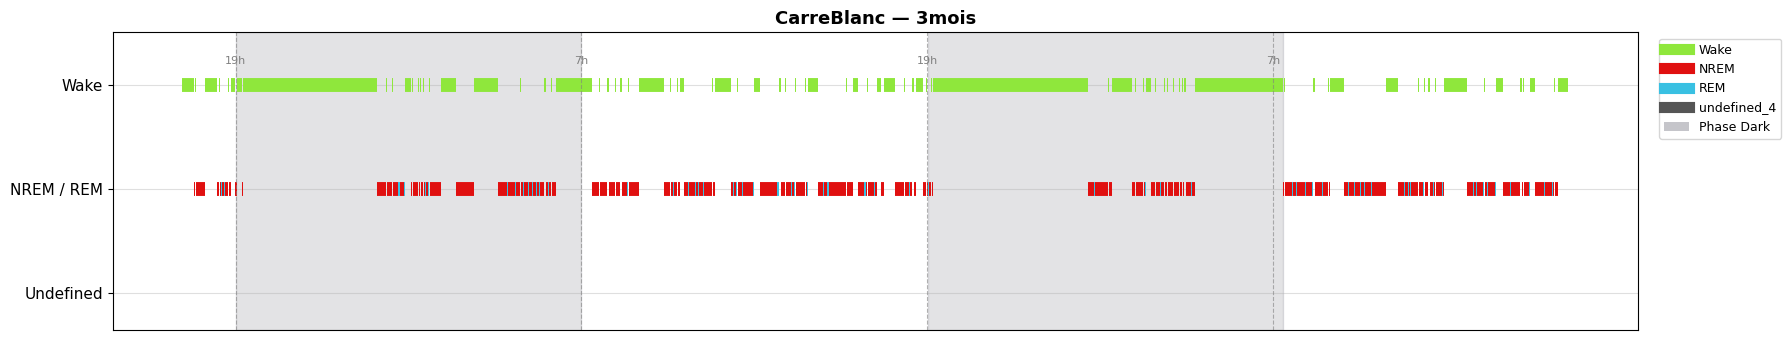

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreBlanc\3mois\Hypnogramme_CarreBlanc_3mois.png

  Souris : CarreBlanc  |  Age : 4mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   7178 epochs | duree totale : 48.28h
   Contenu recording_start.txt : [01/04/2026 16:09:54]
   Debut enregistrement : 2026-04-01 16:09:54  (format %d/%m/%Y %H:%M:%S)
   1201 episodes regroupe(s)


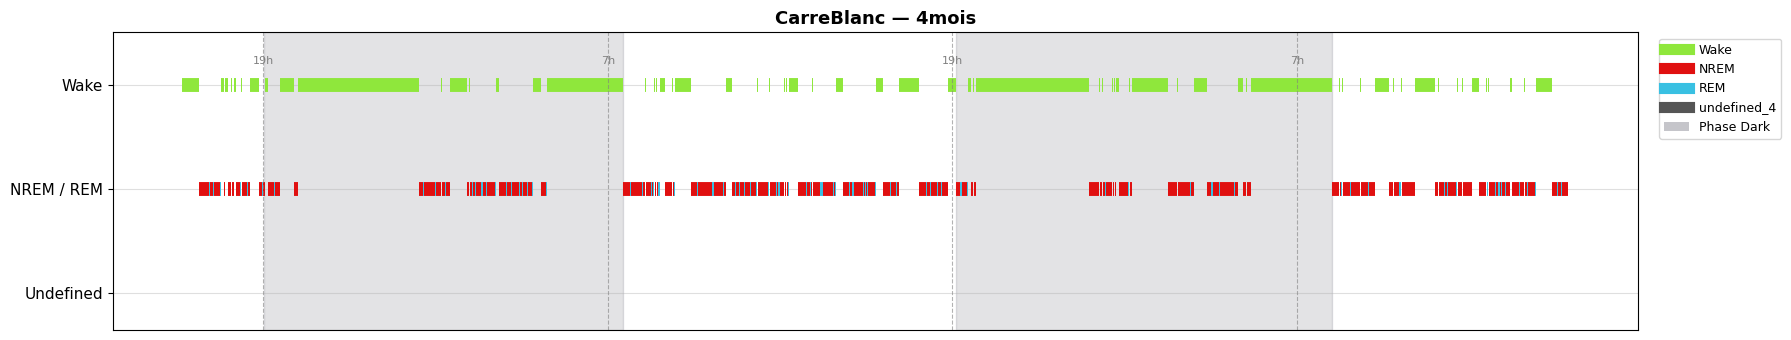

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreBlanc\4mois\Hypnogramme_CarreBlanc_4mois.png

  Souris : CarreBlanc  |  Age : 5mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   10820 epochs | duree totale : 48.07h
   Contenu recording_start.txt : [04/05/2026 16:12:56]
   Debut enregistrement : 2026-05-04 16:12:56  (format %d/%m/%Y %H:%M:%S)
   1889 episodes regroupe(s)


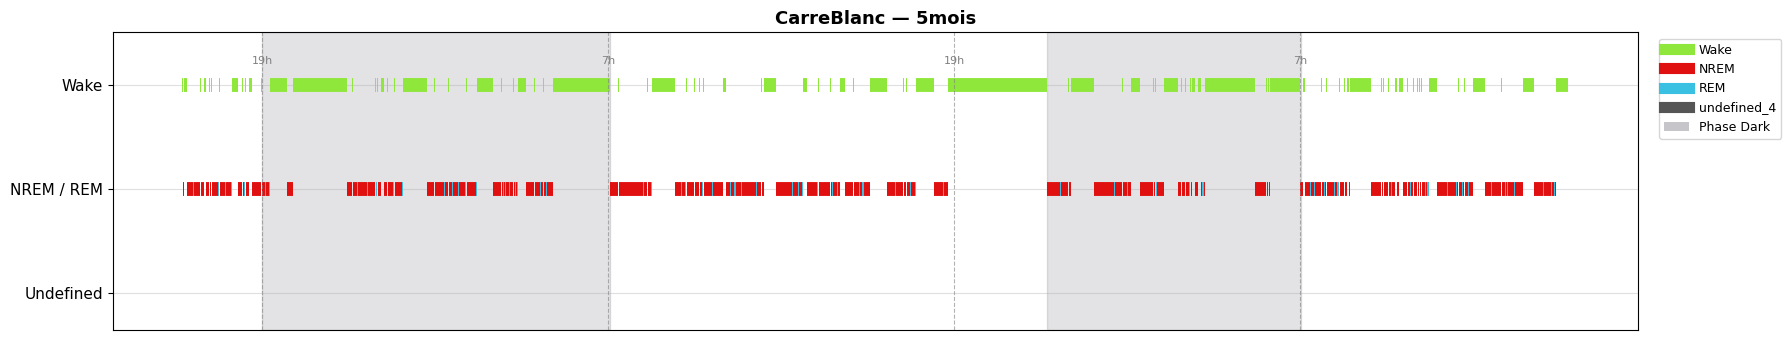

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreBlanc\5mois\Hypnogramme_CarreBlanc_5mois.png

  Souris : CarreBlanc  |  Age : 6mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   8674 epochs | duree totale : 44.47h
   Contenu recording_start.txt : [02/06/2026 16:31:11]
   Debut enregistrement : 2026-06-02 16:31:11  (format %d/%m/%Y %H:%M:%S)
   1365 episodes regroupe(s)


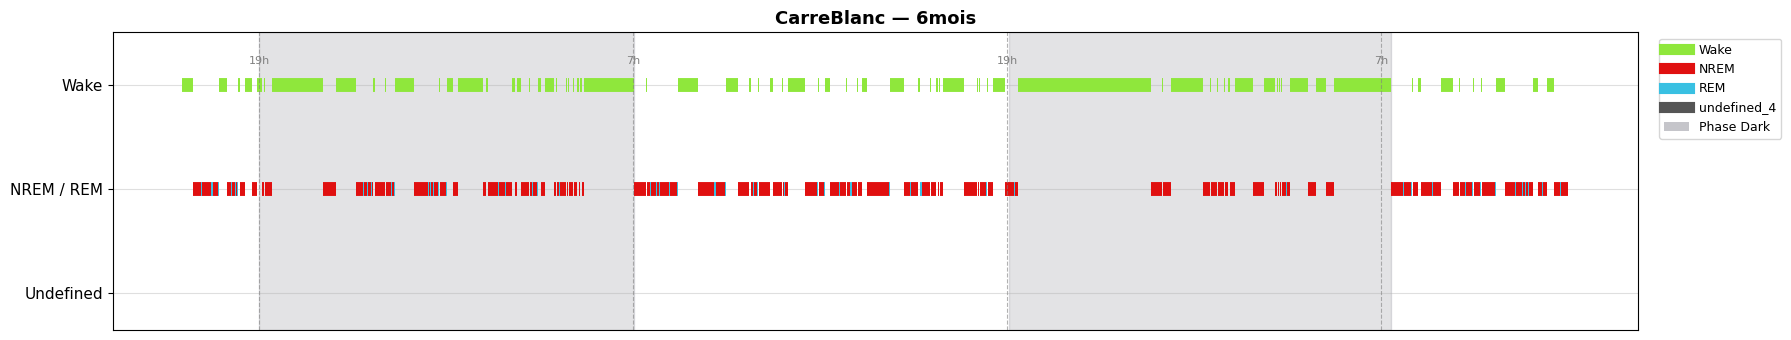

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreBlanc\6mois\Hypnogramme_CarreBlanc_6mois.png

  Souris : CarreJaune  |  Age : 3mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   34893 epochs | duree totale : 48.46h
   Contenu recording_start.txt : [09/03/2026 16:07:11]
   Debut enregistrement : 2026-03-09 16:07:11  (format %d/%m/%Y %H:%M:%S)
   4414 episodes regroupe(s)


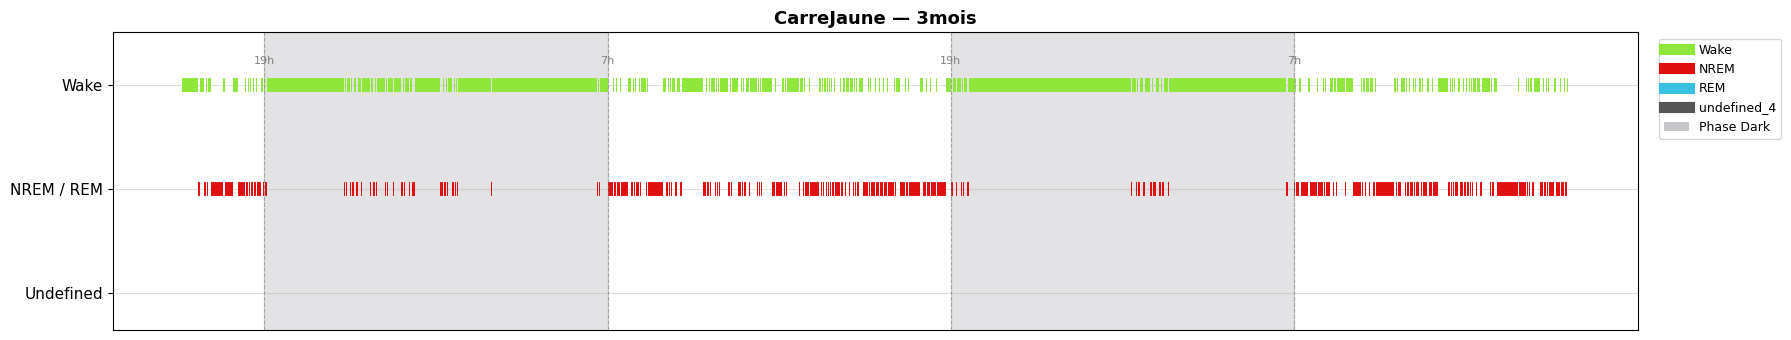

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreJaune\3mois\Hypnogramme_CarreJaune_3mois.png

  Souris : CarreJaune  |  Age : 4mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   8344 epochs | duree totale : 48.39h
   Contenu recording_start.txt : [14/04/2026 16:21:12]
   Debut enregistrement : 2026-04-14 16:21:12  (format %d/%m/%Y %H:%M:%S)
   1292 episodes regroupe(s)


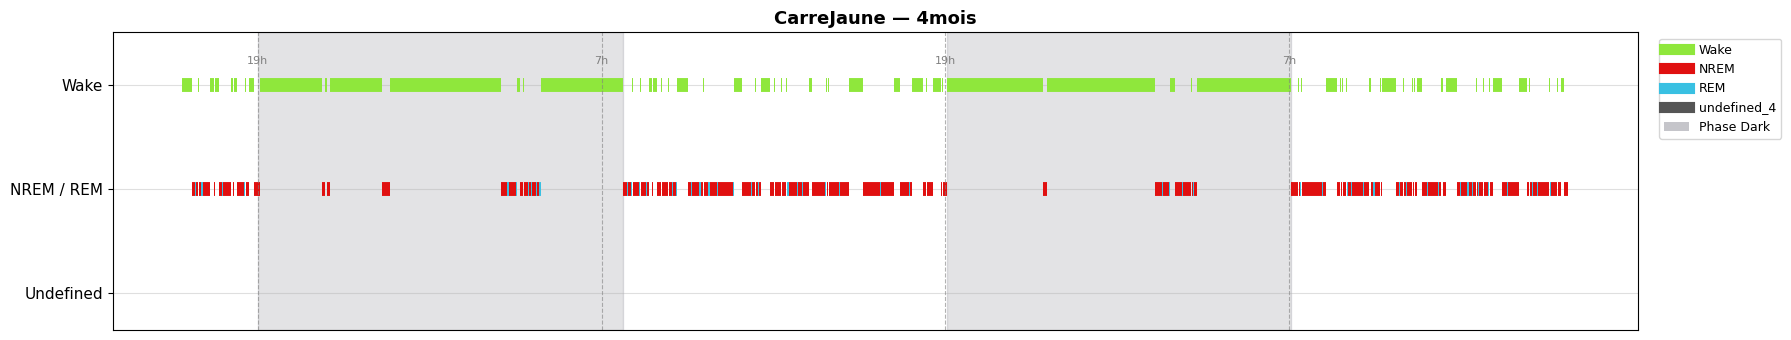

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreJaune\4mois\Hypnogramme_CarreJaune_4mois.png

  Souris : CarreJaune  |  Age : 5mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   5463 epochs | duree totale : 48.11h
   Contenu recording_start.txt : [11/05/2026 16:34:21]
   Debut enregistrement : 2026-05-11 16:34:21  (format %d/%m/%Y %H:%M:%S)
   953 episodes regroupe(s)


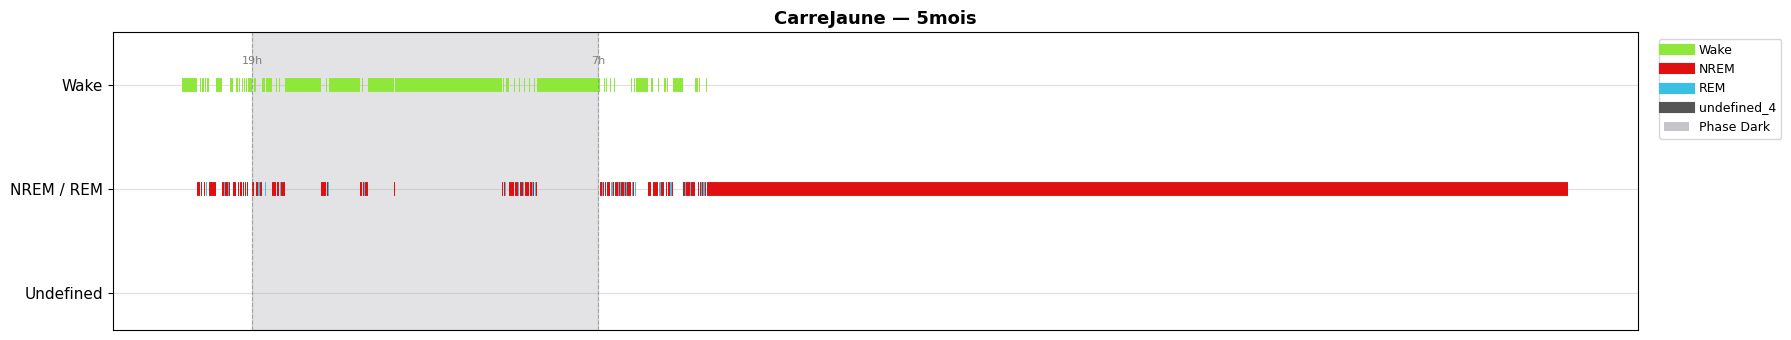

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreJaune\5mois\Hypnogramme_CarreJaune_5mois.png

  Souris : CarreJaune  |  Age : 6mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   14265 epochs | duree totale : 48.45h
   Contenu recording_start.txt : [08/06/2026 17:03:28]
   Debut enregistrement : 2026-06-08 17:03:28  (format %d/%m/%Y %H:%M:%S)
   2054 episodes regroupe(s)


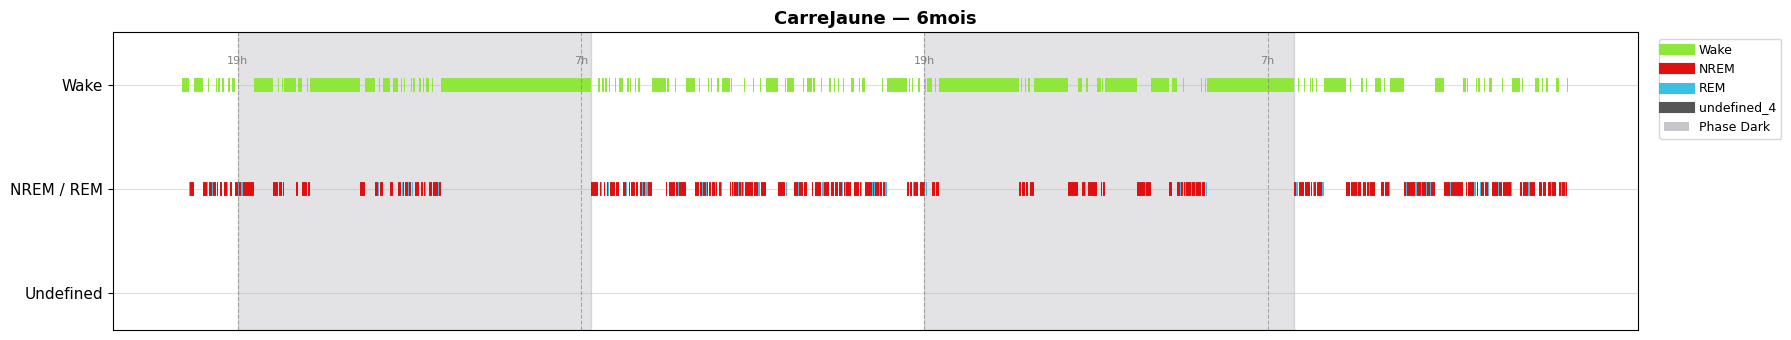

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreJaune\6mois\Hypnogramme_CarreJaune_6mois.png

  Souris : CarreMarron  |  Age : 3mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   14743 epochs | duree totale : 48.10h
   Contenu recording_start.txt : [23/02/2026 15:30:45]
   Debut enregistrement : 2026-02-23 15:30:45  (format %d/%m/%Y %H:%M:%S)
   979 episodes regroupe(s)


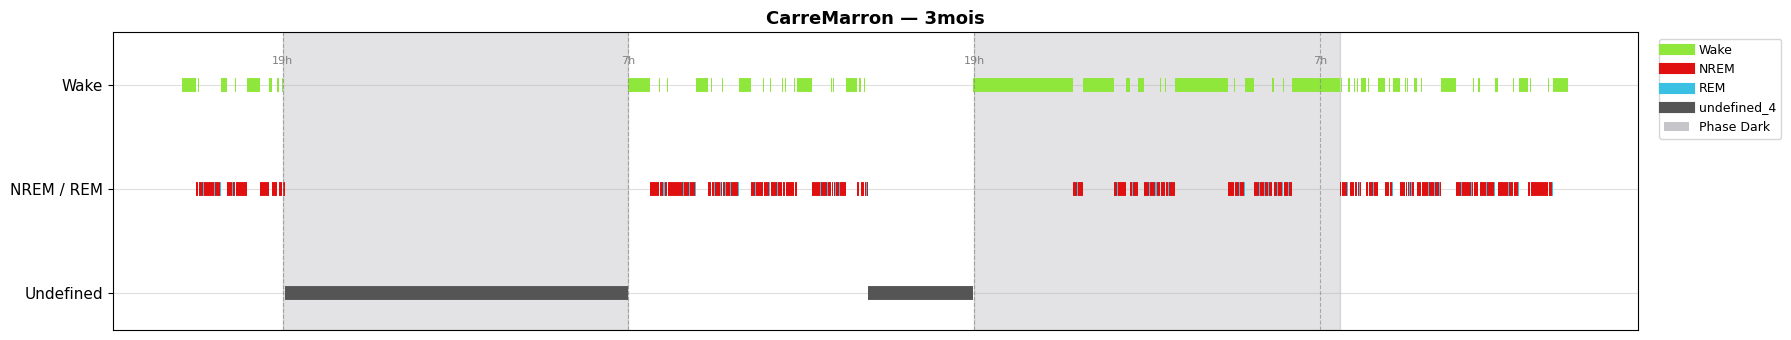

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreMarron\3mois\Hypnogramme_CarreMarron_3mois.png

  Souris : CarreMarron  |  Age : 4mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34995 epochs | duree totale : 48.60h
   Contenu recording_start.txt : [23/03/2026 15:33:38]
   Debut enregistrement : 2026-03-23 15:33:38  (format %d/%m/%Y %H:%M:%S)
   352 episodes regroupe(s)


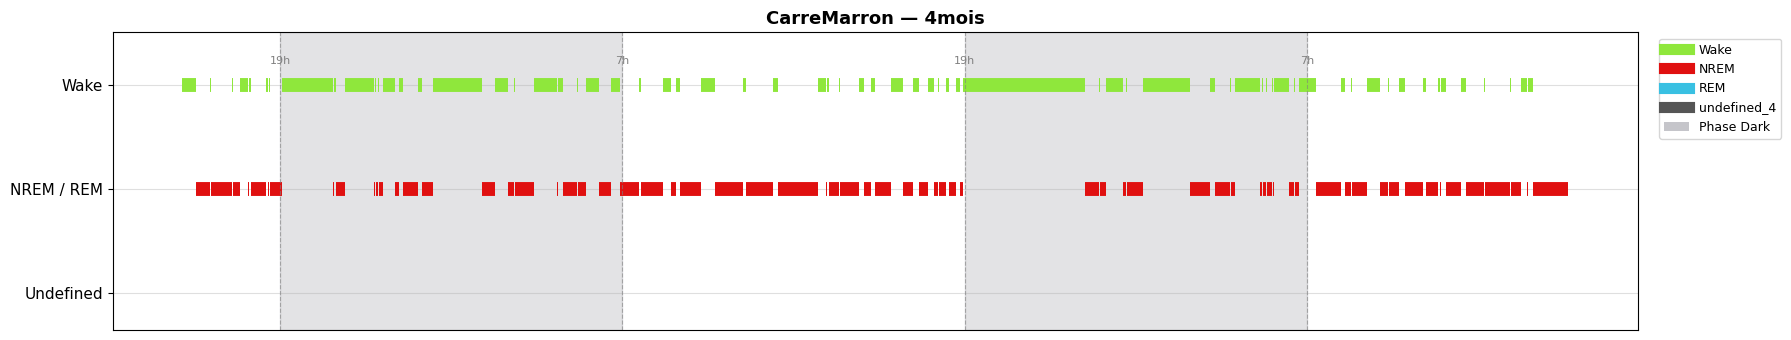

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreMarron\4mois\Hypnogramme_CarreMarron_4mois.png

  Souris : CarreMarron  |  Age : 5mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   7194 epochs | duree totale : 48.31h
   Contenu recording_start.txt : [20/04/2026 15:57:46]
   Debut enregistrement : 2026-04-20 15:57:46  (format %d/%m/%Y %H:%M:%S)
   1087 episodes regroupe(s)


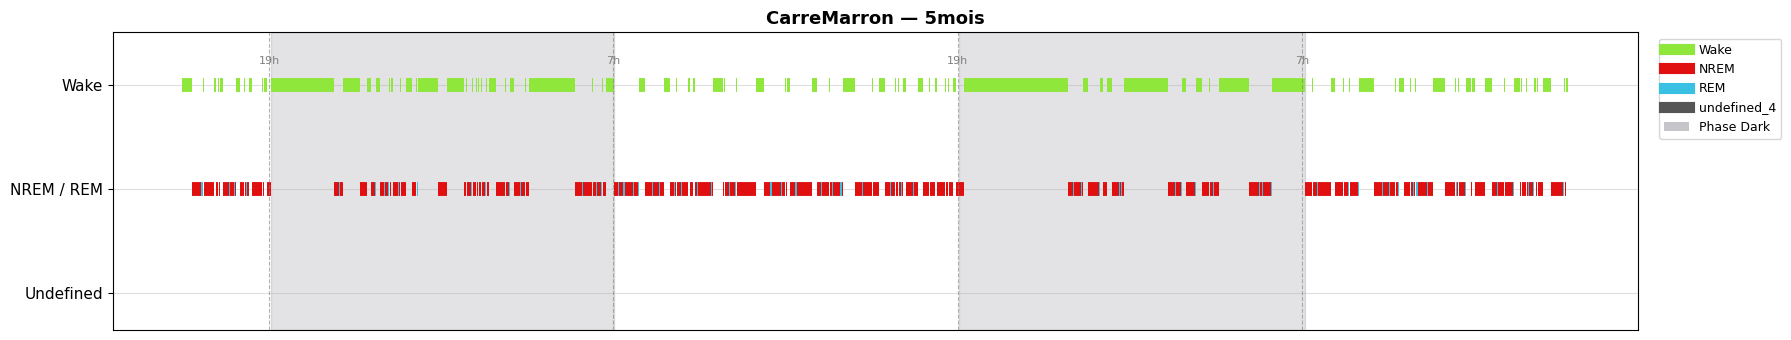

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreMarron\5mois\Hypnogramme_CarreMarron_5mois.png

  Souris : CarreMarron  |  Age : 6mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   8739 epochs | duree totale : 49.10h
   Contenu recording_start.txt : [26/05/2026 16:10:58]
   Debut enregistrement : 2026-05-26 16:10:58  (format %d/%m/%Y %H:%M:%S)
   1049 episodes regroupe(s)


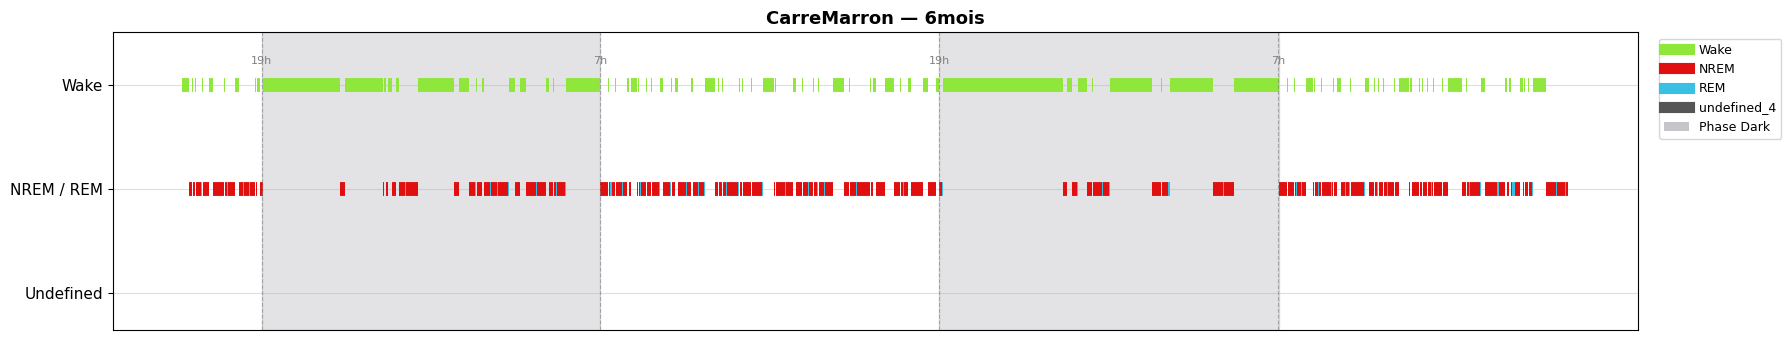

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreMarron\6mois\Hypnogramme_CarreMarron_6mois.png

  Souris : CarreMarron  |  Age : 7mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   7377 epochs | duree totale : 46.20h
   Contenu recording_start.txt : [22/06/2026 16:11:25]
   Debut enregistrement : 2026-06-22 16:11:25  (format %d/%m/%Y %H:%M:%S)
   776 episodes regroupe(s)


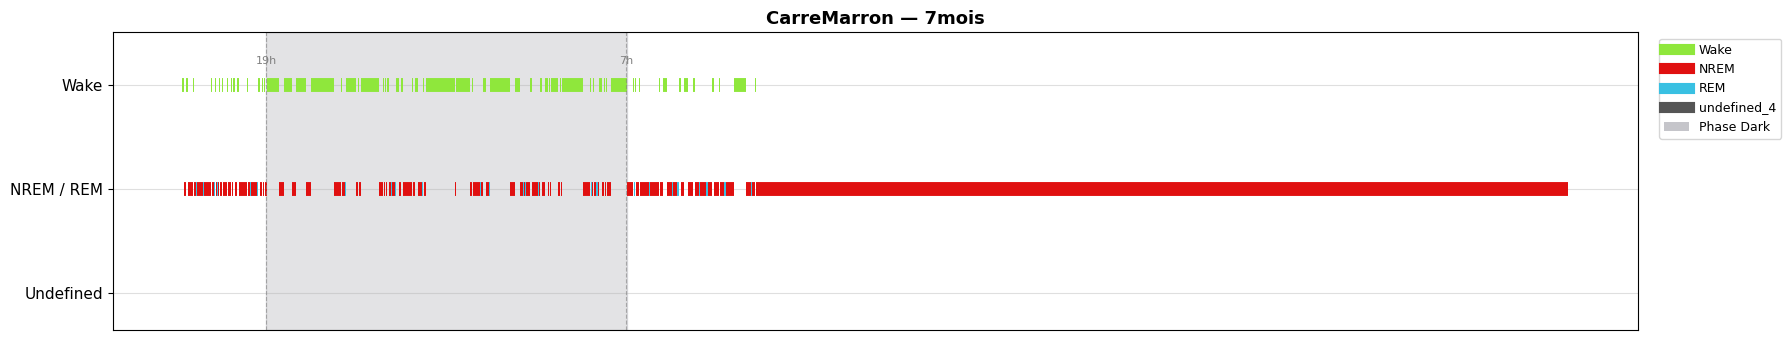

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreMarron\7mois\Hypnogramme_CarreMarron_7mois.png

  Souris : CarreNoir  |  Age : 3mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   10055 epochs | duree totale : 48.11h
   Contenu recording_start.txt : [04/03/2026 17:08:21]
   Debut enregistrement : 2026-03-04 17:08:21  (format %d/%m/%Y %H:%M:%S)
   1759 episodes regroupe(s)


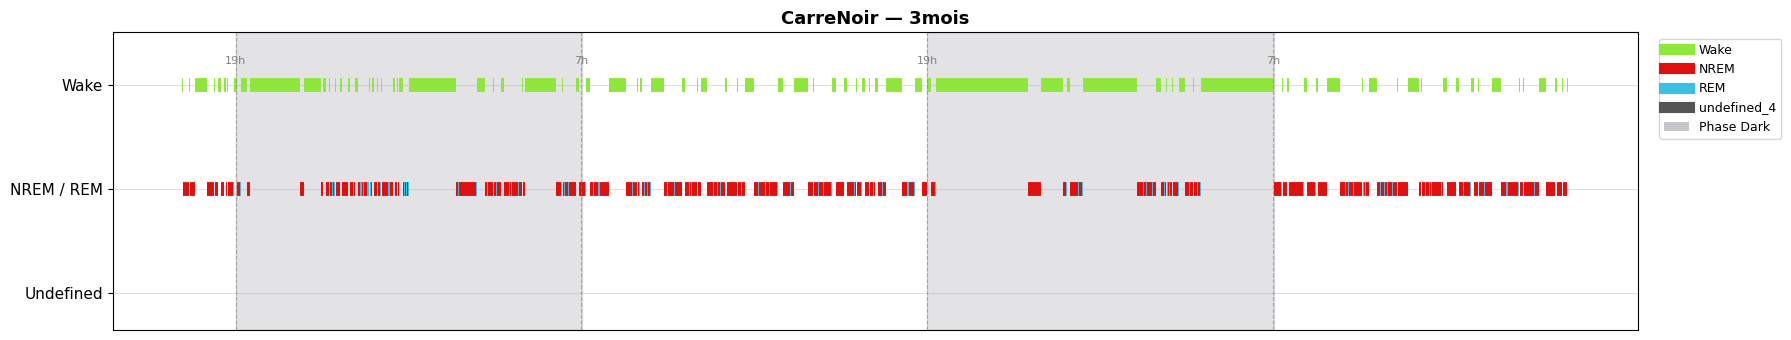

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreNoir\3mois\Hypnogramme_CarreNoir_3mois.png

  Souris : CarreNoir  |  Age : 4mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   9405 epochs | duree totale : 48.28h
   Contenu recording_start.txt : [01/04/2026 16:09:54]
   Debut enregistrement : 2026-04-01 16:09:54  (format %d/%m/%Y %H:%M:%S)
   1432 episodes regroupe(s)


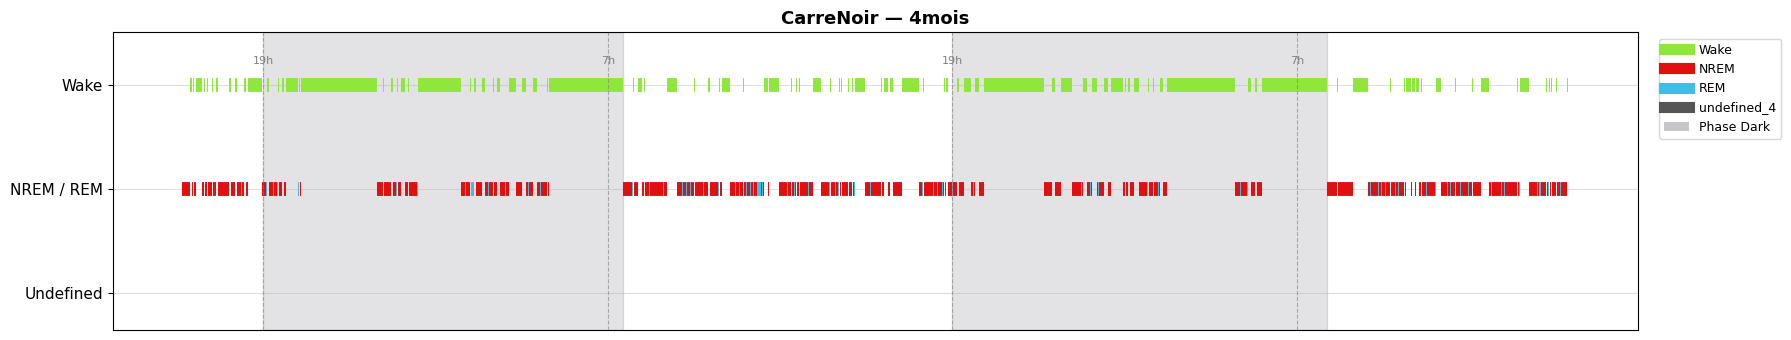

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreNoir\4mois\Hypnogramme_CarreNoir_4mois.png

  Souris : CarreNoir  |  Age : 5mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   10721 epochs | duree totale : 48.03h
   Contenu recording_start.txt : [04/05/2026 16:12:56]
   Debut enregistrement : 2026-05-04 16:12:56  (format %d/%m/%Y %H:%M:%S)
   2435 episodes regroupe(s)


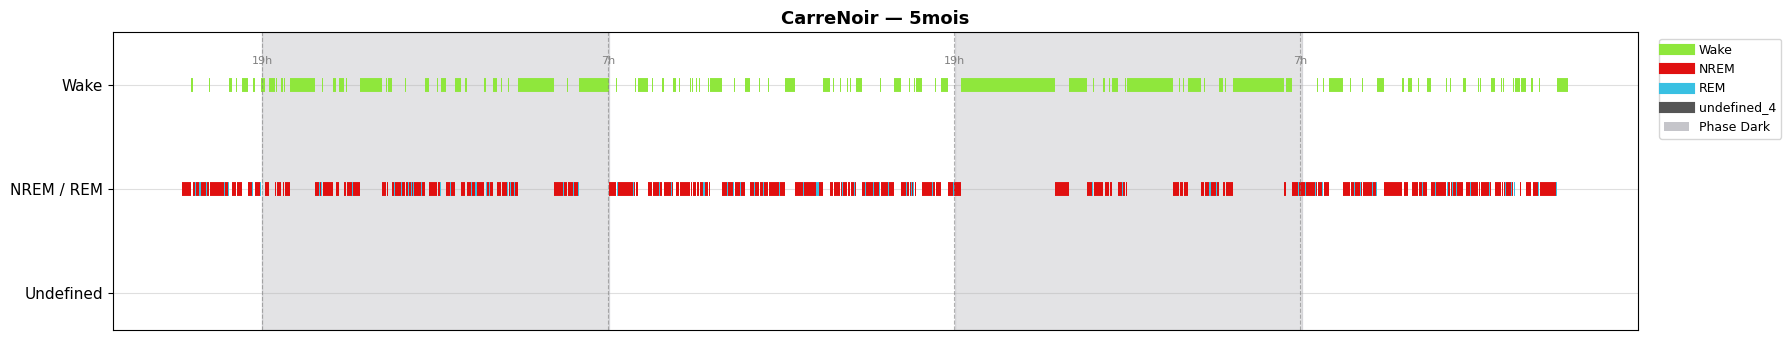

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreNoir\5mois\Hypnogramme_CarreNoir_5mois.png

  Souris : CarreNoir  |  Age : 6mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   10876 epochs | duree totale : 44.47h
   Contenu recording_start.txt : [02/06/2026 16:31:11]
   Debut enregistrement : 2026-06-02 16:31:11  (format %d/%m/%Y %H:%M:%S)
   1393 episodes regroupe(s)


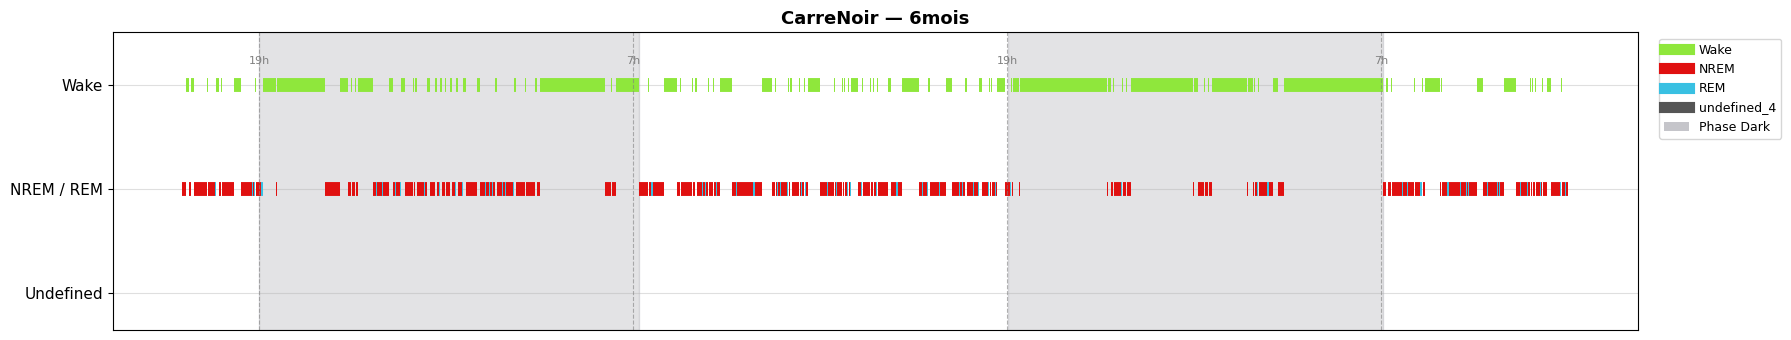

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreNoir\6mois\Hypnogramme_CarreNoir_6mois.png

  Souris : CarreOrange  |  Age : 3mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34636 epochs | duree totale : 48.11h
   Contenu recording_start.txt : [04/03/2026 17:08:21]
   Debut enregistrement : 2026-03-04 17:08:21  (format %d/%m/%Y %H:%M:%S)
   3345 episodes regroupe(s)


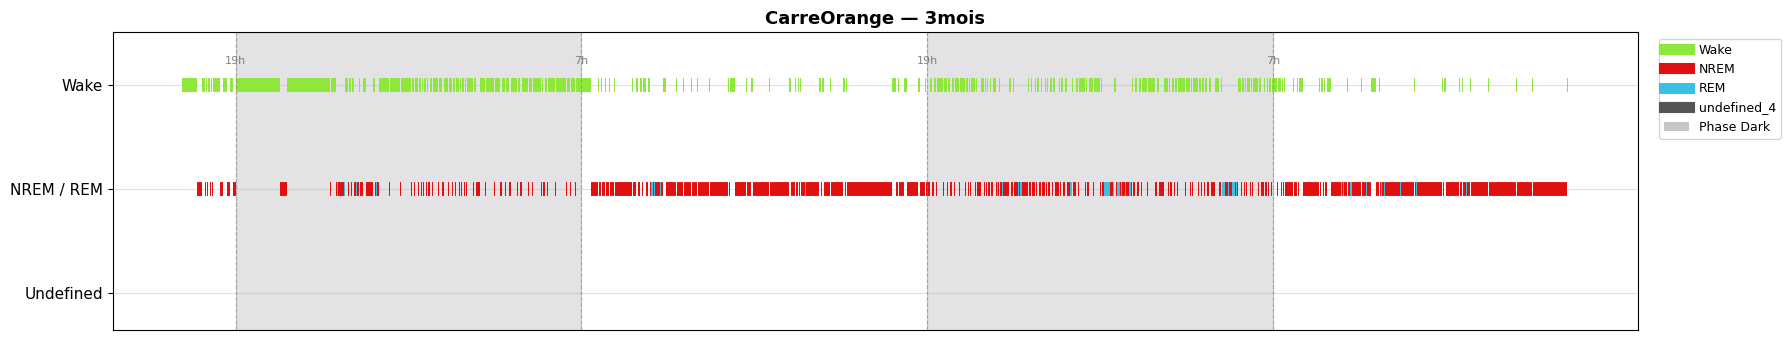

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreOrange\3mois\Hypnogramme_CarreOrange_3mois.png

  Souris : CarreOrange  |  Age : 4mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34764 epochs | duree totale : 48.28h
   Contenu recording_start.txt : [01/04/2026 19:09:54]
   Debut enregistrement : 2026-04-01 19:09:54  (format %d/%m/%Y %H:%M:%S)
   2409 episodes regroupe(s)


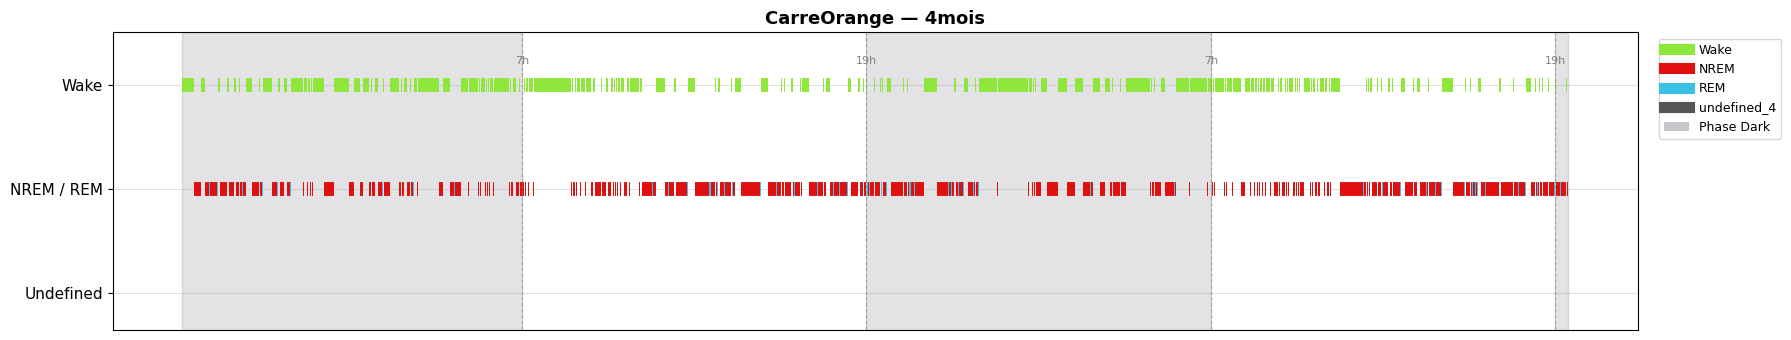

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreOrange\4mois\Hypnogramme_CarreOrange_4mois.png

  Souris : CarreOrange  |  Age : 5mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   10099 epochs | duree totale : 48.07h
   Contenu recording_start.txt : [04/05/2026 16:12:56]
   Debut enregistrement : 2026-05-04 16:12:56  (format %d/%m/%Y %H:%M:%S)
   1530 episodes regroupe(s)


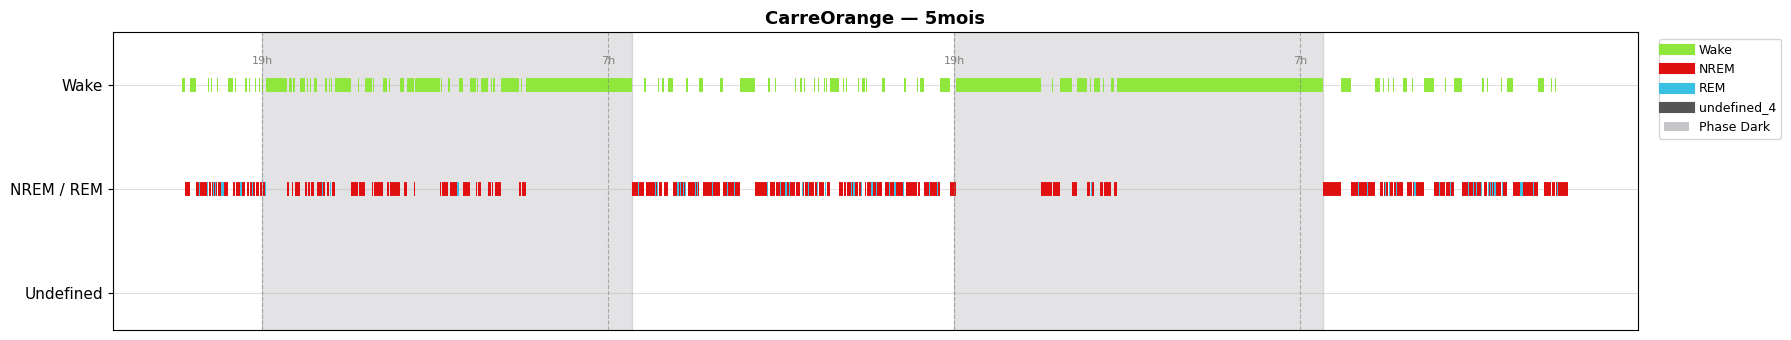

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreOrange\5mois\Hypnogramme_CarreOrange_5mois.png

  Souris : CarreOrange  |  Age : 6mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   10085 epochs | duree totale : 44.47h
   Contenu recording_start.txt : [02/06/2026 16:31:11]
   Debut enregistrement : 2026-06-02 16:31:11  (format %d/%m/%Y %H:%M:%S)
   1381 episodes regroupe(s)


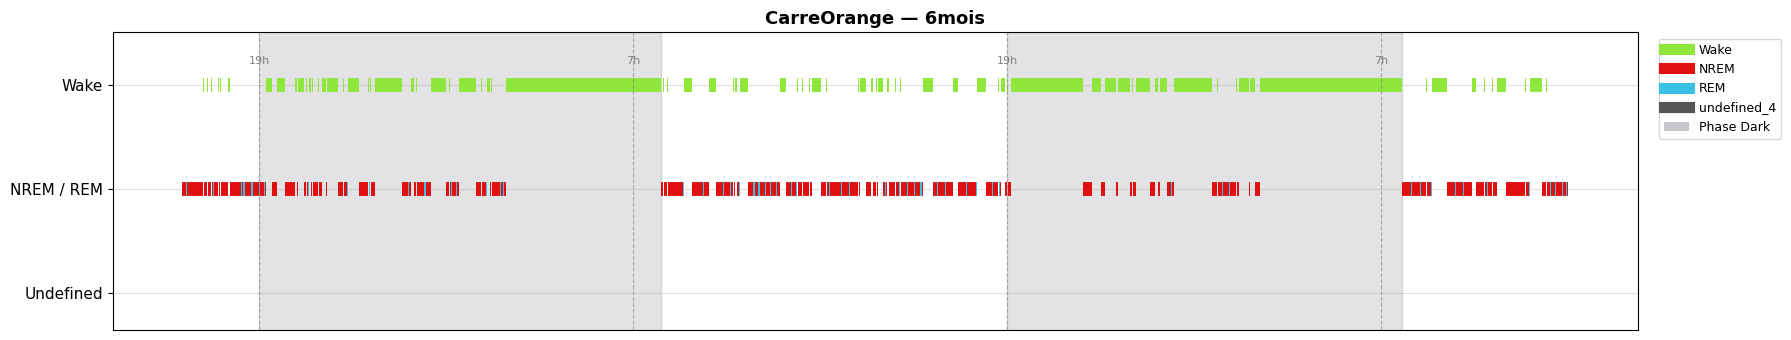

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreOrange\6mois\Hypnogramme_CarreOrange_6mois.png

  Souris : CarreRouge  |  Age : 3mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34633 epochs | duree totale : 48.10h
   Contenu recording_start.txt : [23/02/2026 15:30:45]
   Debut enregistrement : 2026-02-23 15:30:45  (format %d/%m/%Y %H:%M:%S)
   1765 episodes regroupe(s)


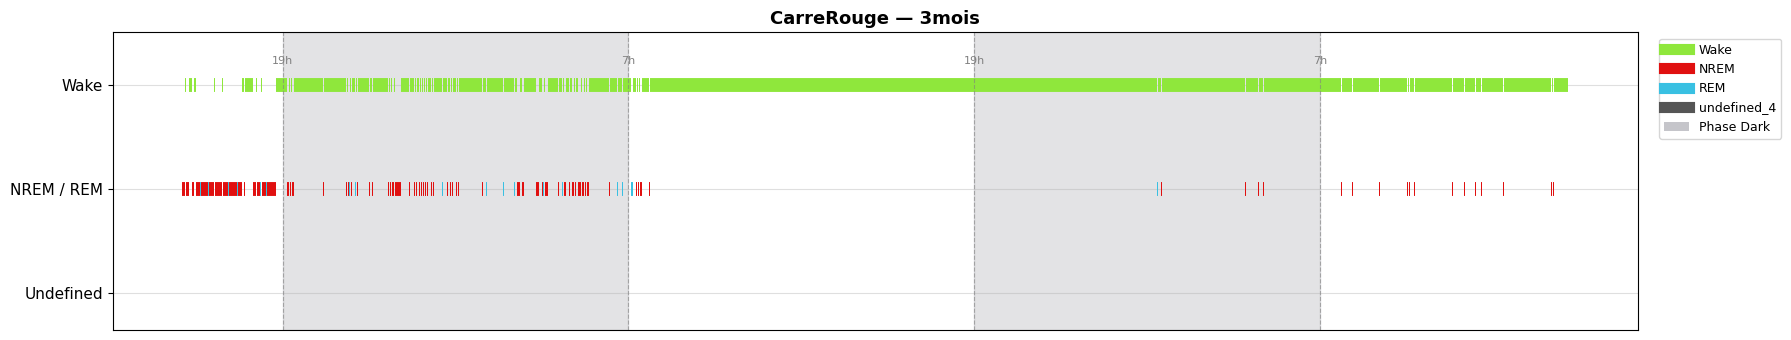

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreRouge\3mois\Hypnogramme_CarreRouge_3mois.png

  Souris : CarreRouge  |  Age : 4mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34995 epochs | duree totale : 48.60h
   Contenu recording_start.txt : [23/03/2026 15:33:38]
   Debut enregistrement : 2026-03-23 15:33:38  (format %d/%m/%Y %H:%M:%S)
   1292 episodes regroupe(s)


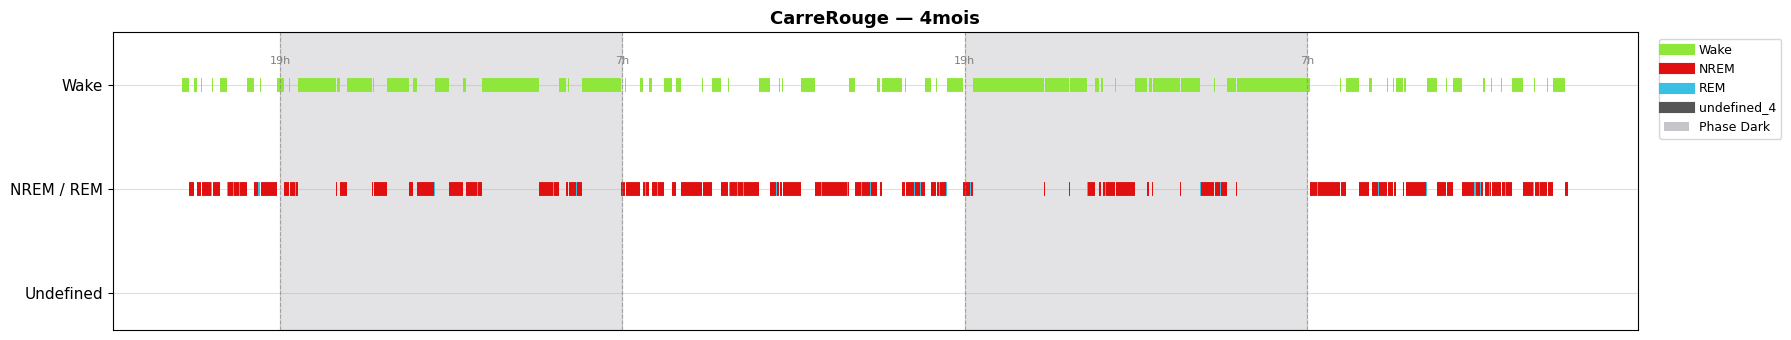

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreRouge\4mois\Hypnogramme_CarreRouge_4mois.png

  Souris : CarreRouge  |  Age : 5mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   9587 epochs | duree totale : 48.31h
   Contenu recording_start.txt : [20/04/2026 15:57:46]
   Debut enregistrement : 2026-04-20 15:57:46  (format %d/%m/%Y %H:%M:%S)
   1528 episodes regroupe(s)


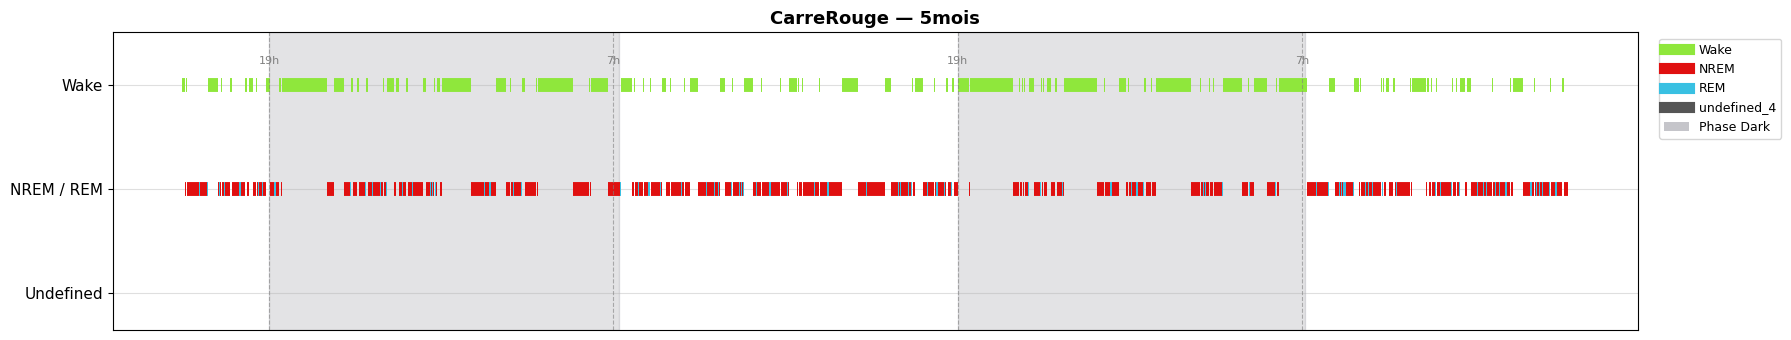

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreRouge\5mois\Hypnogramme_CarreRouge_5mois.png

  Souris : CarreRouge  |  Age : 6mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   10513 epochs | duree totale : 49.10h
   Contenu recording_start.txt : [26/05/2026 16:10:58]
   Debut enregistrement : 2026-05-26 16:10:58  (format %d/%m/%Y %H:%M:%S)
   1438 episodes regroupe(s)


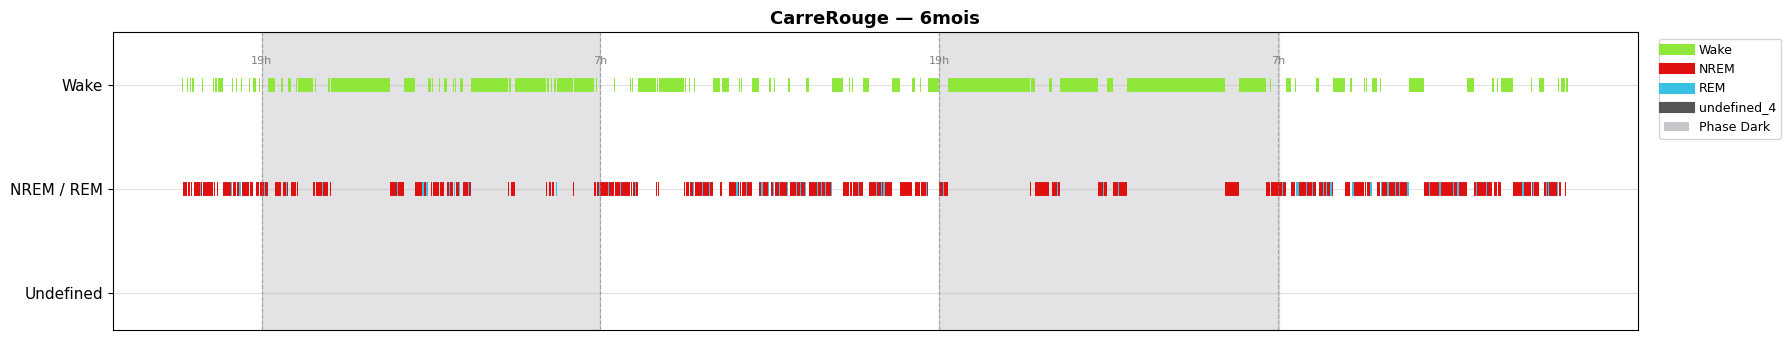

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreRouge\6mois\Hypnogramme_CarreRouge_6mois.png

  Souris : CarreRouge  |  Age : 7mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   12573 epochs | duree totale : 46.20h
   Contenu recording_start.txt : [22/06/2026 16:11:25]
   Debut enregistrement : 2026-06-22 16:11:25  (format %d/%m/%Y %H:%M:%S)
   1823 episodes regroupe(s)


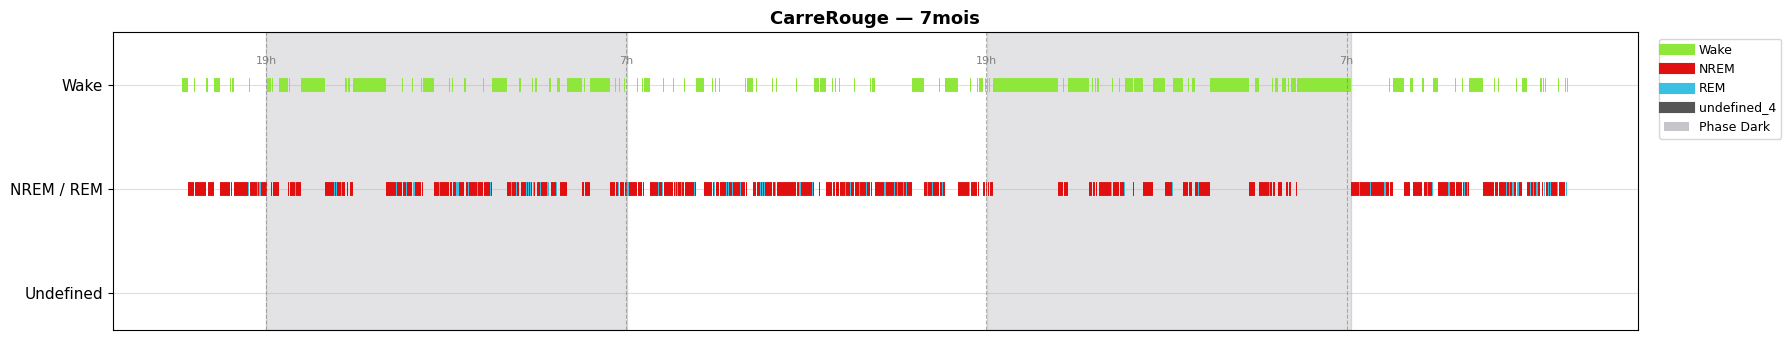

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreRouge\7mois\Hypnogramme_CarreRouge_7mois.png

  Souris : CarreVert  |  Age : 3mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   5824 epochs | duree totale : 8.01h
   Contenu recording_start.txt : [09/03/2026 16:07:11]
   Debut enregistrement : 2026-03-09 16:07:11  (format %d/%m/%Y %H:%M:%S)
   191 episodes regroupe(s)


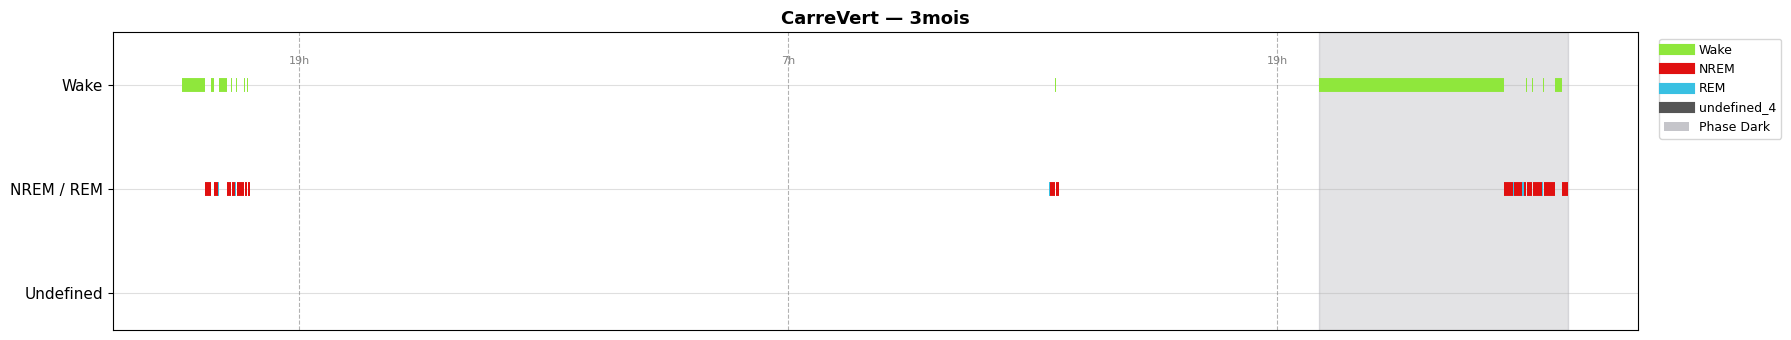

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreVert\3mois\Hypnogramme_CarreVert_3mois.png

  Souris : CarreVert  |  Age : 4mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   9216 epochs | duree totale : 48.39h
   Contenu recording_start.txt : [14/04/2026 16:21:12]
   Debut enregistrement : 2026-04-14 16:21:12  (format %d/%m/%Y %H:%M:%S)
   1391 episodes regroupe(s)


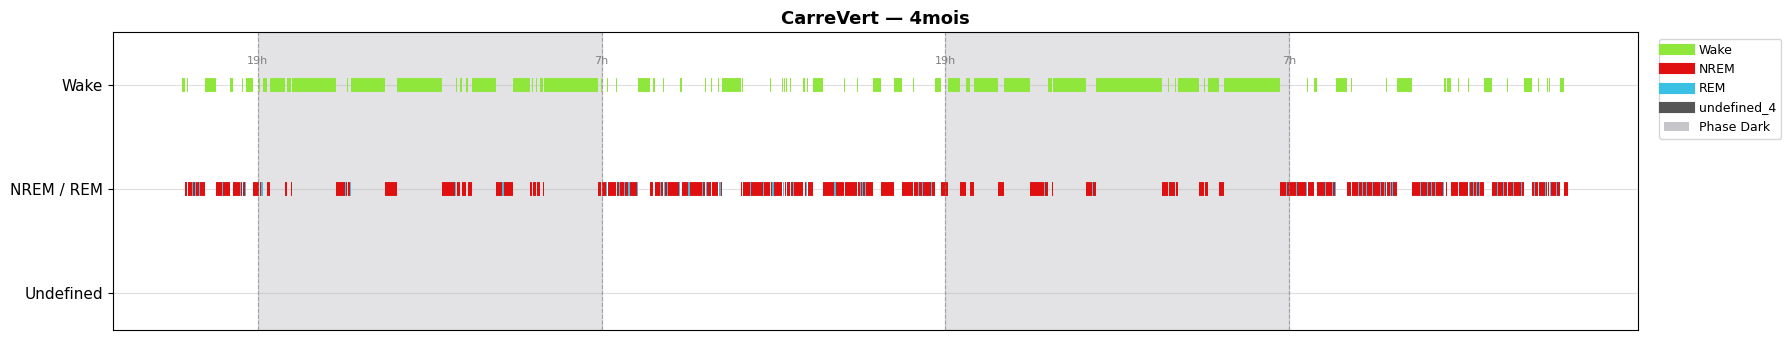

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreVert\4mois\Hypnogramme_CarreVert_4mois.png

  Souris : CarreVert  |  Age : 5mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   9648 epochs | duree totale : 48.11h
   Contenu recording_start.txt : [11/05/2026 16:34:21]
   Debut enregistrement : 2026-05-11 16:34:21  (format %d/%m/%Y %H:%M:%S)
   1386 episodes regroupe(s)


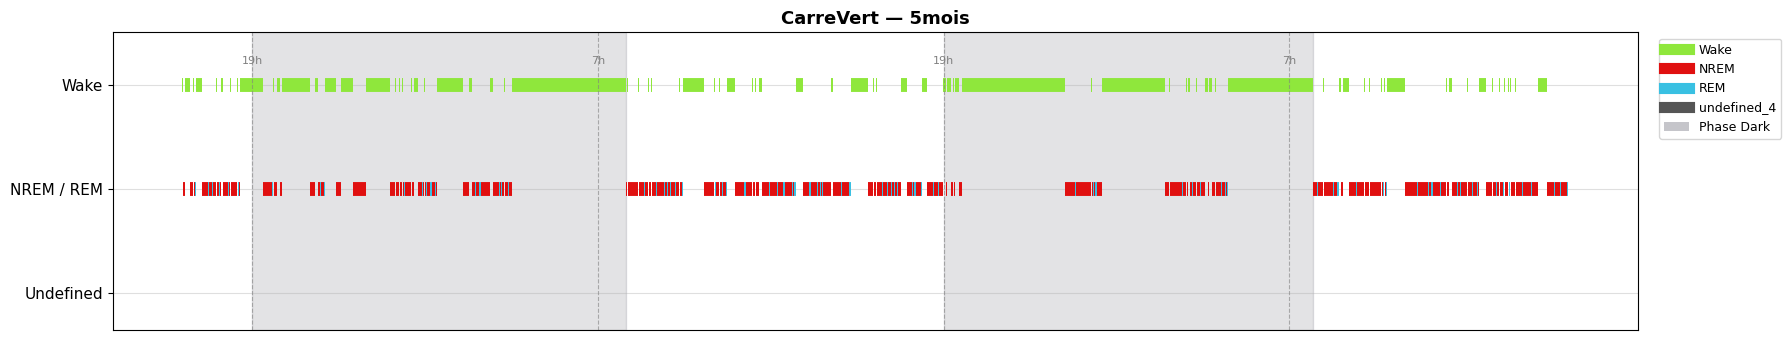

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreVert\5mois\Hypnogramme_CarreVert_5mois.png

  Souris : CarreVert  |  Age : 6mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   12575 epochs | duree totale : 48.45h
   Contenu recording_start.txt : [08/06/2026 17:03:28]
   Debut enregistrement : 2026-06-08 17:03:28  (format %d/%m/%Y %H:%M:%S)
   1659 episodes regroupe(s)


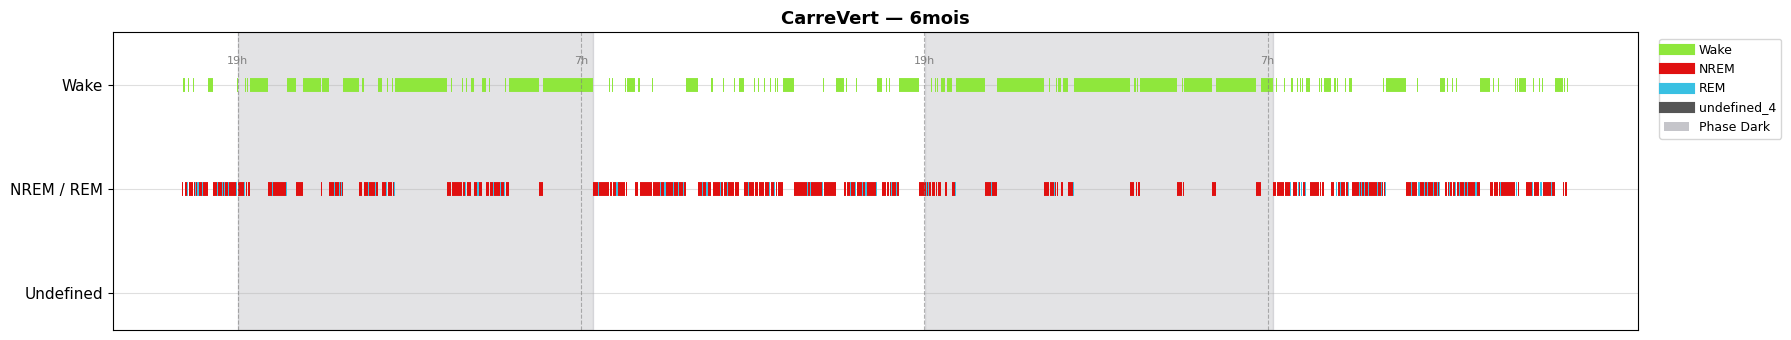

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreVert\6mois\Hypnogramme_CarreVert_6mois.png

  Souris : CarreViolet  |  Age : 3mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   2741 epochs | duree totale : 3.78h
   Contenu recording_start.txt : [09/03/2026 16:07:11]
   Debut enregistrement : 2026-03-09 16:07:11  (format %d/%m/%Y %H:%M:%S)
   75 episodes regroupe(s)


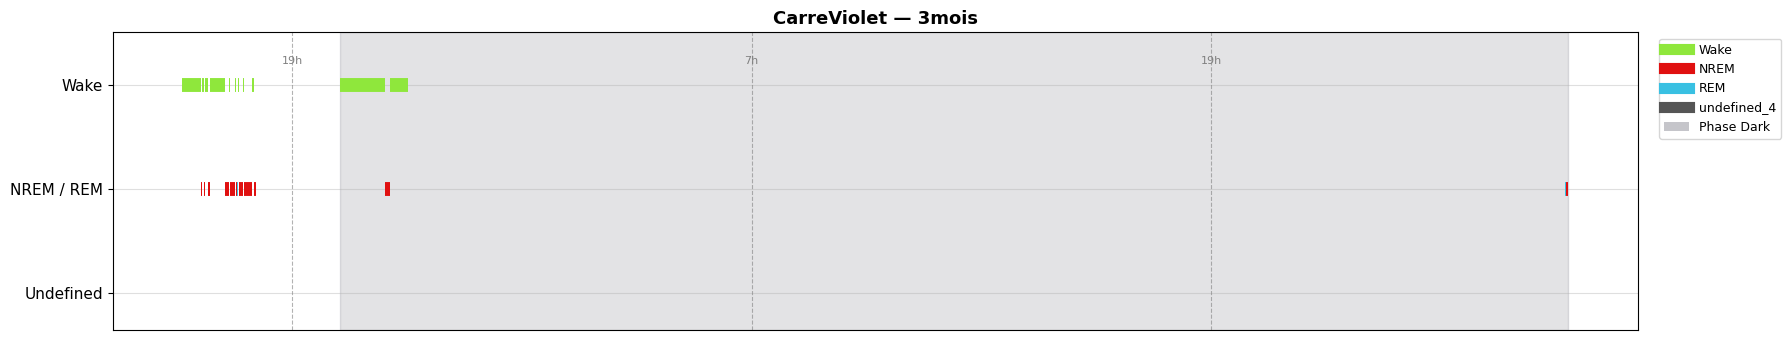

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreViolet\3mois\Hypnogramme_CarreViolet_3mois.png

  Souris : CarreViolet  |  Age : 4mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   11560 epochs | duree totale : 48.39h
   Contenu recording_start.txt : [14/04/2026 16:21:12]
   Debut enregistrement : 2026-04-14 16:21:12  (format %d/%m/%Y %H:%M:%S)
   1610 episodes regroupe(s)


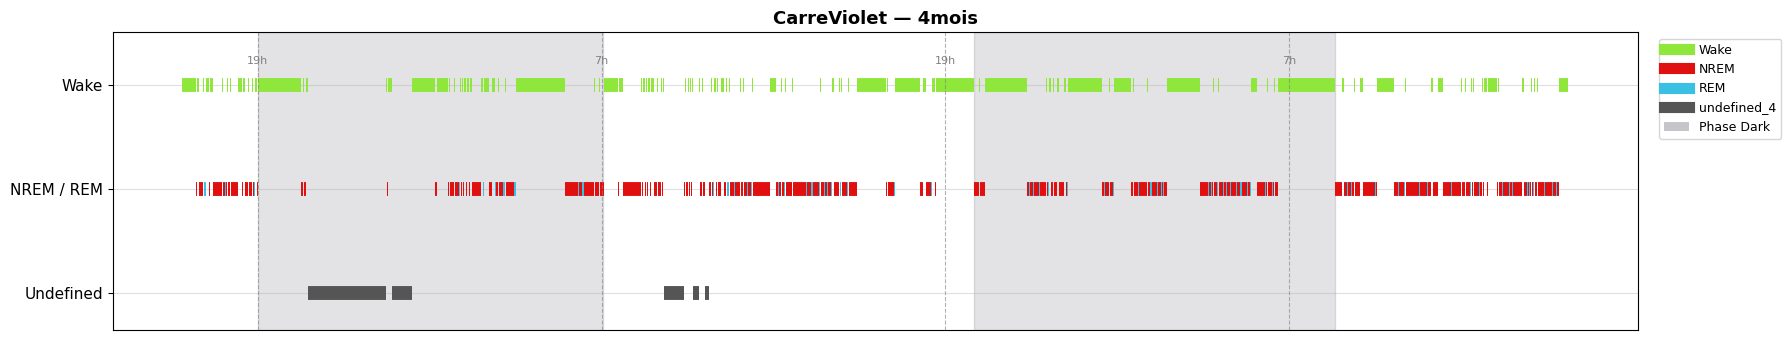

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreViolet\4mois\Hypnogramme_CarreViolet_4mois.png

  Souris : CarreViolet  |  Age : 5mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   7988 epochs | duree totale : 48.11h
   Contenu recording_start.txt : [11/05/2026 16:34:21]
   Debut enregistrement : 2026-05-11 16:34:21  (format %d/%m/%Y %H:%M:%S)
   1391 episodes regroupe(s)


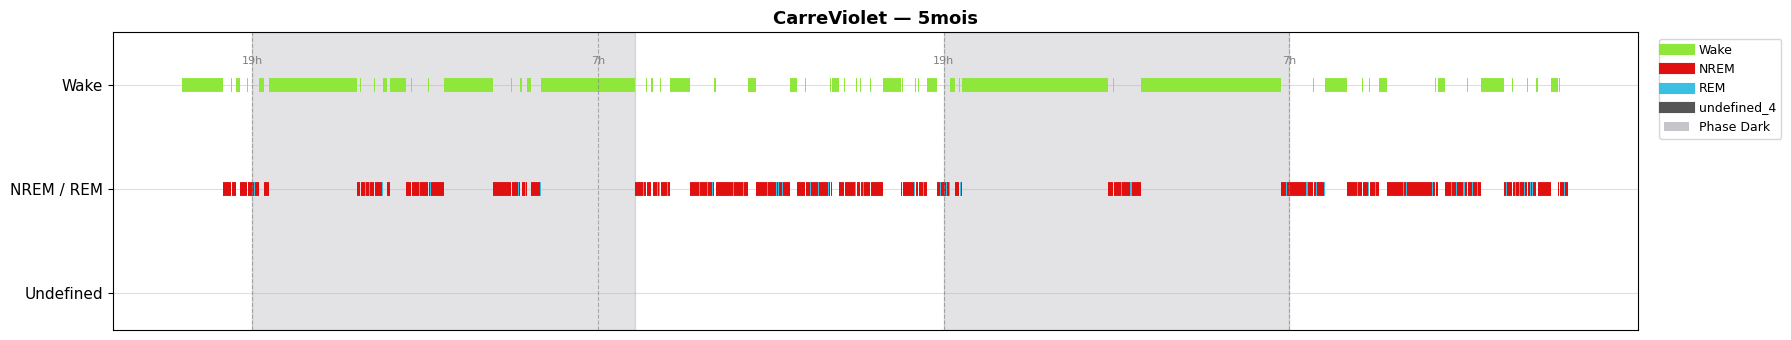

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreViolet\5mois\Hypnogramme_CarreViolet_5mois.png

  Souris : CarreViolet  |  Age : 6mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   10761 epochs | duree totale : 48.45h
   Contenu recording_start.txt : [08/06/2026 17:03:28]
   Debut enregistrement : 2026-06-08 17:03:28  (format %d/%m/%Y %H:%M:%S)
   1427 episodes regroupe(s)


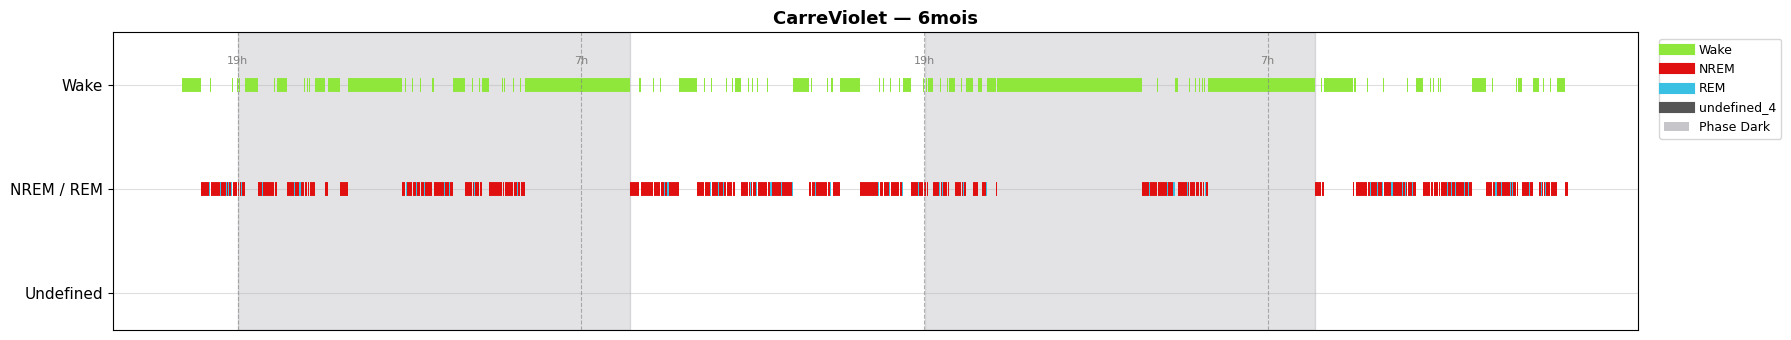

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\CarreViolet\6mois\Hypnogramme_CarreViolet_6mois.png

  Souris : RondBleu  |  Age : 3mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   12861 epochs | duree totale : 17.86h
   Contenu recording_start.txt : [01/04/2025 16:52:14]
   Debut enregistrement : 2025-04-01 16:52:14  (format %d/%m/%Y %H:%M:%S)
   77 episodes regroupe(s)


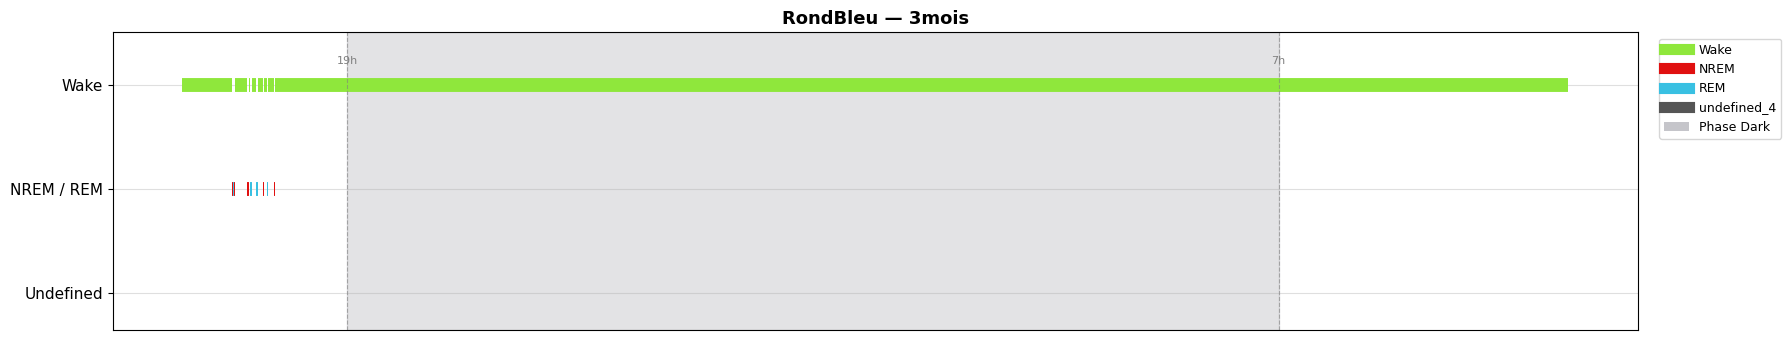

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondBleu\3mois\Hypnogramme_RondBleu_3mois.png

  Souris : RondJaune  |  Age : 3mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   3376 epochs | duree totale : 4.62h
   Contenu recording_start.txt : [01/04/2025 16:52:14]
   Debut enregistrement : 2025-04-01 16:52:14  (format %d/%m/%Y %H:%M:%S)
   164 episodes regroupe(s)


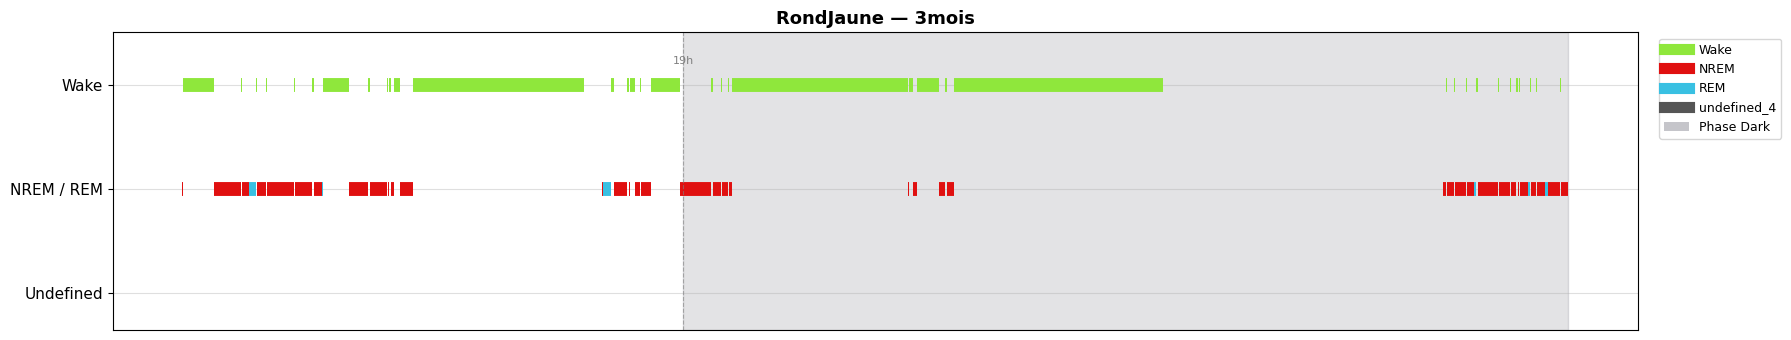

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondJaune\3mois\Hypnogramme_RondJaune_3mois.png

  Souris : RondJaune  |  Age : 4mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   3005 epochs | duree totale : 4.14h
   Contenu recording_start.txt : [30/04/2025 09:53:23]
   Debut enregistrement : 2025-04-30 09:53:23  (format %d/%m/%Y %H:%M:%S)
   125 episodes regroupe(s)


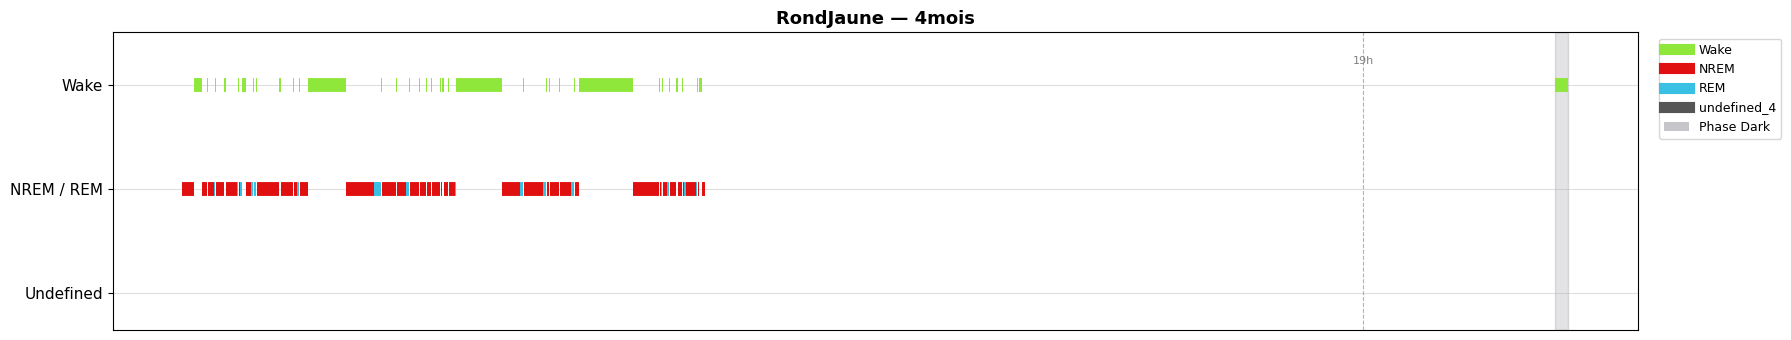

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondJaune\4mois\Hypnogramme_RondJaune_4mois.png

  Souris : RondJaune  |  Age : 5mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   3222 epochs | duree totale : 4.45h
   Contenu recording_start.txt : [10/06/2025 16:14:53]
   Debut enregistrement : 2025-06-10 16:14:53  (format %d/%m/%Y %H:%M:%S)
   94 episodes regroupe(s)


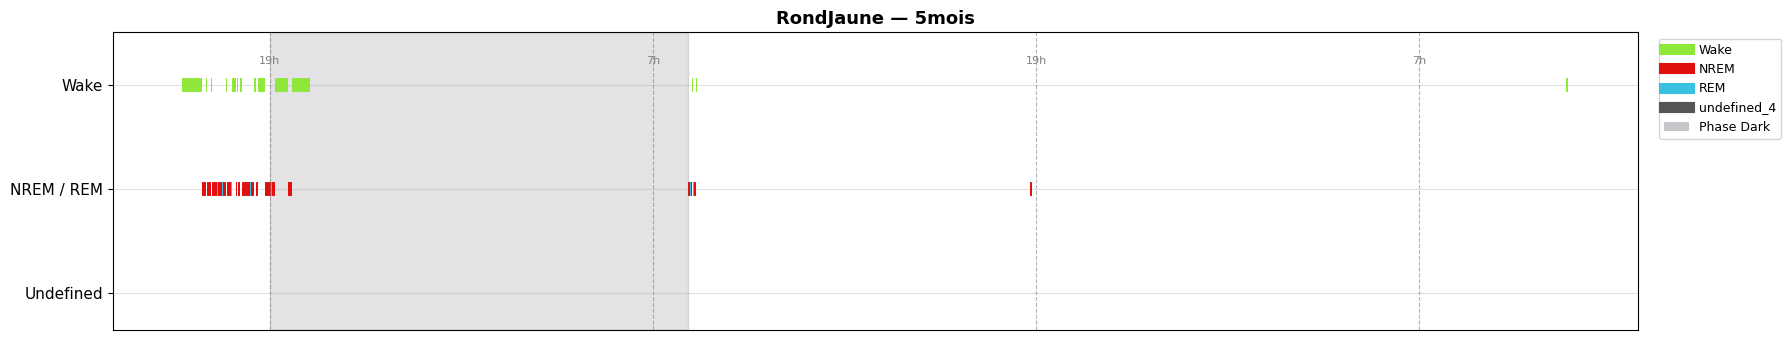

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondJaune\5mois\Hypnogramme_RondJaune_5mois.png

  Souris : RondJaune  |  Age : 6mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   8984 epochs | duree totale : 48.90h
   Contenu recording_start.txt : [07/07/2025 16:34:52]
   Debut enregistrement : 2025-07-07 16:34:52  (format %d/%m/%Y %H:%M:%S)
   954 episodes regroupe(s)


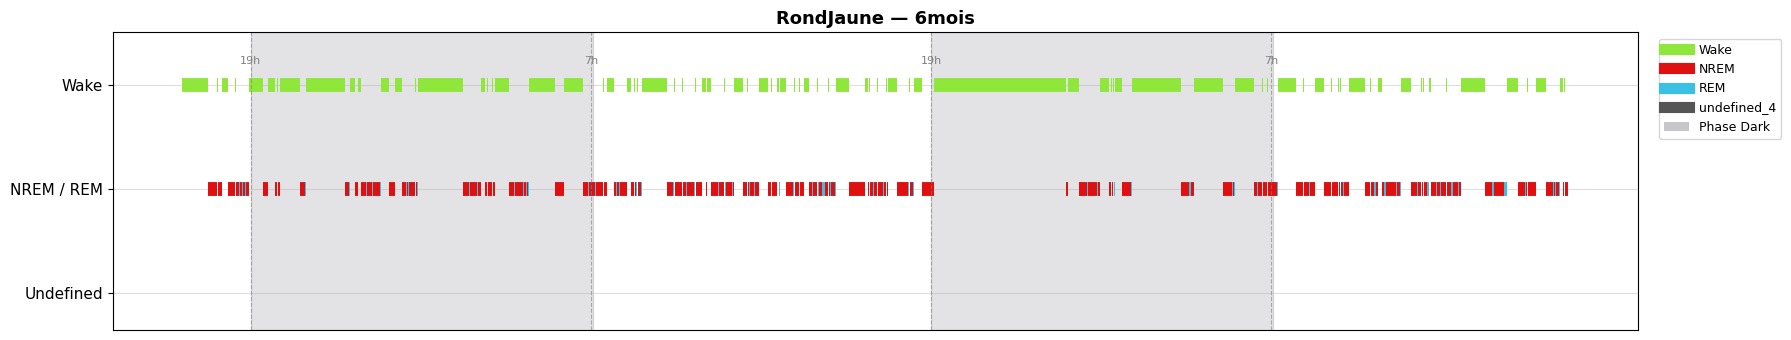

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondJaune\6mois\Hypnogramme_RondJaune_6mois.png

  Souris : RondJaune  |  Age : 7mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   7439 epochs | duree totale : 48.21h
   Contenu recording_start.txt : [04/08/2025 17:55:41]
   Debut enregistrement : 2025-08-04 17:55:41  (format %d/%m/%Y %H:%M:%S)
   1099 episodes regroupe(s)


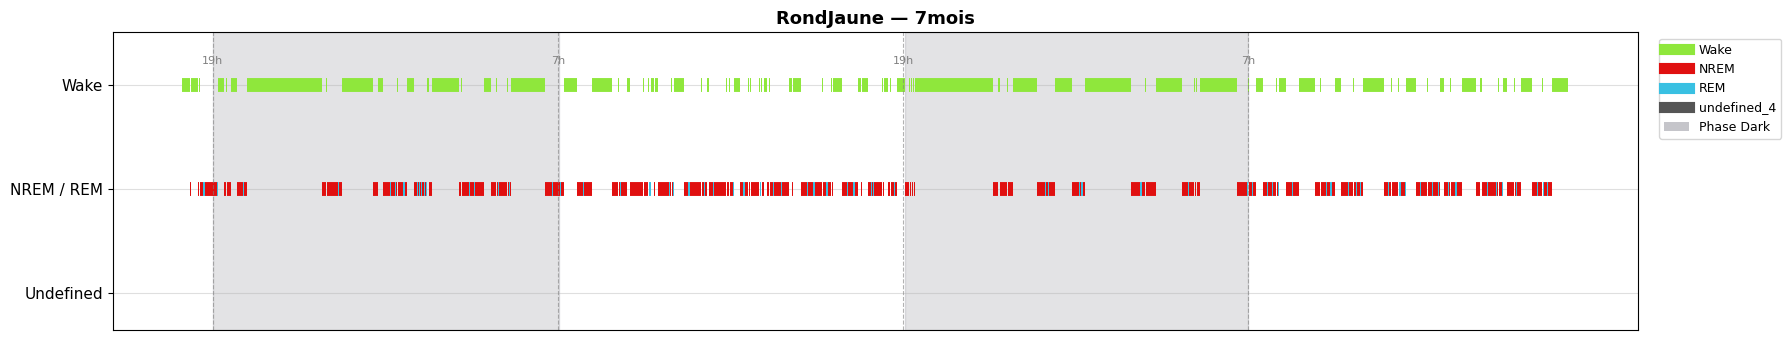

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondJaune\7mois\Hypnogramme_RondJaune_7mois.png

  Souris : RondMarron  |  Age : 3mois  |  Scoring : ManualScor5
   Separateur detecte : [;]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   35138 epochs | duree totale : 48.19h
   Contenu recording_start.txt : [07/04/2025 15:56:32]
   Debut enregistrement : 2025-04-07 15:56:32  (format %d/%m/%Y %H:%M:%S)
   1336 episodes regroupe(s)


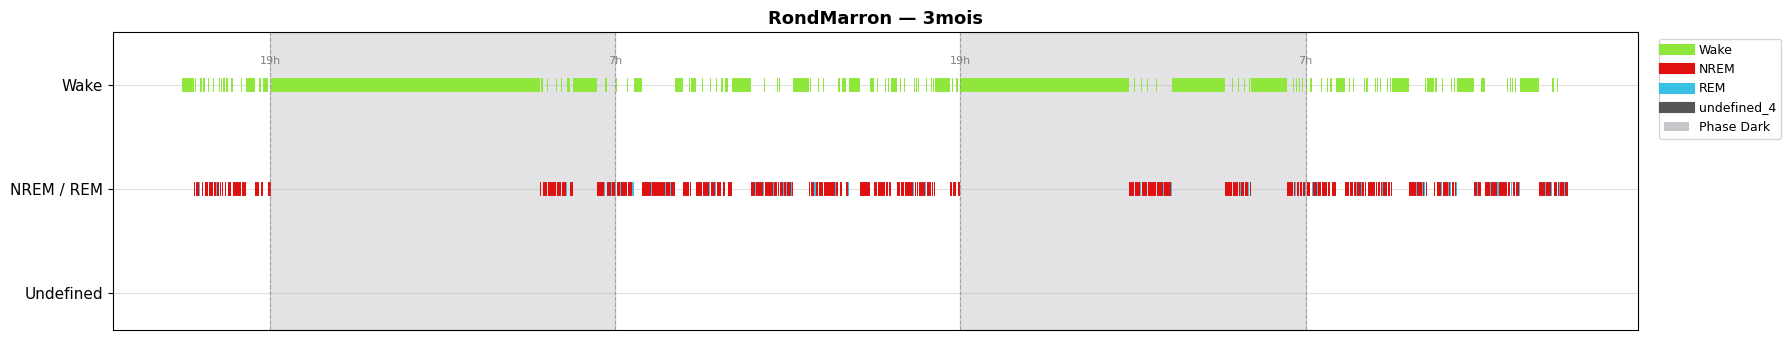

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondMarron\3mois\Hypnogramme_RondMarron_3mois.png

  Souris : RondMarron  |  Age : 6mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34636 epochs | duree totale : 48.11h
   Contenu recording_start.txt : [24/06/2025 16:08:24]
   Debut enregistrement : 2025-06-24 16:08:24  (format %d/%m/%Y %H:%M:%S)
   510 episodes regroupe(s)


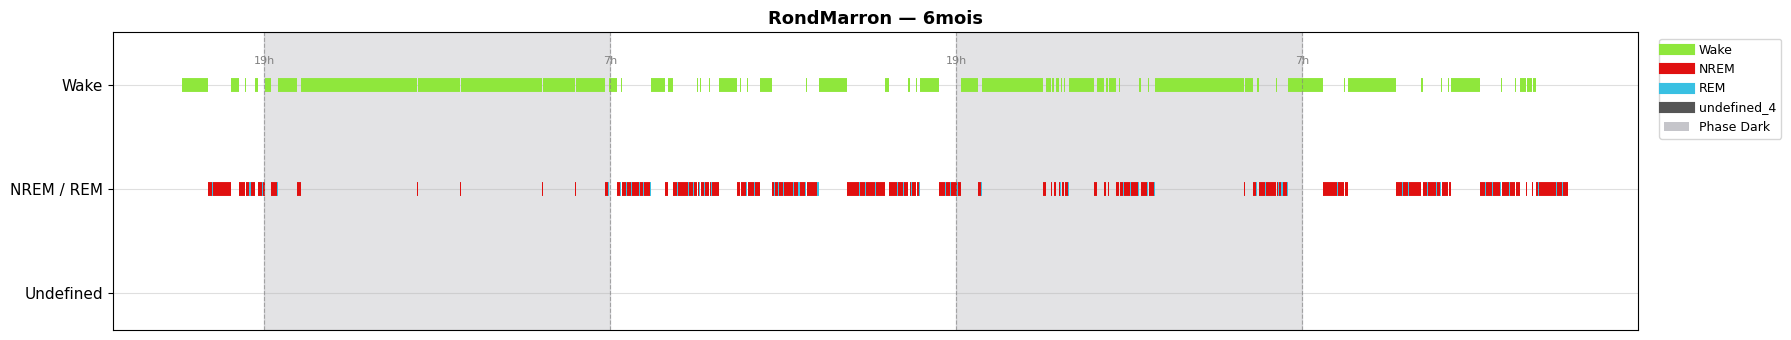

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondMarron\6mois\Hypnogramme_RondMarron_6mois.png

  Souris : RondNoir  |  Age : 3mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   3620 epochs | duree totale : 4.94h
   Contenu recording_start.txt : [07/04/2025 15:56:32]
   Debut enregistrement : 2025-04-07 15:56:32  (format %d/%m/%Y %H:%M:%S)
   204 episodes regroupe(s)


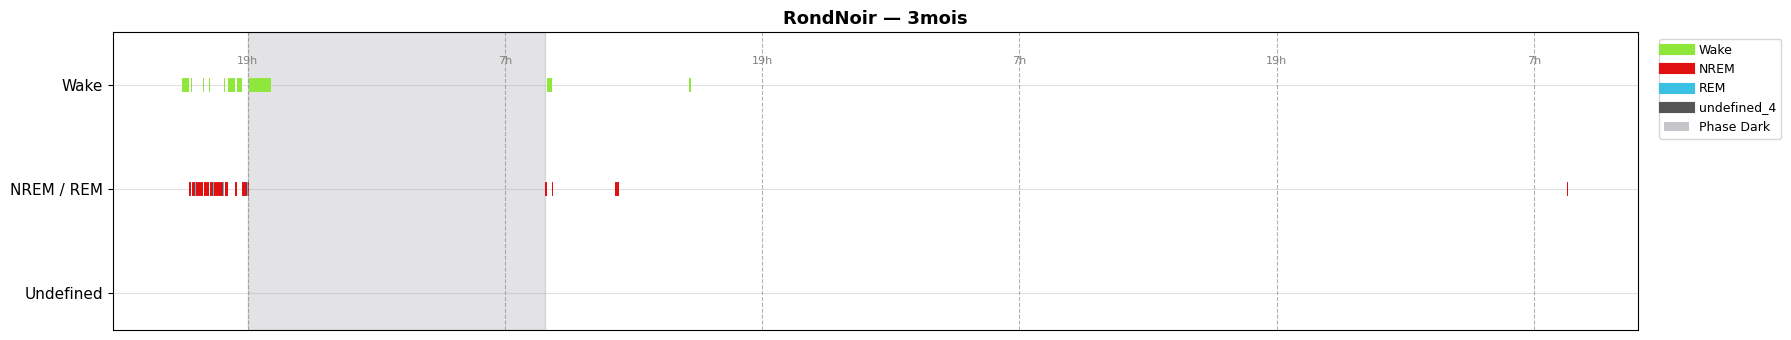

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondNoir\3mois\Hypnogramme_RondNoir_3mois.png

  Souris : RondOrange  |  Age : 3mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   1940 epochs | duree totale : 2.66h
   Contenu recording_start.txt : [07/04/2025 15:56:32]
   Debut enregistrement : 2025-04-07 15:56:32  (format %d/%m/%Y %H:%M:%S)
   92 episodes regroupe(s)


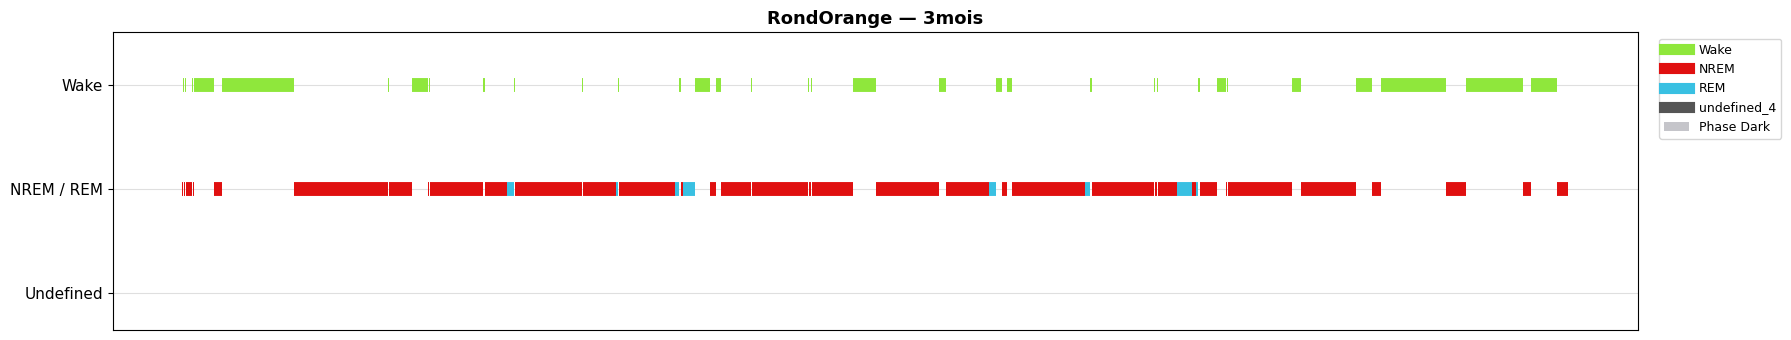

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondOrange\3mois\Hypnogramme_RondOrange_3mois.png
     Aucune donnee pour la phase Dark

  Souris : RondOrange  |  Age : 4mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   2873 epochs | duree totale : 3.96h
   Contenu recording_start.txt : [30/04/2025 09:53:23]
   Debut enregistrement : 2025-04-30 09:53:23  (format %d/%m/%Y %H:%M:%S)
   88 episodes regroupe(s)


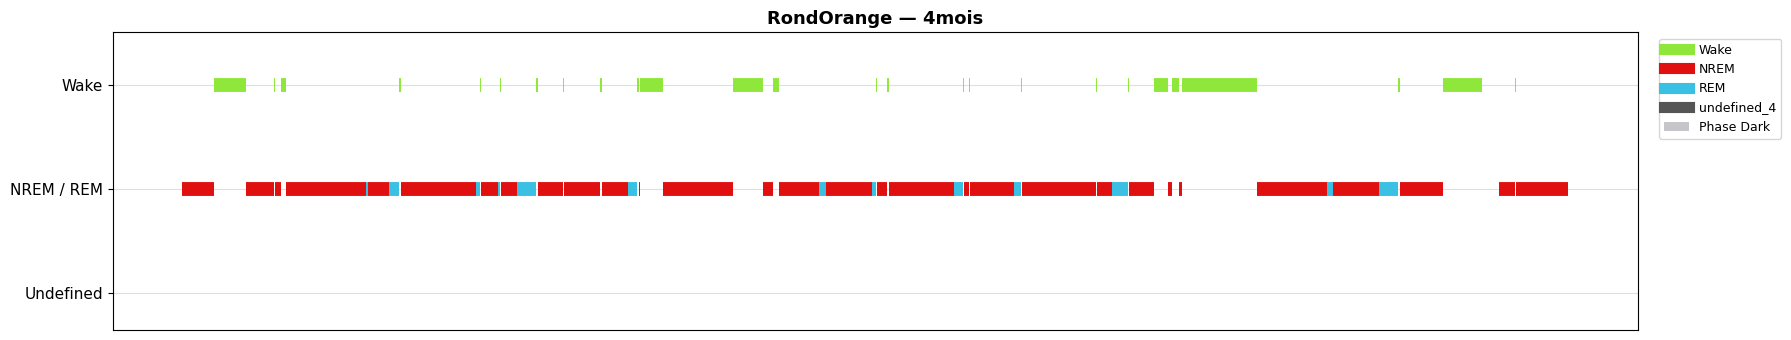

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondOrange\4mois\Hypnogramme_RondOrange_4mois.png
     Aucune donnee pour la phase Dark

  Souris : RondOrange  |  Age : 5mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   4855 epochs | duree totale : 6.74h
   Contenu recording_start.txt : [10/06/2025 16:14:53]
   Debut enregistrement : 2025-06-10 16:14:53  (format %d/%m/%Y %H:%M:%S)
   253 episodes regroupe(s)


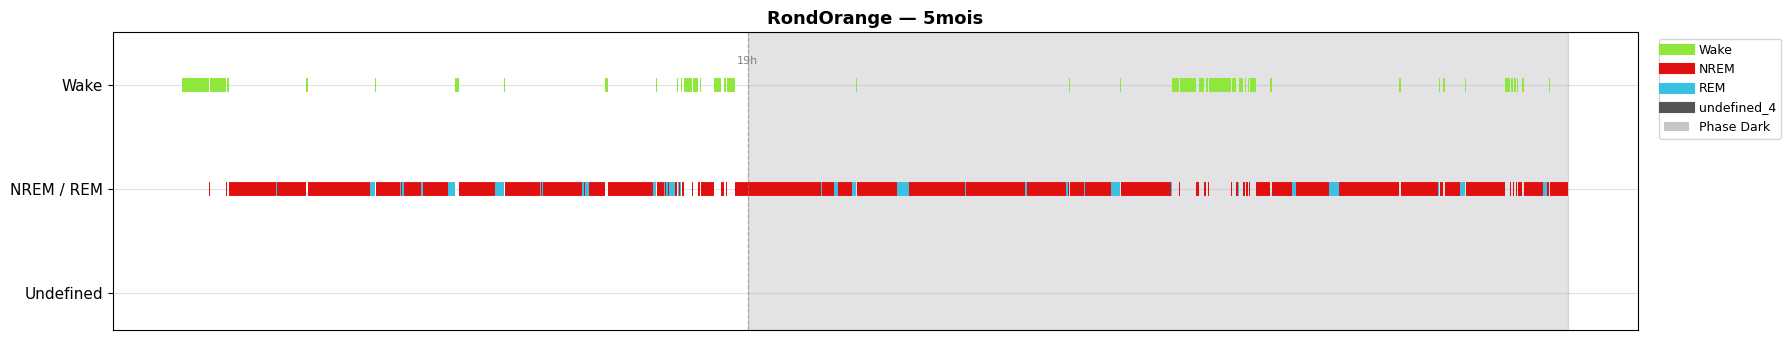

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondOrange\5mois\Hypnogramme_RondOrange_5mois.png

  Souris : RondOrange  |  Age : 6mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   8384 epochs | duree totale : 48.87h
   Contenu recording_start.txt : [07/07/2025 16:34:52]
   Debut enregistrement : 2025-07-07 16:34:52  (format %d/%m/%Y %H:%M:%S)
   891 episodes regroupe(s)


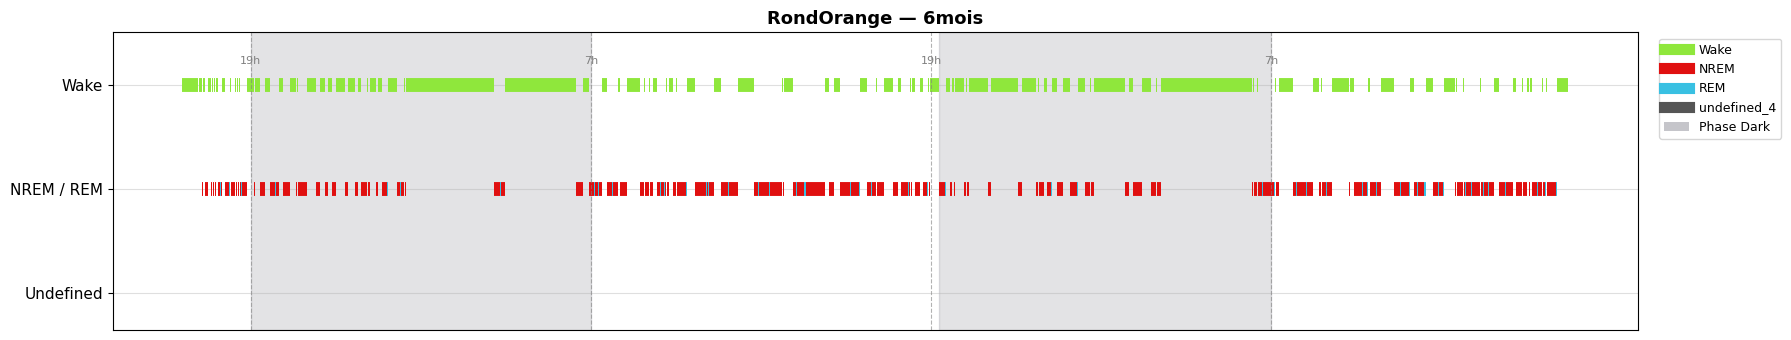

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondOrange\6mois\Hypnogramme_RondOrange_6mois.png

  Souris : RondOrange  |  Age : 8mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   9131 epochs | duree totale : 48.09h
   Contenu recording_start.txt : [01/09/2025 17:44:25]
   Debut enregistrement : 2025-09-01 17:44:25  (format %d/%m/%Y %H:%M:%S)
   1324 episodes regroupe(s)


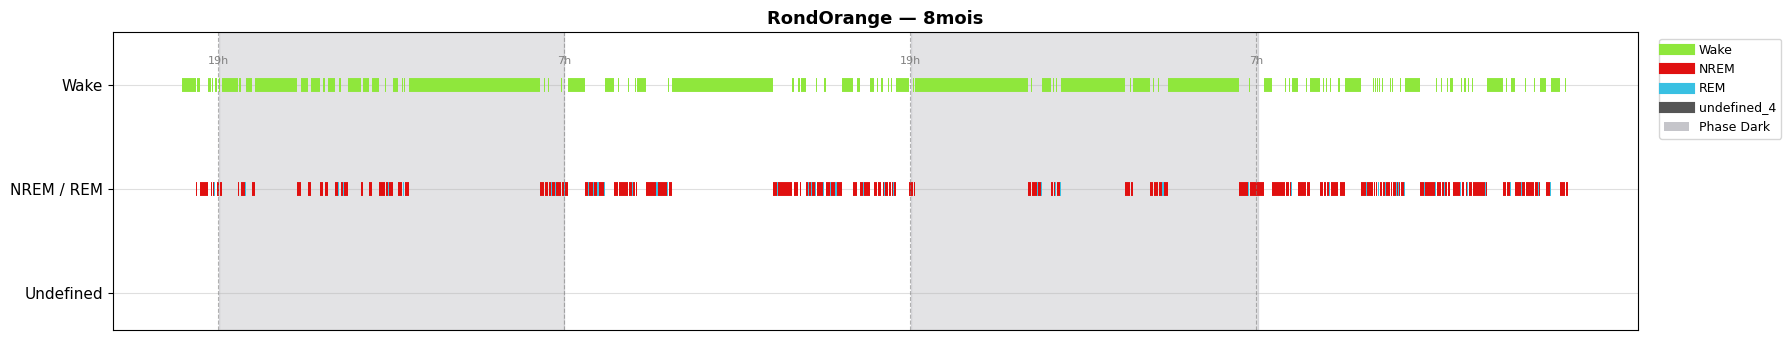

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondOrange\8mois\Hypnogramme_RondOrange_8mois.png

  Souris : RondRouge  |  Age : 4mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   918 epochs | duree totale : 1.26h
   Contenu recording_start.txt : [30/04/2025 09:53:23]
   Debut enregistrement : 2025-04-30 09:53:23  (format %d/%m/%Y %H:%M:%S)
   33 episodes regroupe(s)


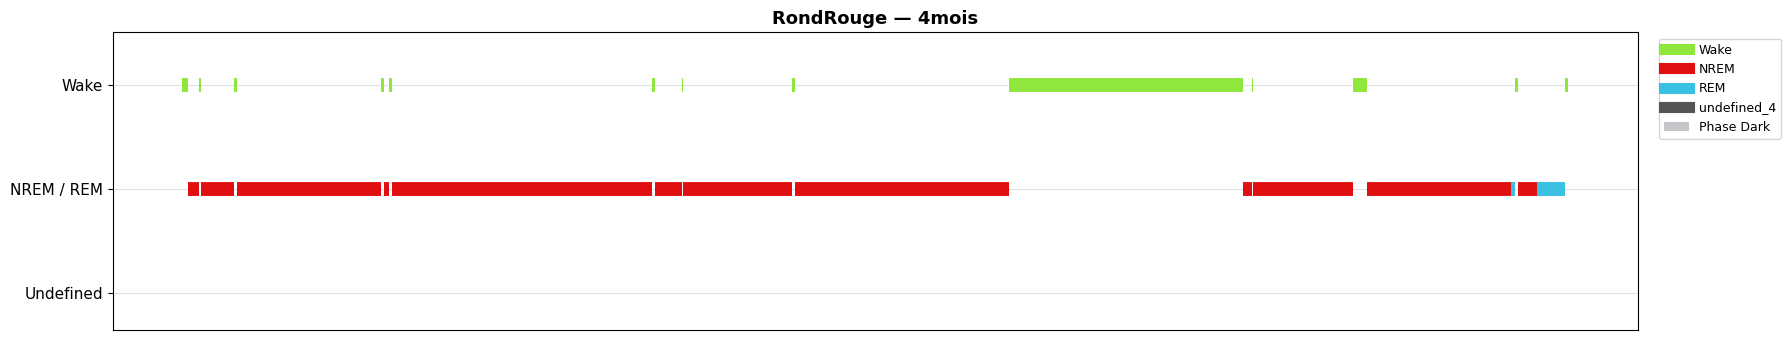

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondRouge\4mois\Hypnogramme_RondRouge_4mois.png
     Aucune donnee pour la phase Dark

  Souris : RondRouge  |  Age : 5mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   2931 epochs | duree totale : 4.01h
   Contenu recording_start.txt : [10/06/2025 16:14:53]
   Debut enregistrement : 2025-06-10 16:14:53  (format %d/%m/%Y %H:%M:%S)
   134 episodes regroupe(s)


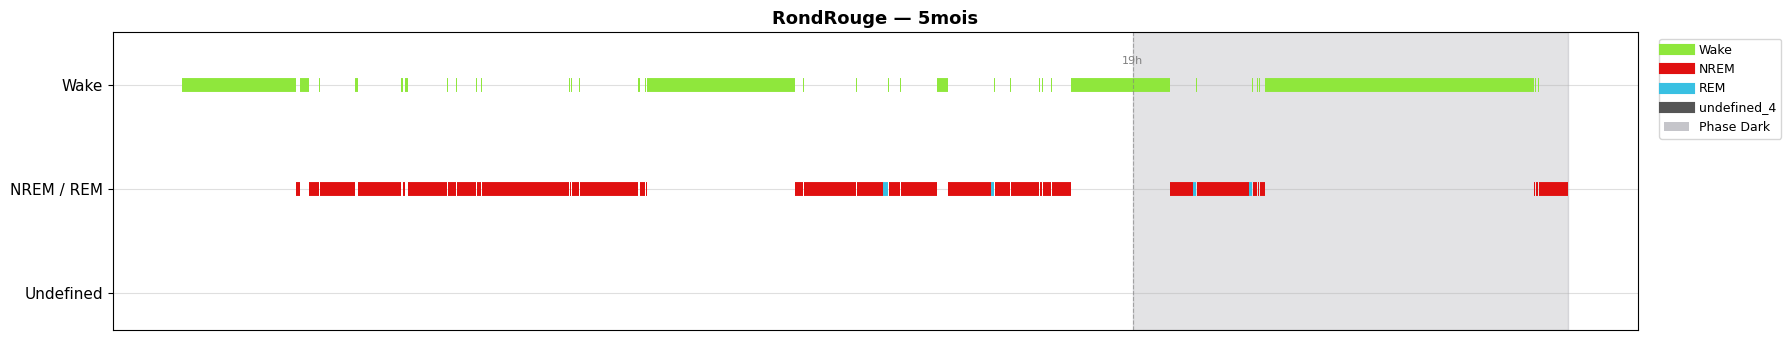

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondRouge\5mois\Hypnogramme_RondRouge_5mois.png

  Souris : RondRouge  |  Age : 6mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   7695 epochs | duree totale : 48.90h
   Contenu recording_start.txt : [07/07/2025 16:34:52]
   Debut enregistrement : 2025-07-07 16:34:52  (format %d/%m/%Y %H:%M:%S)
   1069 episodes regroupe(s)


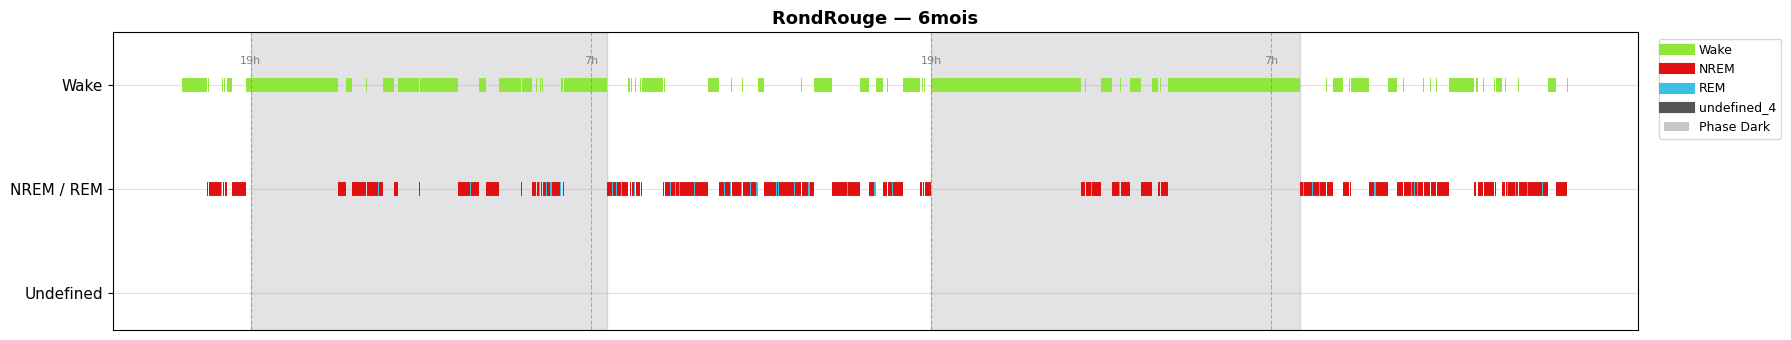

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondRouge\6mois\Hypnogramme_RondRouge_6mois.png

  Souris : RondRouge  |  Age : 7mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   3246 epochs | duree totale : 48.21h
   Contenu recording_start.txt : [04/08/2025 15:55:41]
   Debut enregistrement : 2025-08-04 15:55:41  (format %d/%m/%Y %H:%M:%S)
   356 episodes regroupe(s)


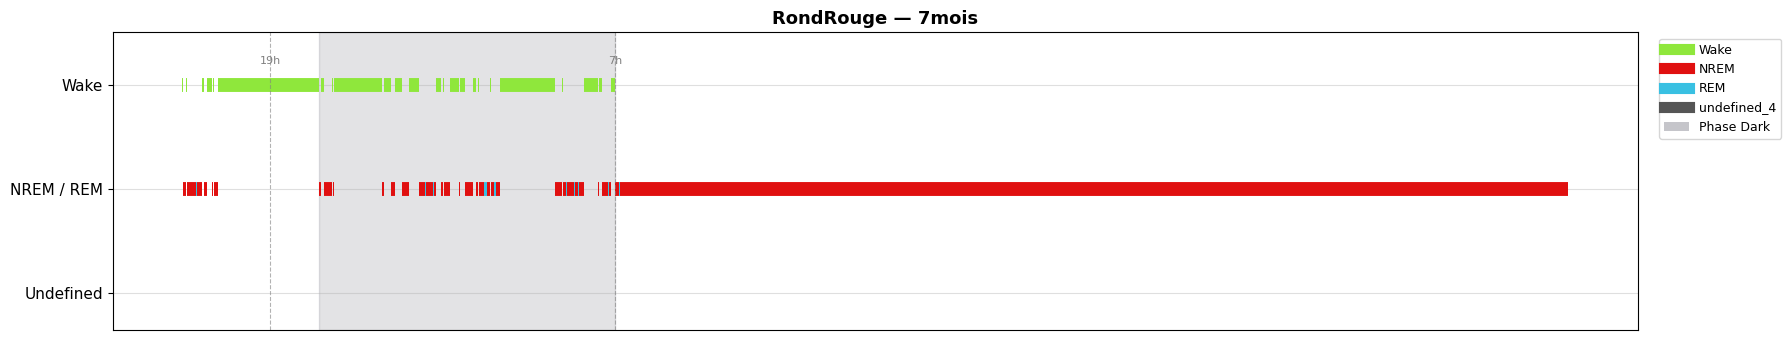

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondRouge\7mois\Hypnogramme_RondRouge_7mois.png

  Souris : RondRouge  |  Age : 8mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   9814 epochs | duree totale : 48.09h
   Contenu recording_start.txt : [01/09/2025 17:44:25]
   Debut enregistrement : 2025-09-01 17:44:25  (format %d/%m/%Y %H:%M:%S)
   856 episodes regroupe(s)


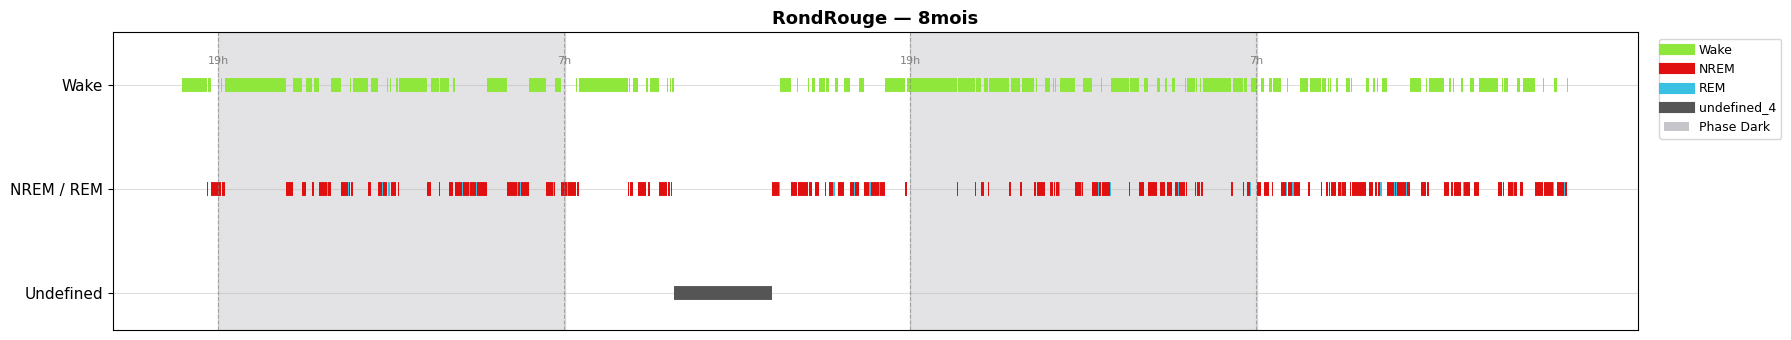

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondRouge\8mois\Hypnogramme_RondRouge_8mois.png

  Souris : RondVert  |  Age : 3mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   1414 epochs | duree totale : 1.90h
   Contenu recording_start.txt : [01/04/2025 16:s52:14]
   ERREUR : format de date non reconnu : [01/04/2025 16:s52:14] — souris ignoree

  Souris : RondViolet  |  Age : 3mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   3784 epochs | duree totale : 5.22h
   Contenu recording_start.txt : [01/04/2025 16:52:14]
   Debut enregistrement : 2025-04-01 16:52:14  (format %d/%m/%Y %H:%M:%S)
   119 episodes regroupe(s)


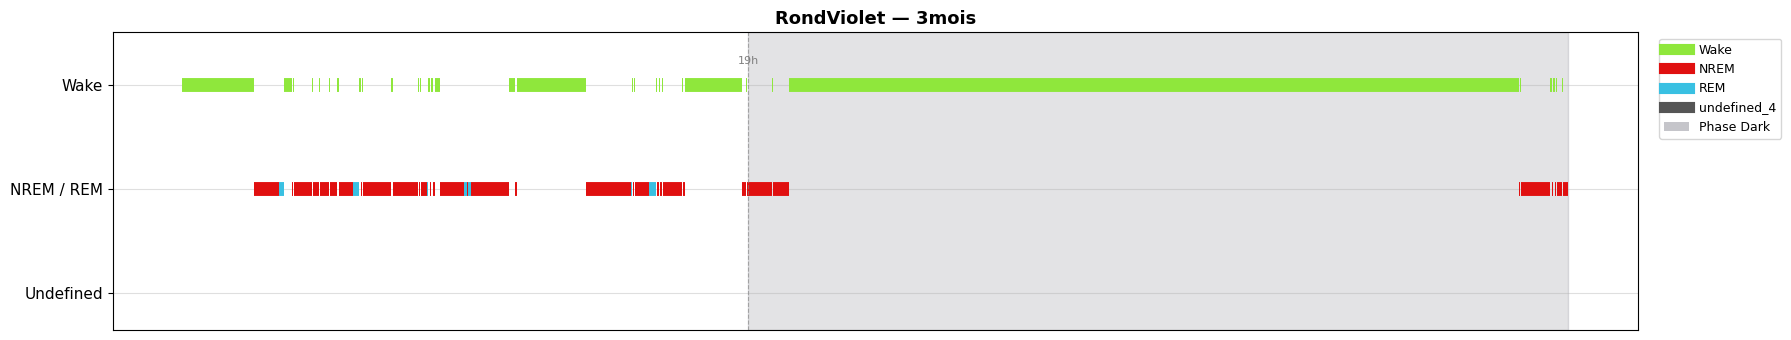

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondViolet\3mois\Hypnogramme_RondViolet_3mois.png

  Souris : RondViolet  |  Age : 4mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   3162 epochs | duree totale : 4.36h
   Contenu recording_start.txt : [30/04/2025 09:53:23]
   Debut enregistrement : 2025-04-30 09:53:23  (format %d/%m/%Y %H:%M:%S)
   113 episodes regroupe(s)


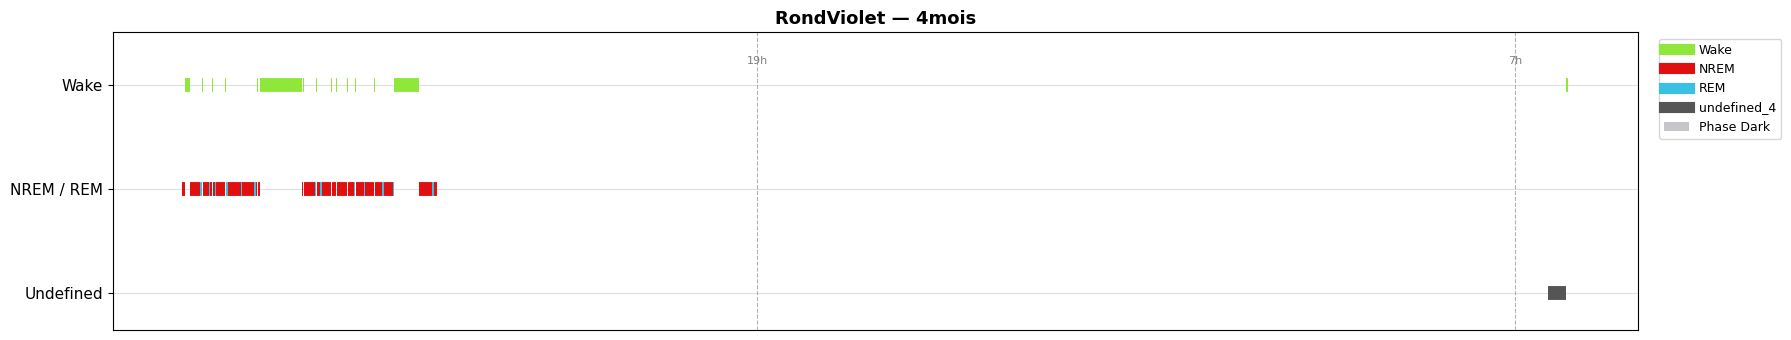

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondViolet\4mois\Hypnogramme_RondViolet_4mois.png
     Aucune donnee pour la phase Dark

  Souris : RondViolet  |  Age : 7mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   14375 epochs | duree totale : 48.43h
   Contenu recording_start.txt : [01/08/2025 17:15:29]
   Debut enregistrement : 2025-08-01 17:15:29  (format %d/%m/%Y %H:%M:%S)
   2436 episodes regroupe(s)


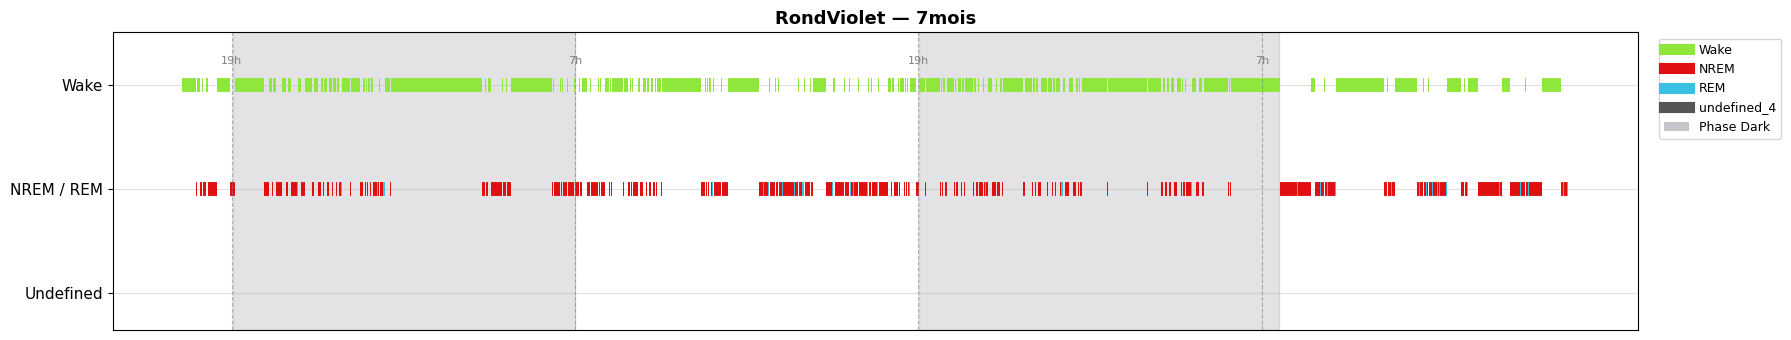

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondViolet\7mois\Hypnogramme_RondViolet_7mois.png

  Souris : RondViolet  |  Age : 8mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   588 epochs | duree totale : 65.80h
   Contenu recording_start.txt : [28/08/2025 16:26:10]
   Debut enregistrement : 2025-08-28 16:26:10  (format %d/%m/%Y %H:%M:%S)
   6 episodes regroupe(s)


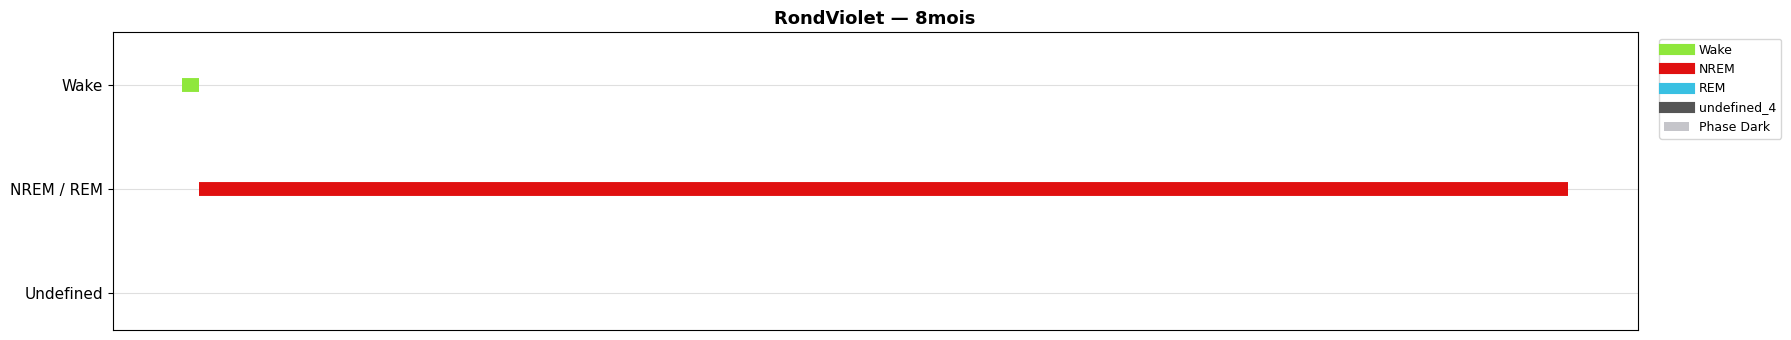

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\RondViolet\8mois\Hypnogramme_RondViolet_8mois.png
     Aucune donnee pour la phase Dark

  Souris : TraitRouge  |  Age : 10mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   35379 epochs | duree totale : 49.14h
   Contenu recording_start.txt : [25/08/2025 16:44:29]
   Debut enregistrement : 2025-08-25 16:44:29  (format %d/%m/%Y %H:%M:%S)
   1303 episodes regroupe(s)


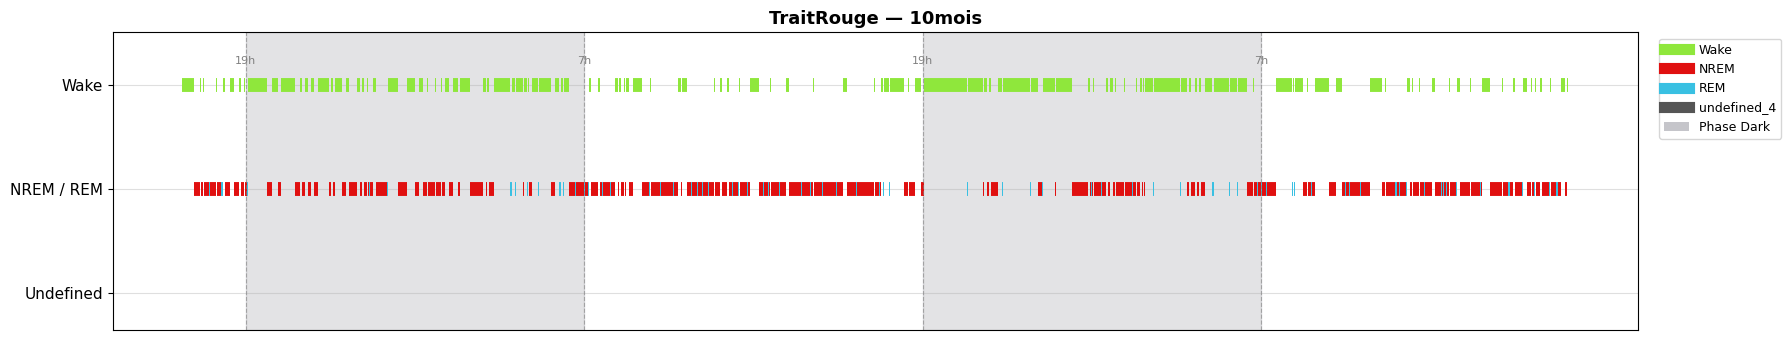

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitRouge\10mois\Hypnogramme_TraitRouge_10mois.png

  Souris : TraitRouge  |  Age : 11mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   35379 epochs | duree totale : 49.14h
   Contenu recording_start.txt : [30/09/2025 08:55:04]
   Debut enregistrement : 2025-09-30 08:55:04  (format %d/%m/%Y %H:%M:%S)
   1090 episodes regroupe(s)


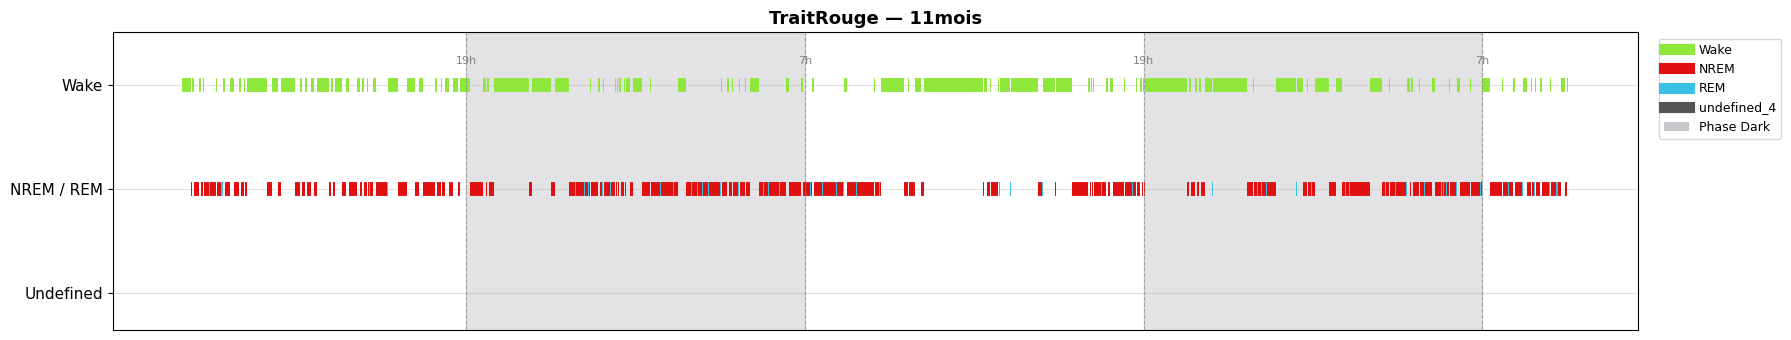

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitRouge\11mois\Hypnogramme_TraitRouge_11mois.png

  Souris : TraitRouge  |  Age : 12mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34650 epochs | duree totale : 48.12h
   Contenu recording_start.txt : [27/10/2025 15:59:41]
   Debut enregistrement : 2025-10-27 15:59:41  (format %d/%m/%Y %H:%M:%S)
   969 episodes regroupe(s)


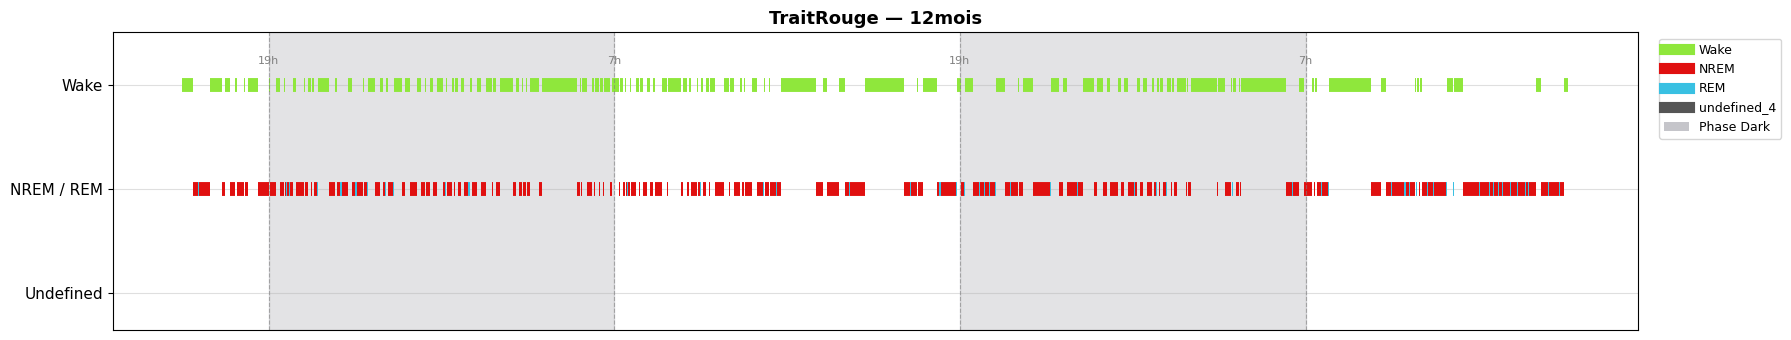

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitRouge\12mois\Hypnogramme_TraitRouge_12mois.png

  Souris : TraitRouge  |  Age : 4mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   3070 epochs | duree totale : 4.22h
   Contenu recording_start.txt : [28/02/2025 17:57:01]
   Debut enregistrement : 2025-02-28 17:57:01  (format %d/%m/%Y %H:%M:%S)
   85 episodes regroupe(s)


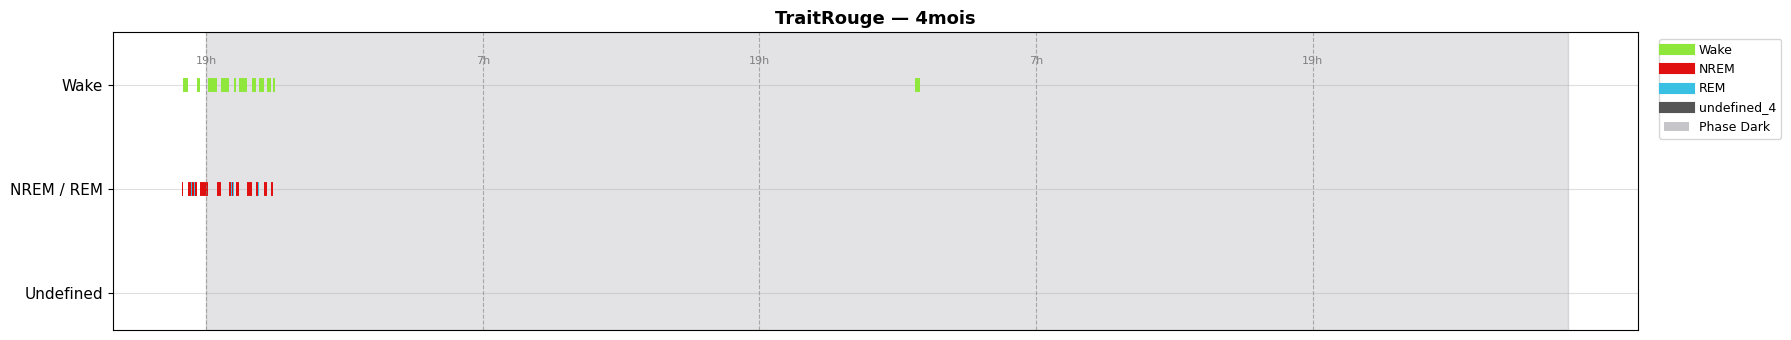

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitRouge\4mois\Hypnogramme_TraitRouge_4mois.png

  Souris : TraitRouge  |  Age : 5mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   45593 epochs | duree totale : 63.32h
   Contenu recording_start.txt : [28/03/2025 17:29:35]
   Debut enregistrement : 2025-03-28 17:29:35  (format %d/%m/%Y %H:%M:%S)
   1863 episodes regroupe(s)


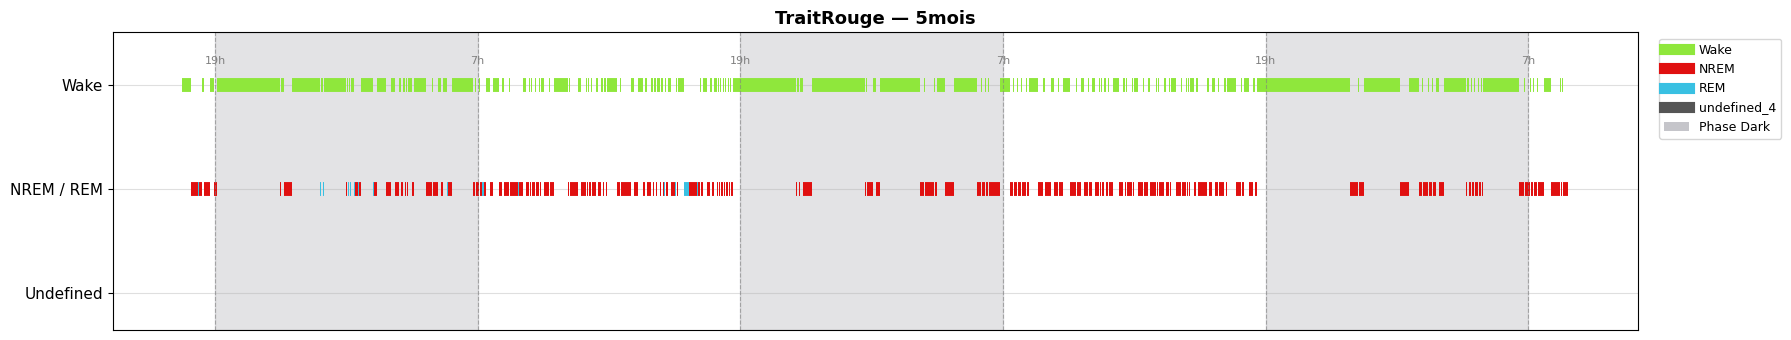

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitRouge\5mois\Hypnogramme_TraitRouge_5mois.png

  Souris : TraitRouge  |  Age : 7mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34716 epochs | duree totale : 48.22h
   Contenu recording_start.txt : [26/05/2025 17:01:34]
   Debut enregistrement : 2025-05-26 17:01:34  (format %d/%m/%Y %H:%M:%S)
   1238 episodes regroupe(s)


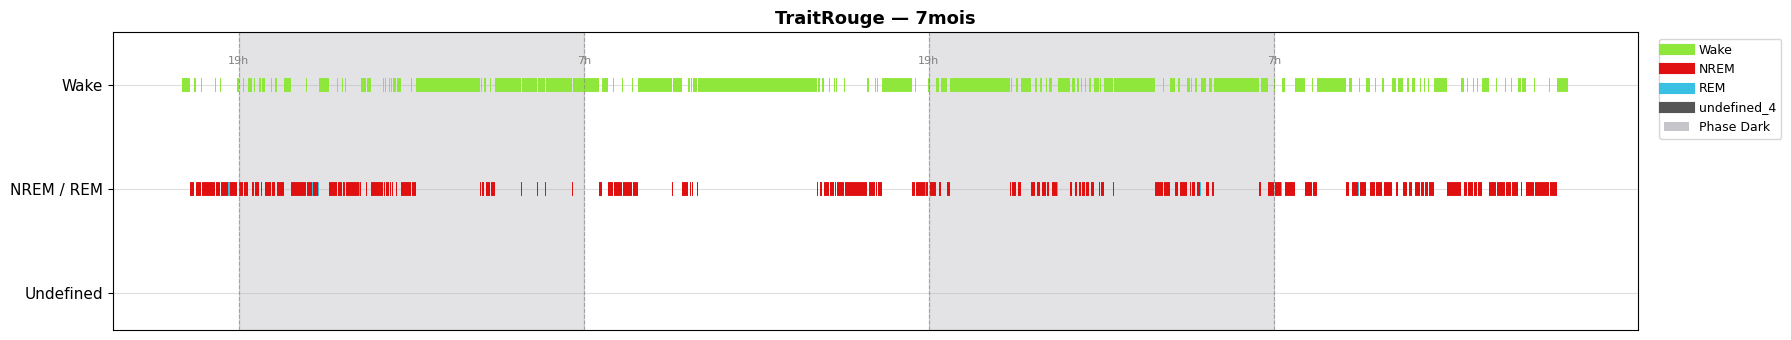

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitRouge\7mois\Hypnogramme_TraitRouge_7mois.png

  Souris : TraitRouge  |  Age : 9mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   39116 epochs | duree totale : 54.33h
   Contenu recording_start.txt : [26/07/2025 10:26:14]
   Debut enregistrement : 2025-07-26 10:26:14  (format %d/%m/%Y %H:%M:%S)
   805 episodes regroupe(s)


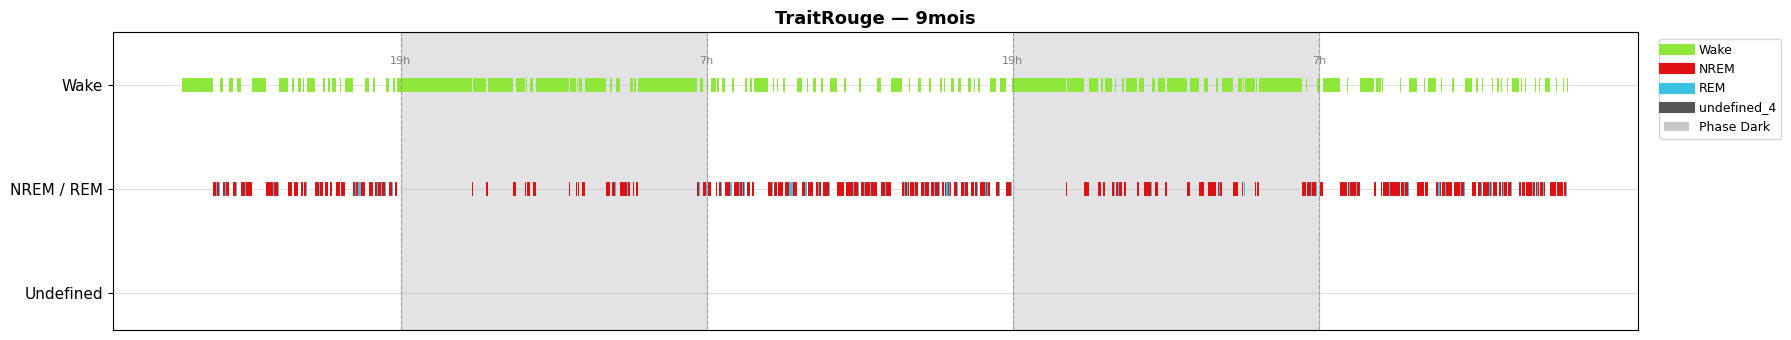

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitRouge\9mois\Hypnogramme_TraitRouge_9mois.png

  Souris : TraitVert  |  Age : 4mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   1013 epochs | duree totale : 1.39h
   Contenu recording_start.txt : [28/02/2025 17:57:01]
   Debut enregistrement : 2025-02-28 17:57:01  (format %d/%m/%Y %H:%M:%S)
   36 episodes regroupe(s)


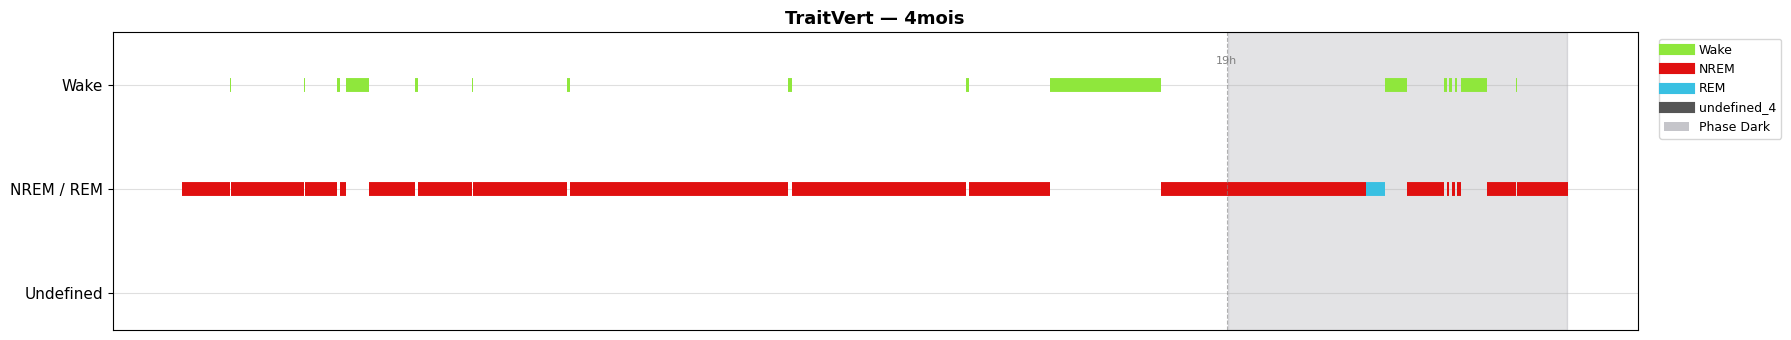

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitVert\4mois\Hypnogramme_TraitVert_4mois.png

  Souris : TraitVert  |  Age : 5mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   1019 epochs | duree totale : 1.41h
   Contenu recording_start.txt : [28/03/2025 17:29:35]
   Debut enregistrement : 2025-03-28 17:29:35  (format %d/%m/%Y %H:%M:%S)
   13 episodes regroupe(s)


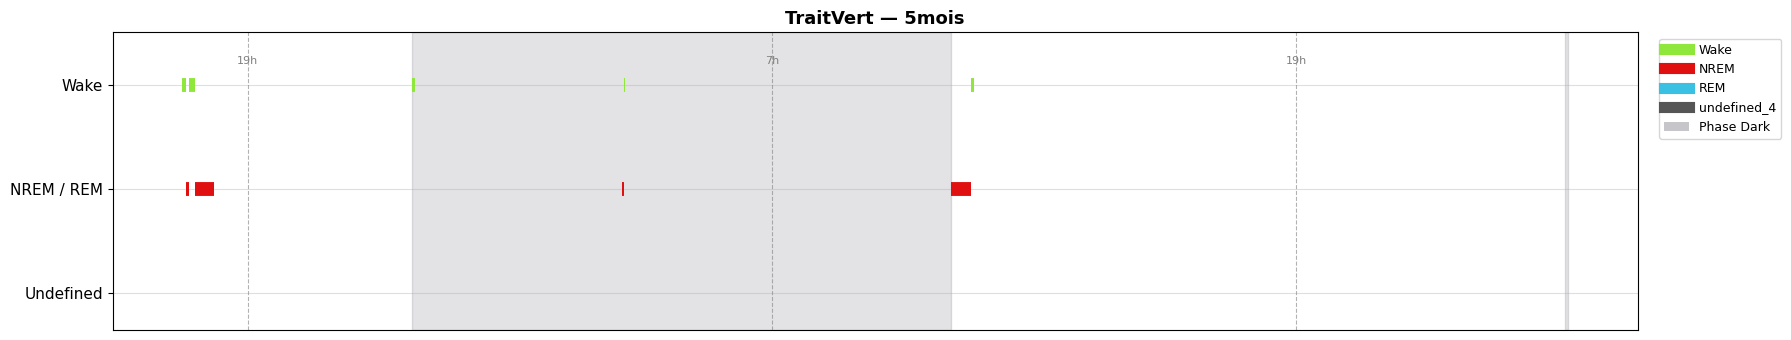

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitVert\5mois\Hypnogramme_TraitVert_5mois.png

  Souris : TraitViolet  |  Age : 10mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   35379 epochs | duree totale : 49.14h
   Contenu recording_start.txt : [25/08/2025 16:44:29]
   Debut enregistrement : 2025-08-25 16:44:29  (format %d/%m/%Y %H:%M:%S)
   1505 episodes regroupe(s)


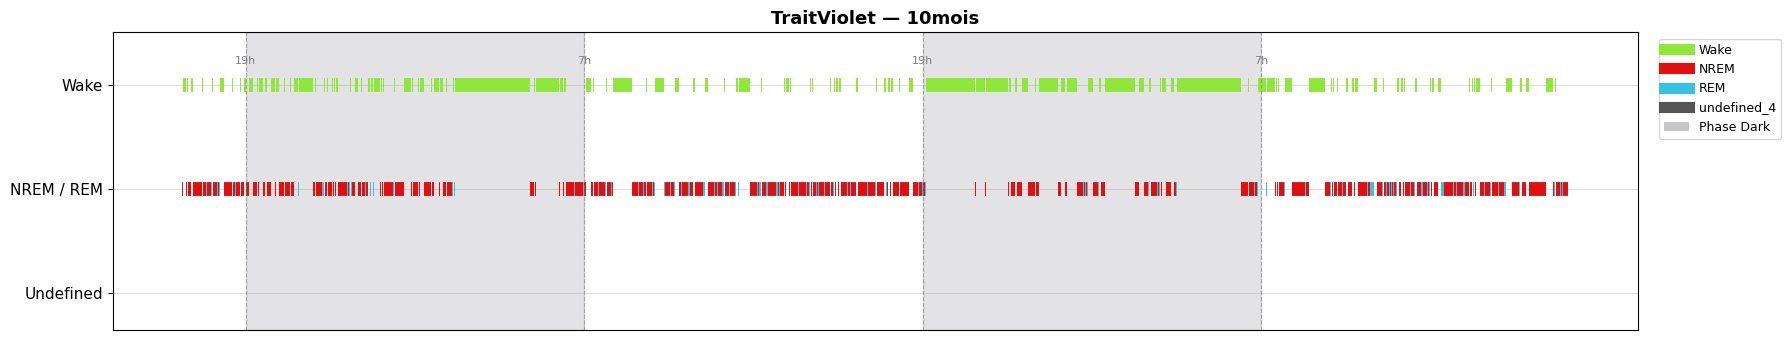

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitViolet\10mois\Hypnogramme_TraitViolet_10mois.png

  Souris : TraitViolet  |  Age : 4mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   45706 epochs | duree totale : 63.38h
   Contenu recording_start.txt : [28/02/2025 17:57:01]
   Debut enregistrement : 2025-02-28 17:57:01  (format %d/%m/%Y %H:%M:%S)
   2321 episodes regroupe(s)


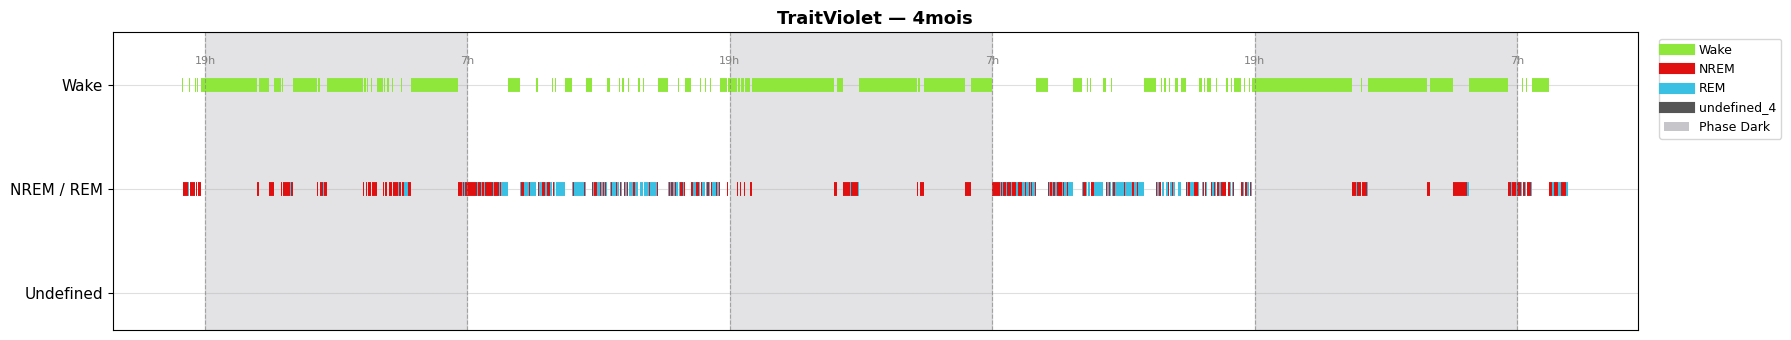

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitViolet\4mois\Hypnogramme_TraitViolet_4mois.png

  Souris : TraitViolet  |  Age : 5mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   45593 epochs | duree totale : 63.32h
   Contenu recording_start.txt : [28/03/2025 17:29:35]
   Debut enregistrement : 2025-03-28 17:29:35  (format %d/%m/%Y %H:%M:%S)
   532 episodes regroupe(s)


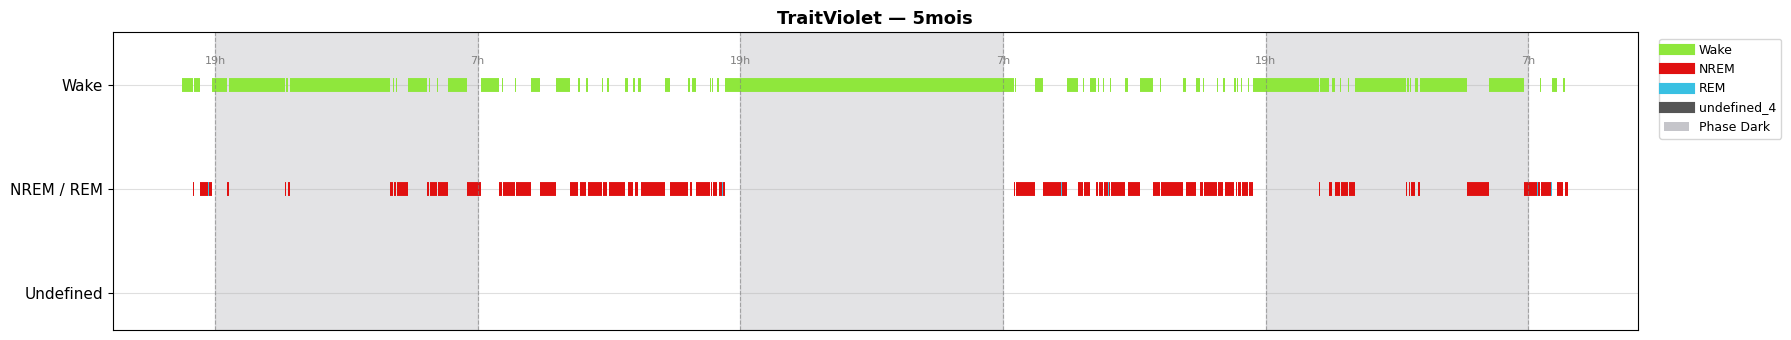

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitViolet\5mois\Hypnogramme_TraitViolet_5mois.png

  Souris : TraitViolet  |  Age : 7mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34716 epochs | duree totale : 48.22h
   Contenu recording_start.txt : [26/05/2025 17:01:34]
   Debut enregistrement : 2025-05-26 17:01:34  (format %d/%m/%Y %H:%M:%S)
   3827 episodes regroupe(s)


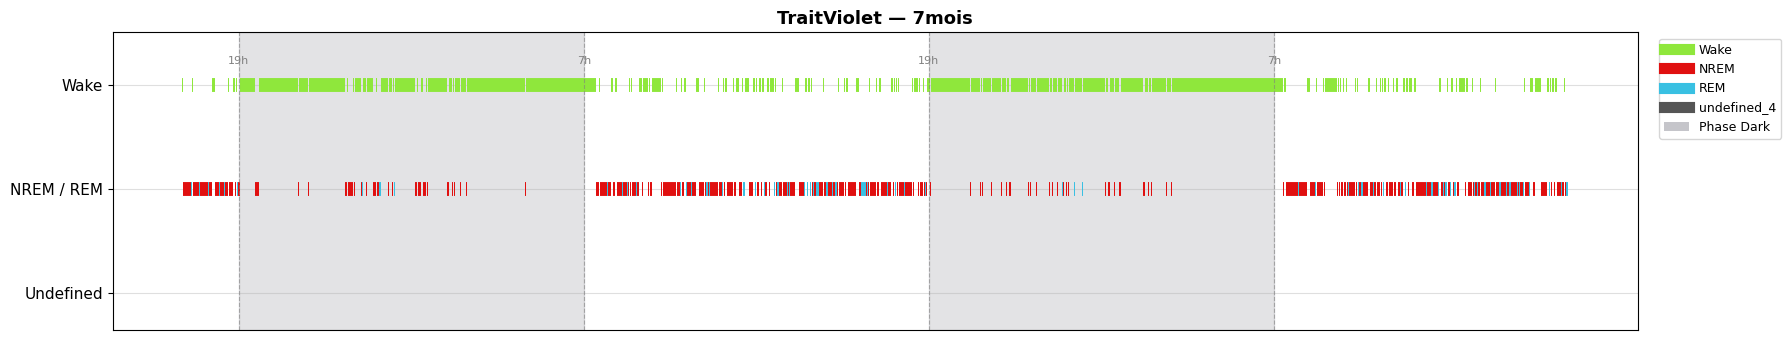

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitViolet\7mois\Hypnogramme_TraitViolet_7mois.png

  Souris : TraitViolet  |  Age : 9mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   39116 epochs | duree totale : 54.33h
   Contenu recording_start.txt : [26/07/2025 10:26:14]
   Debut enregistrement : 2025-07-26 10:26:14  (format %d/%m/%Y %H:%M:%S)
   4574 episodes regroupe(s)


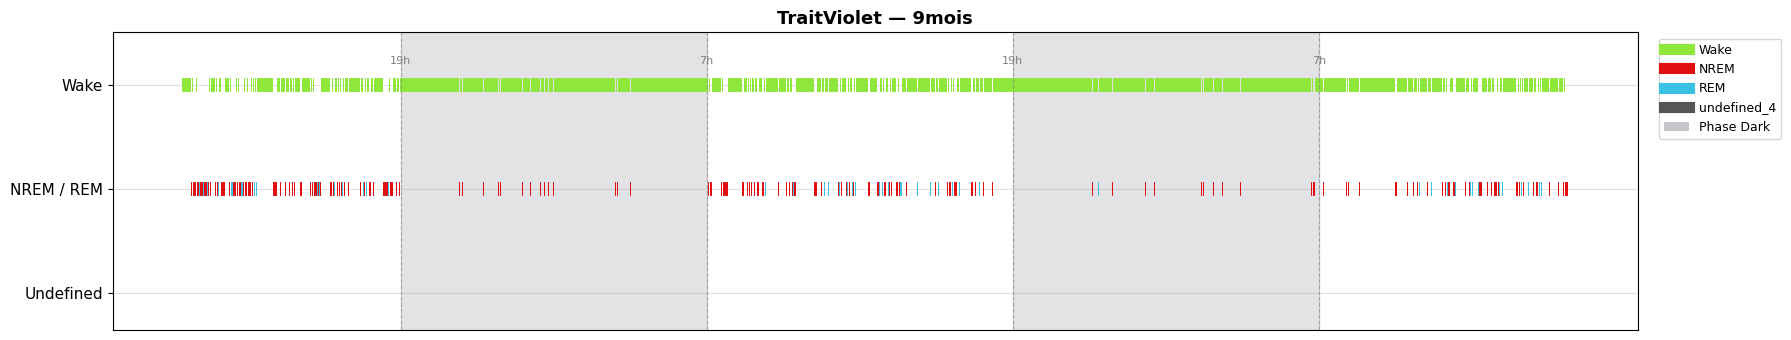

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TraitViolet\9mois\Hypnogramme_TraitViolet_9mois.png

  Souris : TriangleBlanc  |  Age : 3mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   5222 epochs | duree totale : 48.29h
   Contenu recording_start.txt : [19/08/2025 16:25:28]
   Debut enregistrement : 2025-08-19 16:25:28  (format %d/%m/%Y %H:%M:%S)
   1168 episodes regroupe(s)


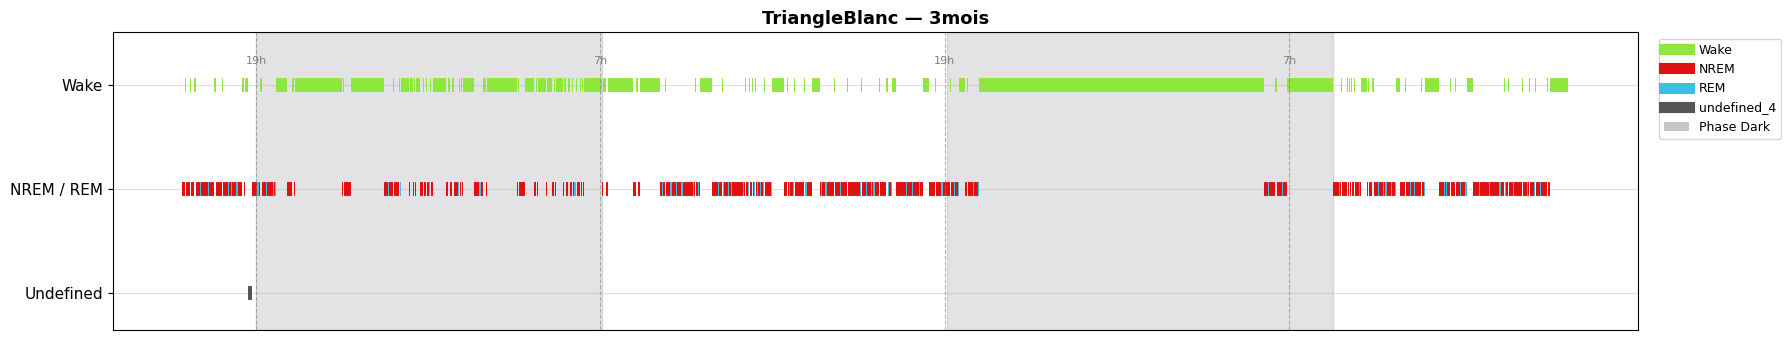

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBlanc\3mois\Hypnogramme_TriangleBlanc_3mois.png

  Souris : TriangleBlanc  |  Age : 4mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   9352 epochs | duree totale : 48.42h
   Contenu recording_start.txt : [24/09/2025 16:33:51]
   Debut enregistrement : 2025-09-24 16:33:51  (format %d/%m/%Y %H:%M:%S)
   1577 episodes regroupe(s)


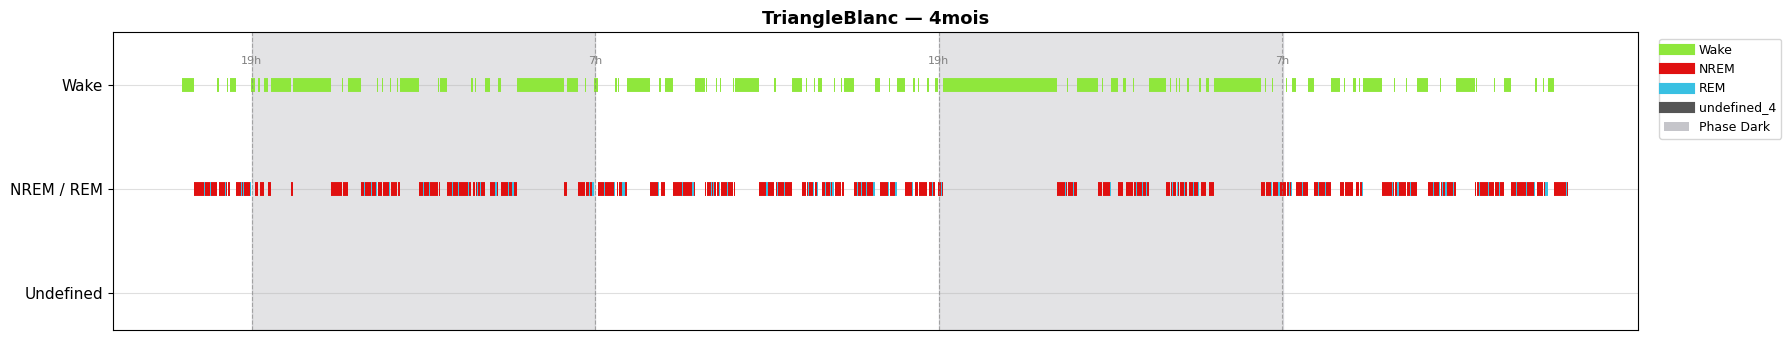

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBlanc\4mois\Hypnogramme_TriangleBlanc_4mois.png

  Souris : TriangleBlanc  |  Age : 5mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   15166 epochs | duree totale : 20.77h
   Contenu recording_start.txt : [22/10/2025 16:20:15]
   Debut enregistrement : 2025-10-22 16:20:15  (format %d/%m/%Y %H:%M:%S)
   667 episodes regroupe(s)


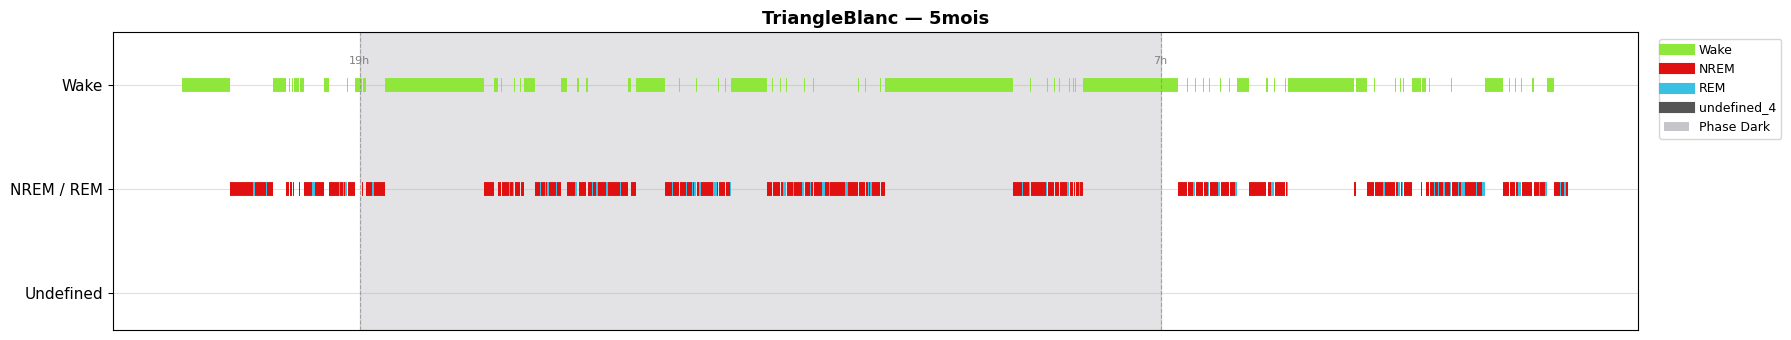

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBlanc\5mois\Hypnogramme_TriangleBlanc_5mois.png

  Souris : TriangleBlanc  |  Age : 6mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   35377 epochs | duree totale : 49.11h
   Contenu recording_start.txt : [24/11/2025 16:35:44]
   Debut enregistrement : 2025-11-24 16:35:44  (format %d/%m/%Y %H:%M:%S)
   1047 episodes regroupe(s)


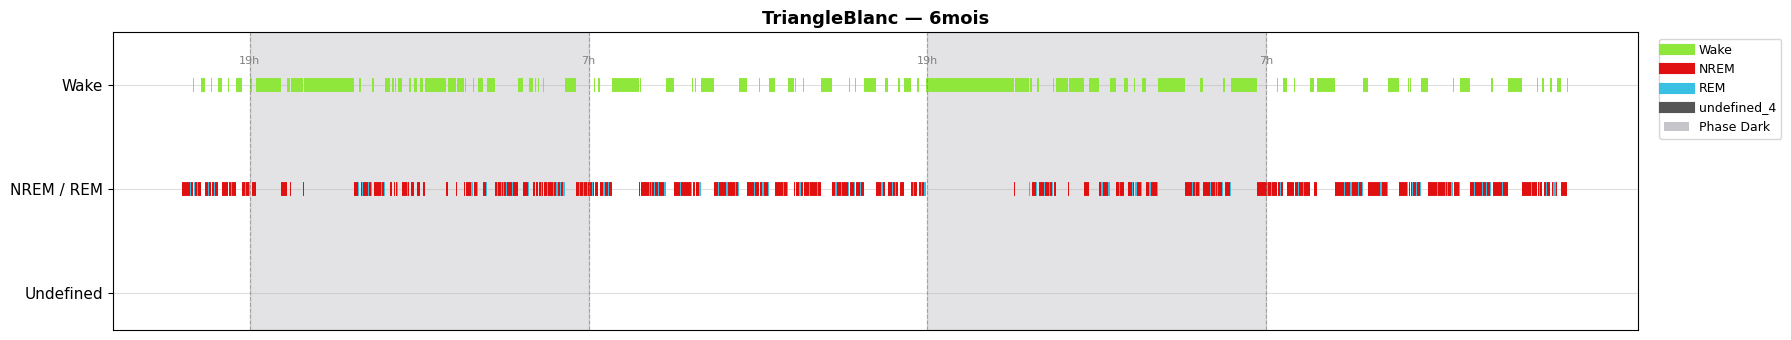

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBlanc\6mois\Hypnogramme_TriangleBlanc_6mois.png

  Souris : TriangleBlanc  |  Age : 7mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   8933 epochs | duree totale : 49.26h
   Contenu recording_start.txt : [17/12/2025 16:47:38]
   Debut enregistrement : 2025-12-17 16:47:38  (format %d/%m/%Y %H:%M:%S)
   1617 episodes regroupe(s)


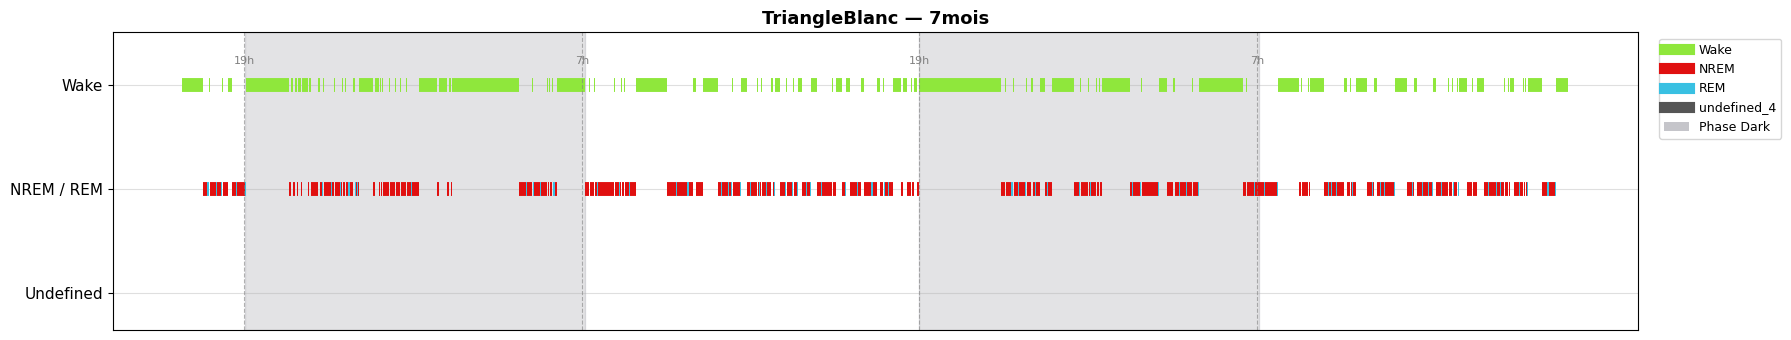

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBlanc\7mois\Hypnogramme_TriangleBlanc_7mois.png

  Souris : TriangleBlanc  |  Age : 8mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   9617 epochs | duree totale : 48.80h
   Contenu recording_start.txt : [21/01/2026 16:01:26]
   Debut enregistrement : 2026-01-21 16:01:26  (format %d/%m/%Y %H:%M:%S)
   1540 episodes regroupe(s)


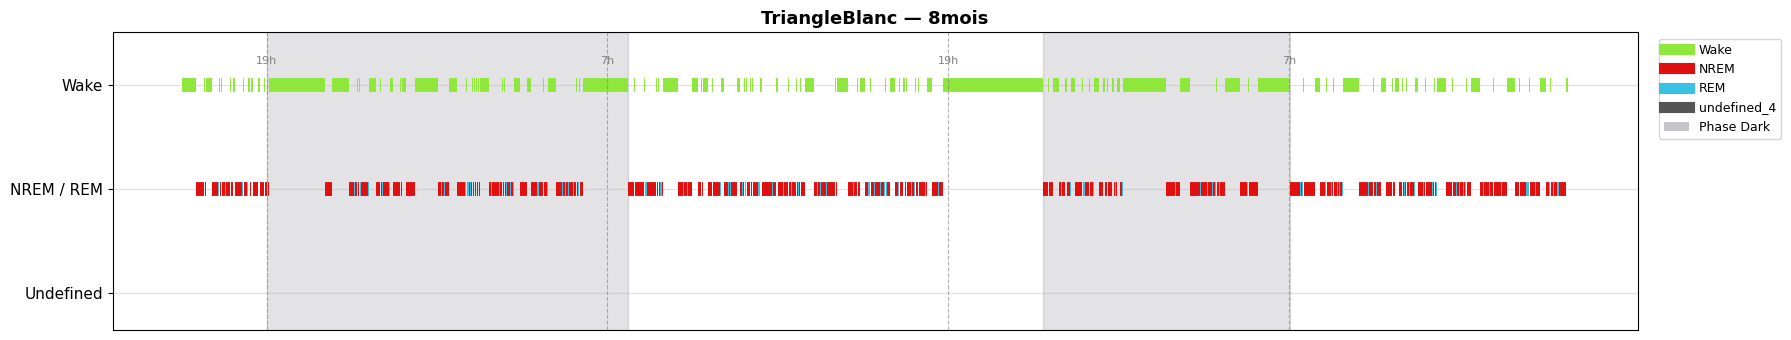

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBlanc\8mois\Hypnogramme_TriangleBlanc_8mois.png

  Souris : TriangleBleu  |  Age : 3mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   34358 epochs | duree totale : 47.66h
   Contenu recording_start.txt : [09/09/2025 17:25:54]
   Debut enregistrement : 2025-09-09 17:25:54  (format %d/%m/%Y %H:%M:%S)
   1097 episodes regroupe(s)


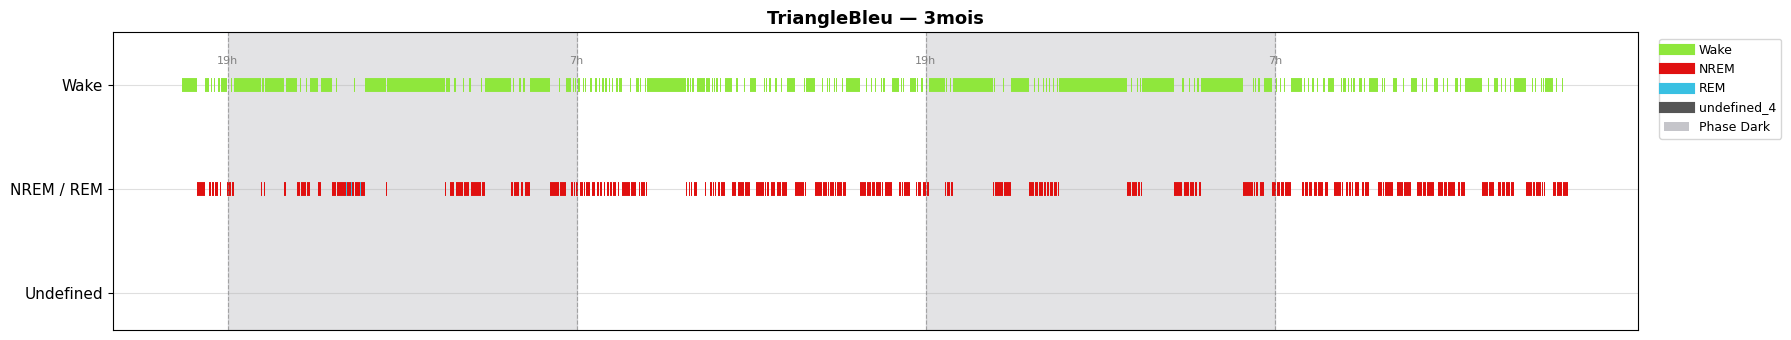

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBleu\3mois\Hypnogramme_TriangleBleu_3mois.png

  Souris : TriangleBleu  |  Age : 4mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   46406 epochs | duree totale : 64.45h
   Contenu recording_start.txt : [14/10/2025 16:26:19]
   Debut enregistrement : 2025-10-14 16:26:19  (format %d/%m/%Y %H:%M:%S)
   1856 episodes regroupe(s)


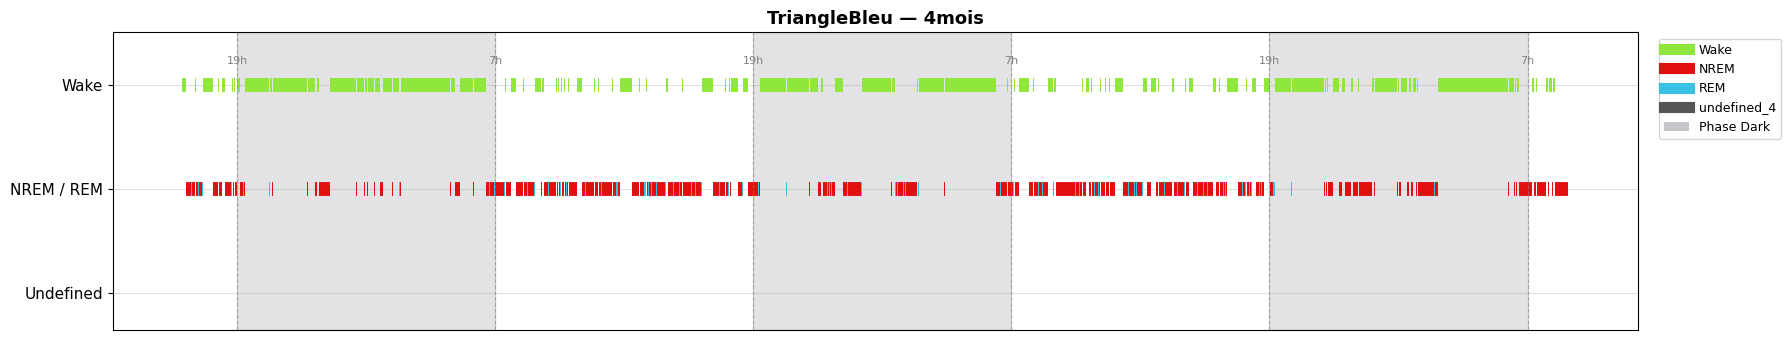

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBleu\4mois\Hypnogramme_TriangleBleu_4mois.png

  Souris : TriangleBleu  |  Age : 5mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34895 epochs | duree totale : 48.47h
   Contenu recording_start.txt : [12/11/2025 17:35:16]
   Debut enregistrement : 2025-11-12 17:35:16  (format %d/%m/%Y %H:%M:%S)
   1 episodes regroupe(s)


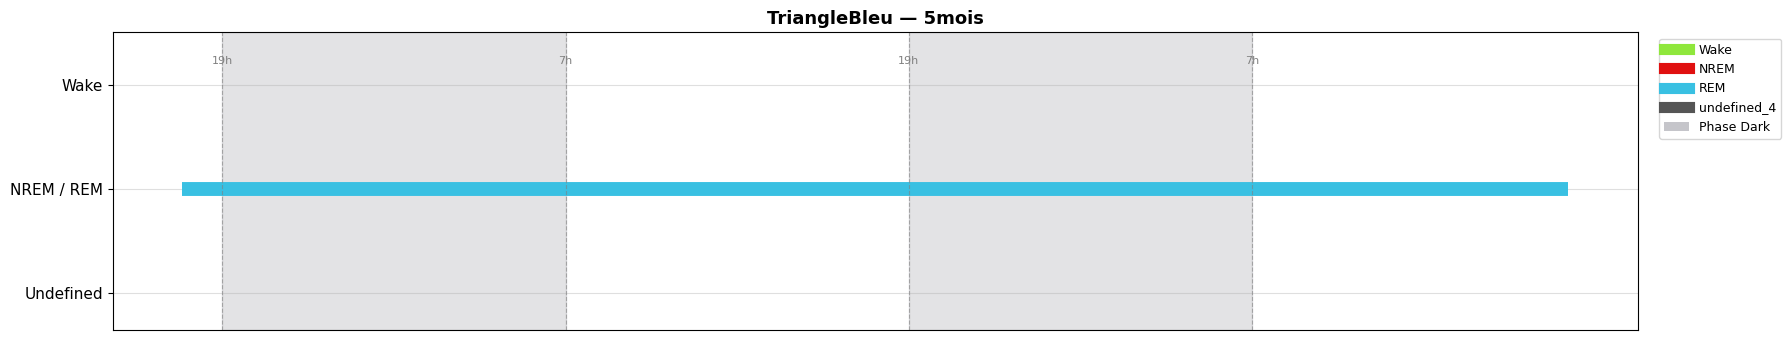

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBleu\5mois\Hypnogramme_TriangleBleu_5mois.png

  Souris : TriangleBleu  |  Age : 6mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   10446 epochs | duree totale : 48.76h
   Contenu recording_start.txt : [08/12/2025 17:02:15]
   Debut enregistrement : 2025-12-08 17:02:15  (format %d/%m/%Y %H:%M:%S)
   2565 episodes regroupe(s)


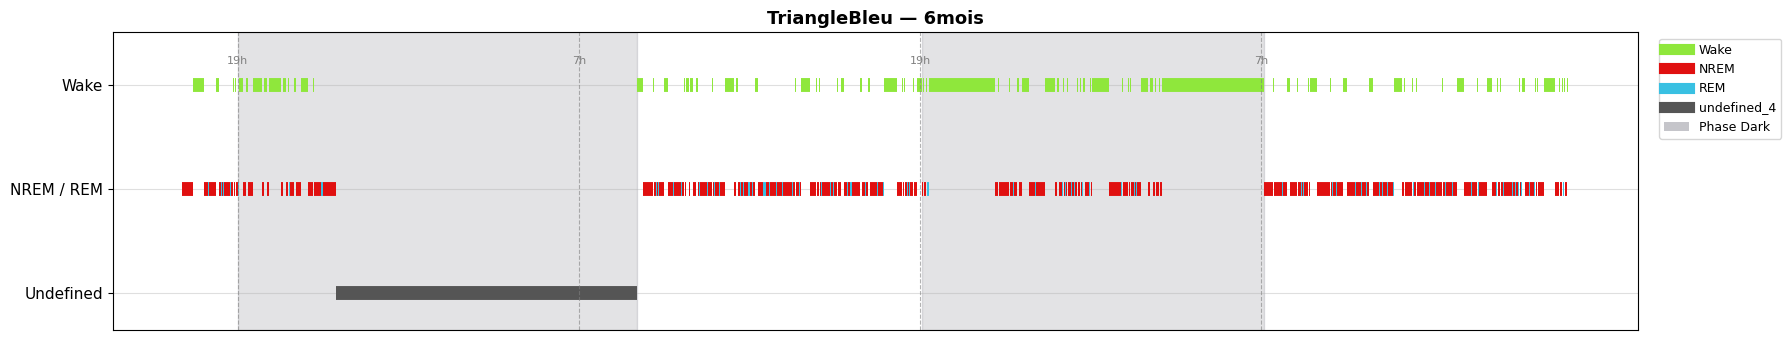

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBleu\6mois\Hypnogramme_TriangleBleu_6mois.png

  Souris : TriangleBleu  |  Age : 7mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   9437 epochs | duree totale : 47.96h
   Contenu recording_start.txt : [14/01/2026 17:23:19]
   Debut enregistrement : 2026-01-14 17:23:19  (format %d/%m/%Y %H:%M:%S)
   2116 episodes regroupe(s)


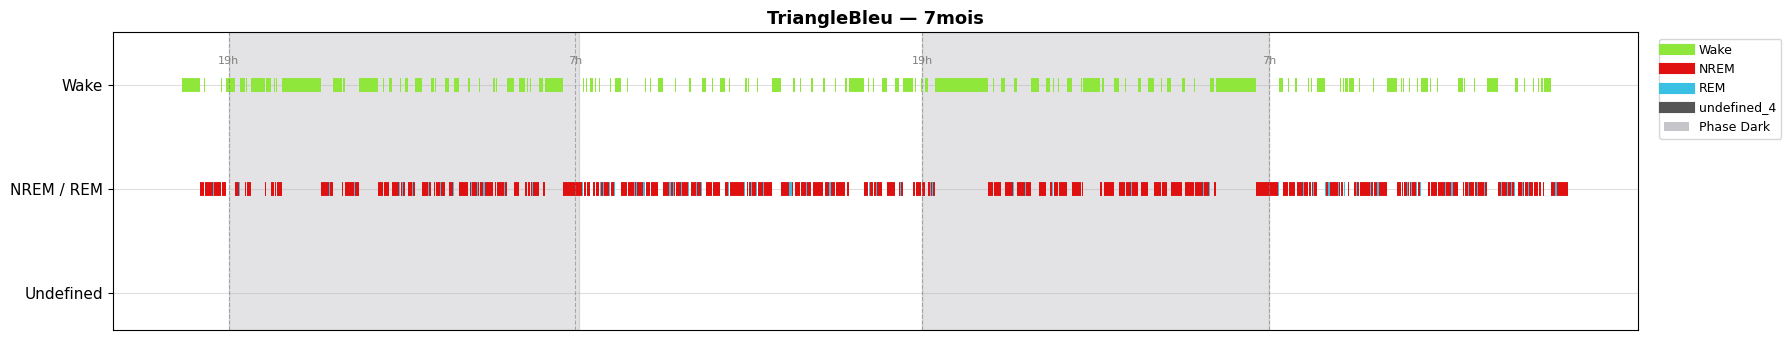

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBleu\7mois\Hypnogramme_TriangleBleu_7mois.png

  Souris : TriangleBleu  |  Age : 8mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   13645 epochs | duree totale : 48.52h
   Contenu recording_start.txt : [16/02/2026 15:42:07]
   Debut enregistrement : 2026-02-16 15:42:07  (format %d/%m/%Y %H:%M:%S)
   2890 episodes regroupe(s)


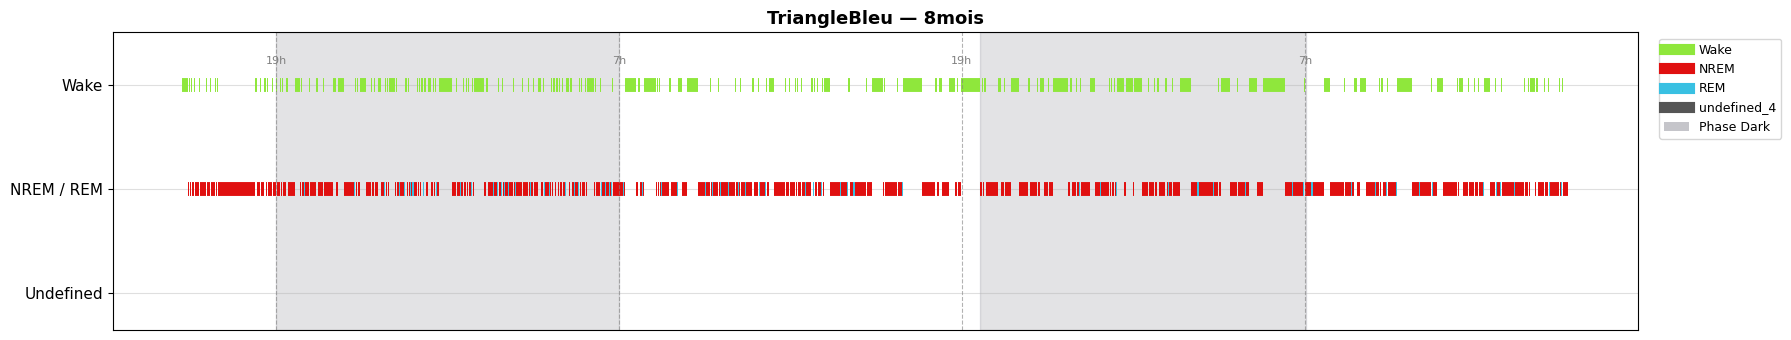

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleBleu\8mois\Hypnogramme_TriangleBleu_8mois.png

  Souris : TriangleJaune  |  Age : 3mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34767 epochs | duree totale : 48.29h
   Contenu recording_start.txt : [19/08/2026 16:25:28]
   Debut enregistrement : 2026-08-19 16:25:28  (format %d/%m/%Y %H:%M:%S)
   1 episodes regroupe(s)


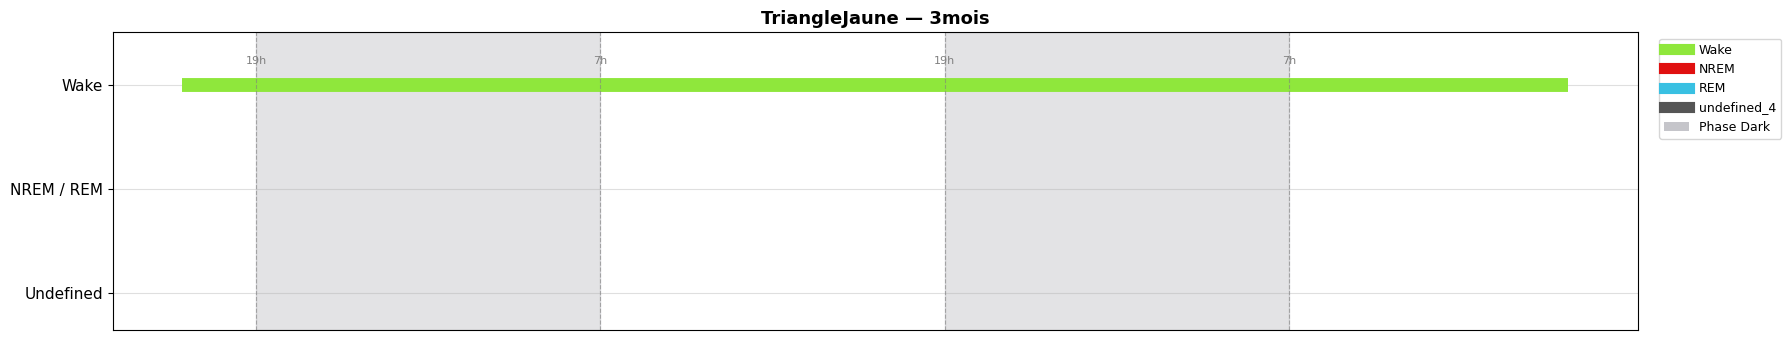

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleJaune\3mois\Hypnogramme_TriangleJaune_3mois.png

  Souris : TriangleJaune  |  Age : 4mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   46702 epochs | duree totale : 64.86h
   Contenu recording_start.txt : [24/09/2025 16:33:51]
   Debut enregistrement : 2025-09-24 16:33:51  (format %d/%m/%Y %H:%M:%S)
   1554 episodes regroupe(s)


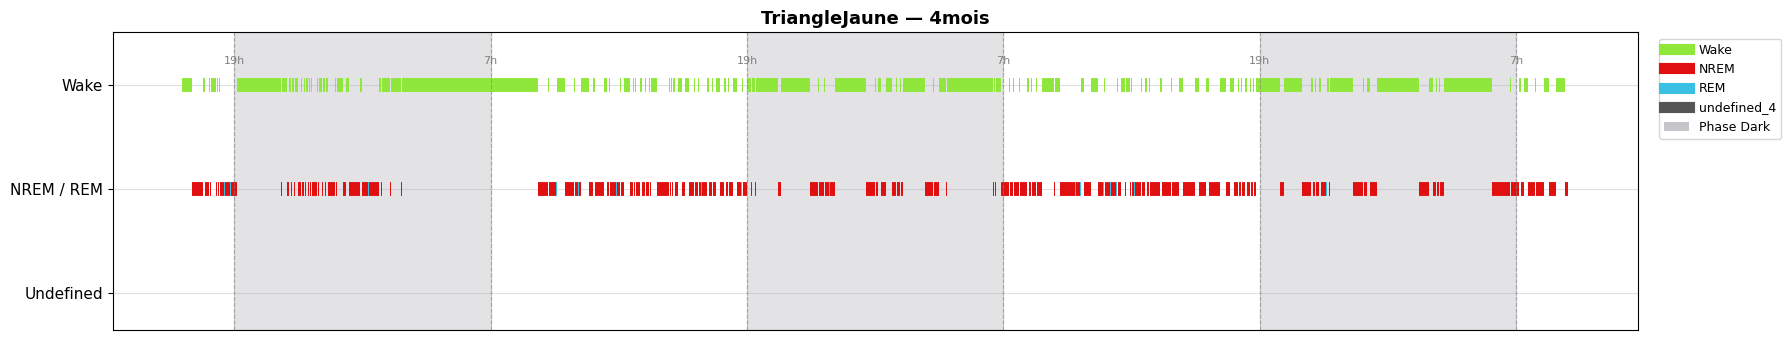

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleJaune\4mois\Hypnogramme_TriangleJaune_4mois.png

  Souris : TriangleJaune  |  Age : 5mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34952 epochs | duree totale : 48.54h
   Contenu recording_start.txt : [22/10/2025 16:20:15]
   Debut enregistrement : 2025-10-22 16:20:15  (format %d/%m/%Y %H:%M:%S)
   1075 episodes regroupe(s)


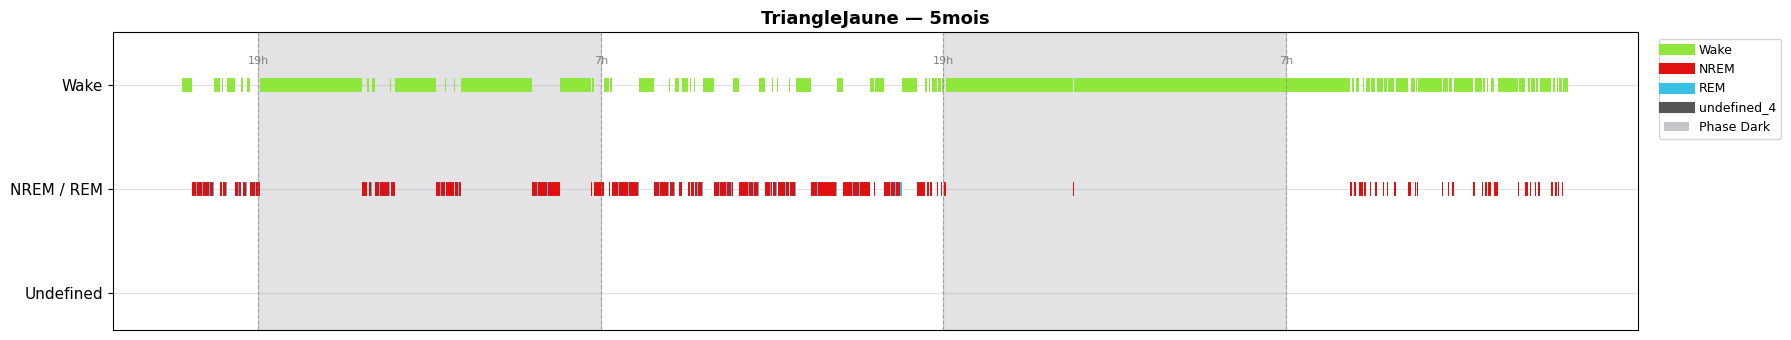

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleJaune\5mois\Hypnogramme_TriangleJaune_5mois.png

  Souris : TriangleJaune  |  Age : 6mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   35362 epochs | duree totale : 49.11h
   Contenu recording_start.txt : [24/11/2025 16:35:44]
   Debut enregistrement : 2025-11-24 16:35:44  (format %d/%m/%Y %H:%M:%S)
   2325 episodes regroupe(s)


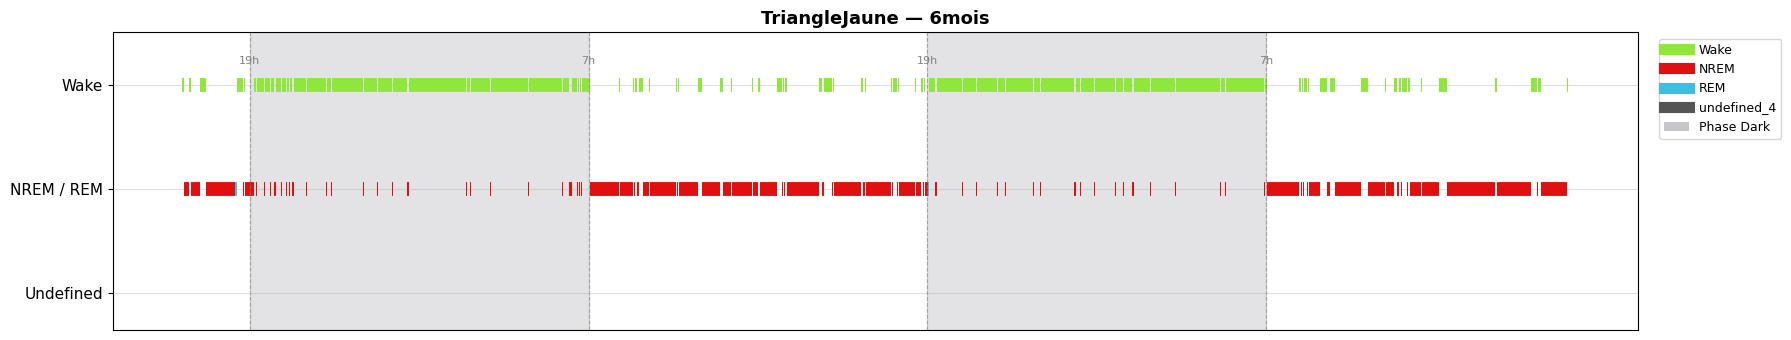

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleJaune\6mois\Hypnogramme_TriangleJaune_6mois.png

  Souris : TriangleJaune  |  Age : 7mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   8521 epochs | duree totale : 49.26h
   Contenu recording_start.txt : [17/12/2025 16:47:38]
   Debut enregistrement : 2025-12-17 16:47:38  (format %d/%m/%Y %H:%M:%S)
   1125 episodes regroupe(s)


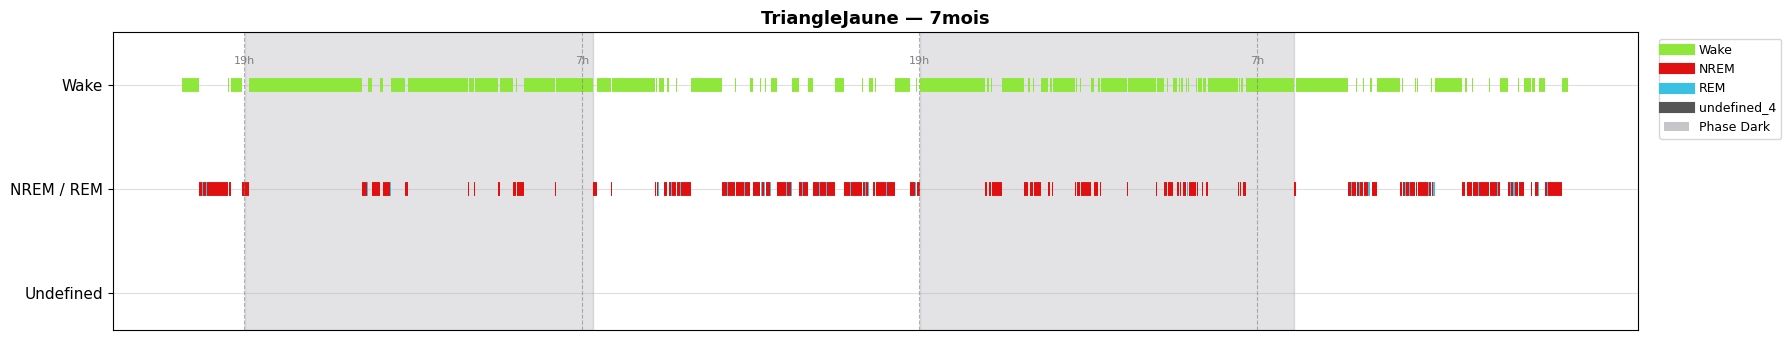

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleJaune\7mois\Hypnogramme_TriangleJaune_7mois.png

  Souris : TriangleMarron  |  Age : 3mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34314 epochs | duree totale : 47.66h
   Contenu recording_start.txt : [09/09/2025 17:25:54]
   Debut enregistrement : 2025-09-09 17:25:54  (format %d/%m/%Y %H:%M:%S)
   276 episodes regroupe(s)


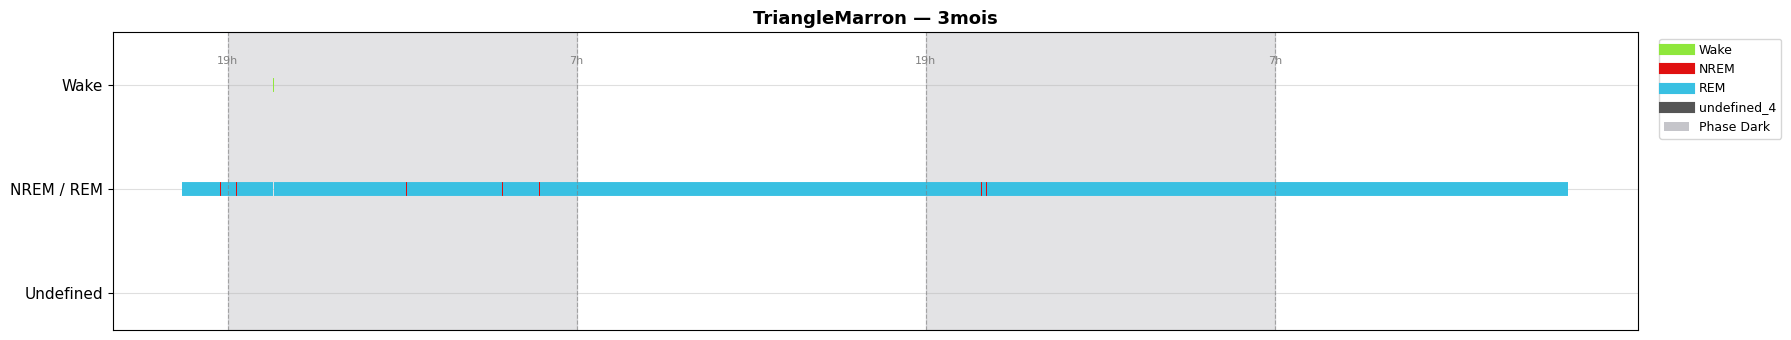

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleMarron\3mois\Hypnogramme_TriangleMarron_3mois.png

  Souris : TriangleMarron  |  Age : 4mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   46406 epochs | duree totale : 64.45h
   Contenu recording_start.txt : [14/10/2025 16:26:19]
   Debut enregistrement : 2025-10-14 16:26:19  (format %d/%m/%Y %H:%M:%S)
   2513 episodes regroupe(s)


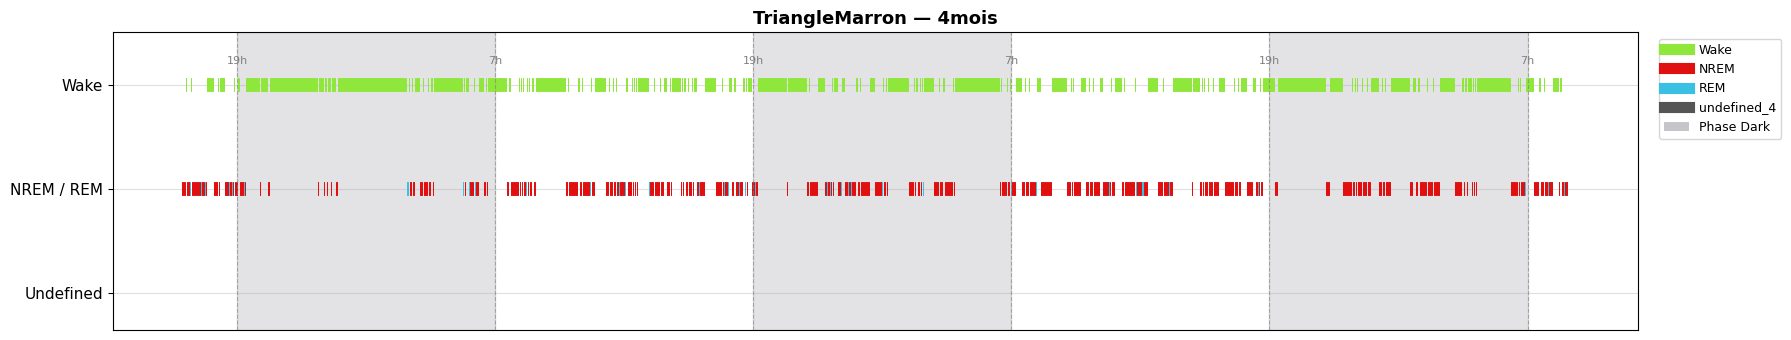

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleMarron\4mois\Hypnogramme_TriangleMarron_4mois.png

  Souris : TriangleMarron  |  Age : 5mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34895 epochs | duree totale : 48.47h
   Contenu recording_start.txt : [12/11/2025 17:35:16]
   Debut enregistrement : 2025-11-12 17:35:16  (format %d/%m/%Y %H:%M:%S)
   1389 episodes regroupe(s)


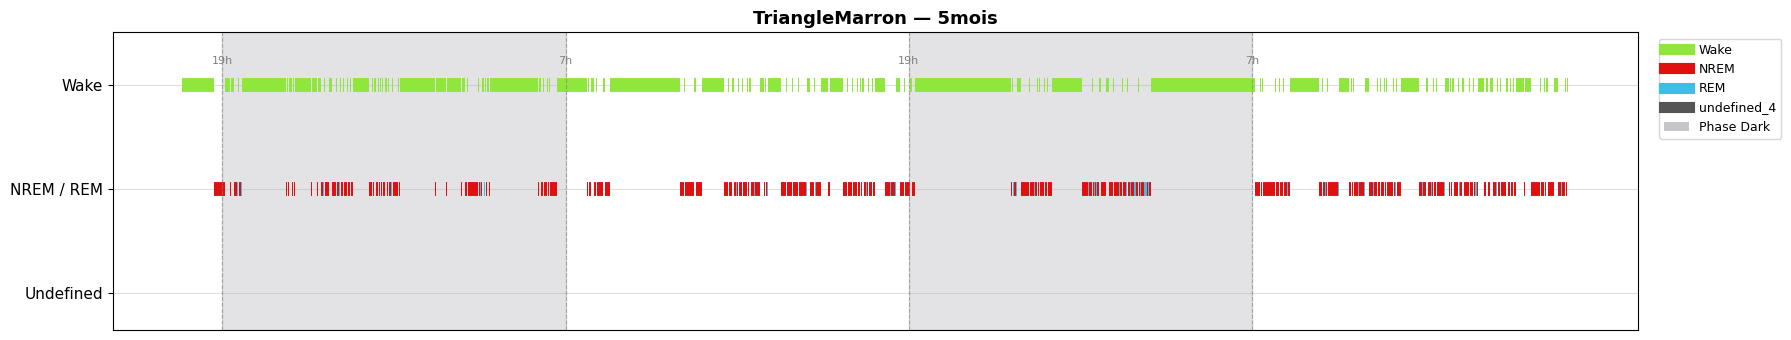

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleMarron\5mois\Hypnogramme_TriangleMarron_5mois.png

  Souris : TriangleMarron  |  Age : 6mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   8201 epochs | duree totale : 48.75h
   Contenu recording_start.txt : [08/12/2025 17:02:15]
   Debut enregistrement : 2025-12-08 17:02:15  (format %d/%m/%Y %H:%M:%S)
   915 episodes regroupe(s)


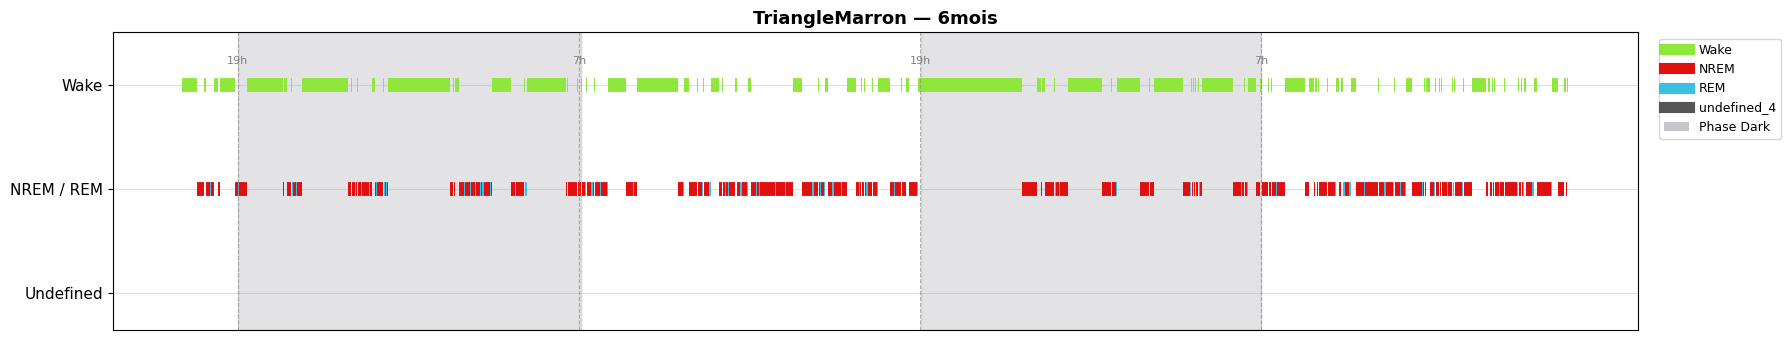

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleMarron\6mois\Hypnogramme_TriangleMarron_6mois.png

  Souris : TriangleMarron  |  Age : 7mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   10458 epochs | duree totale : 47.96h
   Contenu recording_start.txt : [14/01/2026 17:23:19]
   Debut enregistrement : 2026-01-14 17:23:19  (format %d/%m/%Y %H:%M:%S)
   1349 episodes regroupe(s)


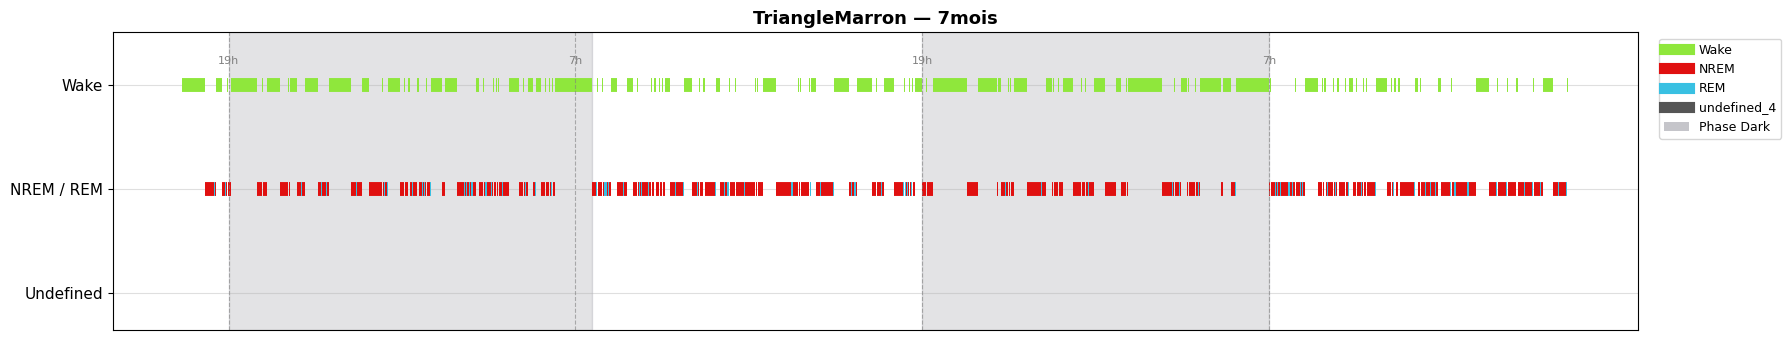

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleMarron\7mois\Hypnogramme_TriangleMarron_7mois.png

  Souris : TriangleMarron  |  Age : 8mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   8769 epochs | duree totale : 48.52h
   Contenu recording_start.txt : [16/02/2026 15:42:07]
   Debut enregistrement : 2026-02-16 15:42:07  (format %d/%m/%Y %H:%M:%S)
   960 episodes regroupe(s)


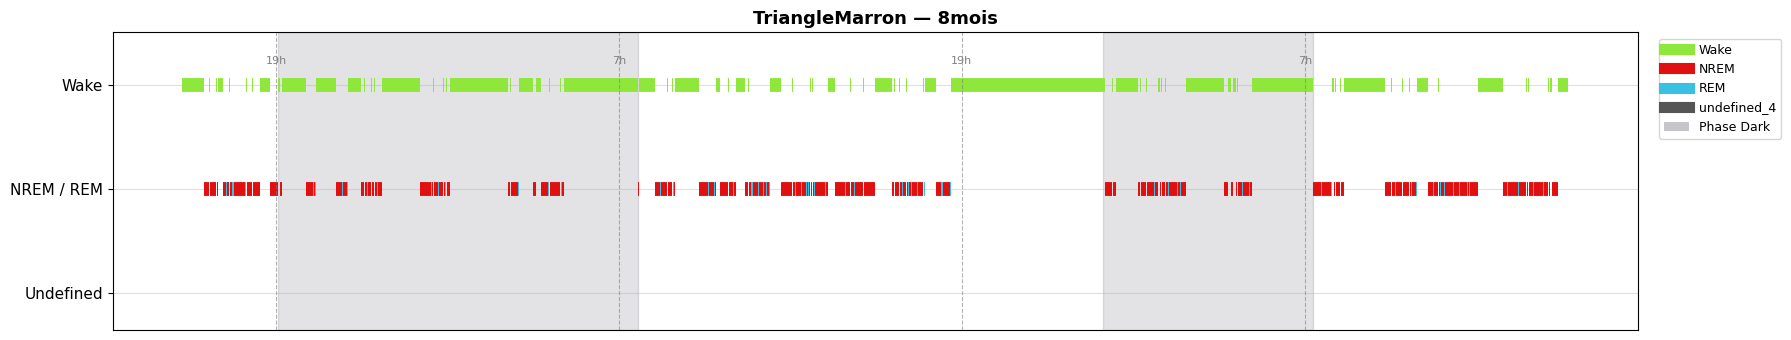

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleMarron\8mois\Hypnogramme_TriangleMarron_8mois.png

  Souris : TriangleNoir  |  Age : 3mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34314 epochs | duree totale : 47.66h
   Contenu recording_start.txt : [09/09/2025 17:25:54]
   Debut enregistrement : 2025-09-09 17:25:54  (format %d/%m/%Y %H:%M:%S)
   1128 episodes regroupe(s)


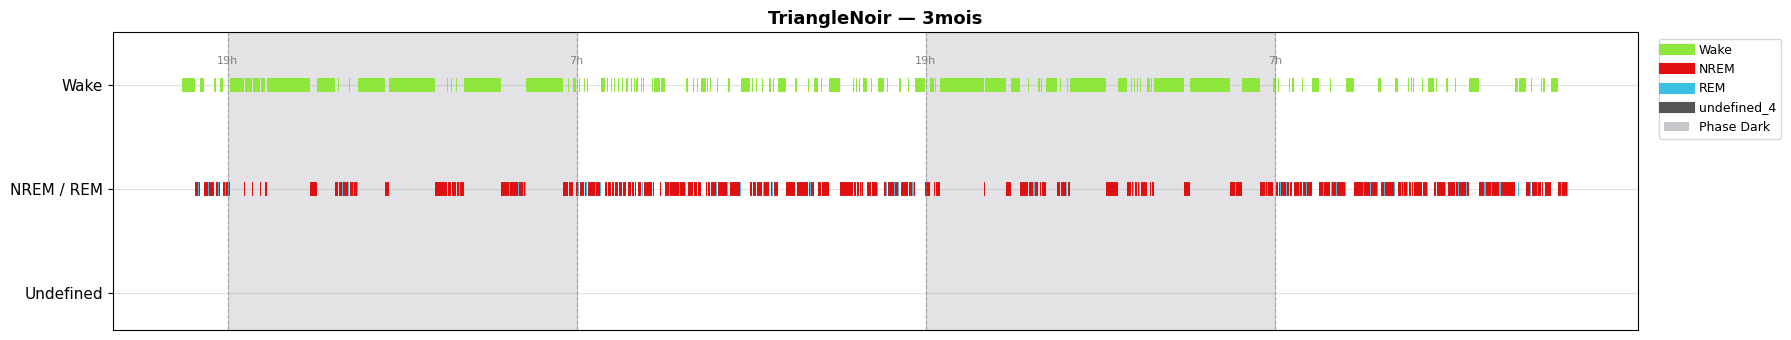

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleNoir\3mois\Hypnogramme_TriangleNoir_3mois.png

  Souris : TriangleNoir  |  Age : 4mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   46406 epochs | duree totale : 64.45h
   Contenu recording_start.txt : [14/10/2025 16:26:19]
   Debut enregistrement : 2025-10-14 16:26:19  (format %d/%m/%Y %H:%M:%S)
   1219 episodes regroupe(s)


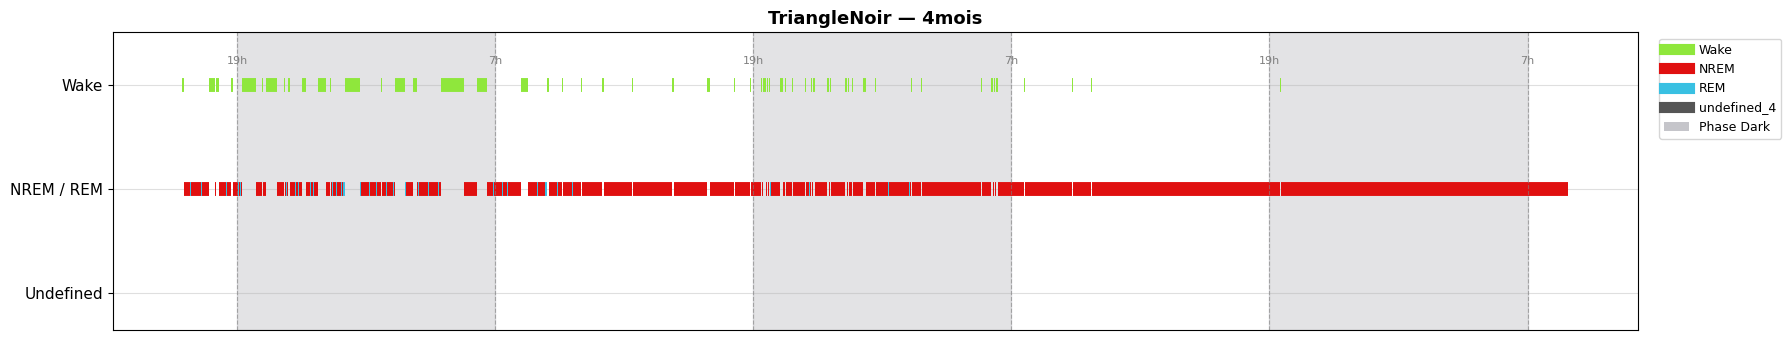

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleNoir\4mois\Hypnogramme_TriangleNoir_4mois.png

  Souris : TriangleOrange  |  Age : 3mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34767 epochs | duree totale : 48.29h
   Contenu recording_start.txt : [19/08/2025 16:25:28]
   Debut enregistrement : 2025-08-19 16:25:28  (format %d/%m/%Y %H:%M:%S)
   1692 episodes regroupe(s)


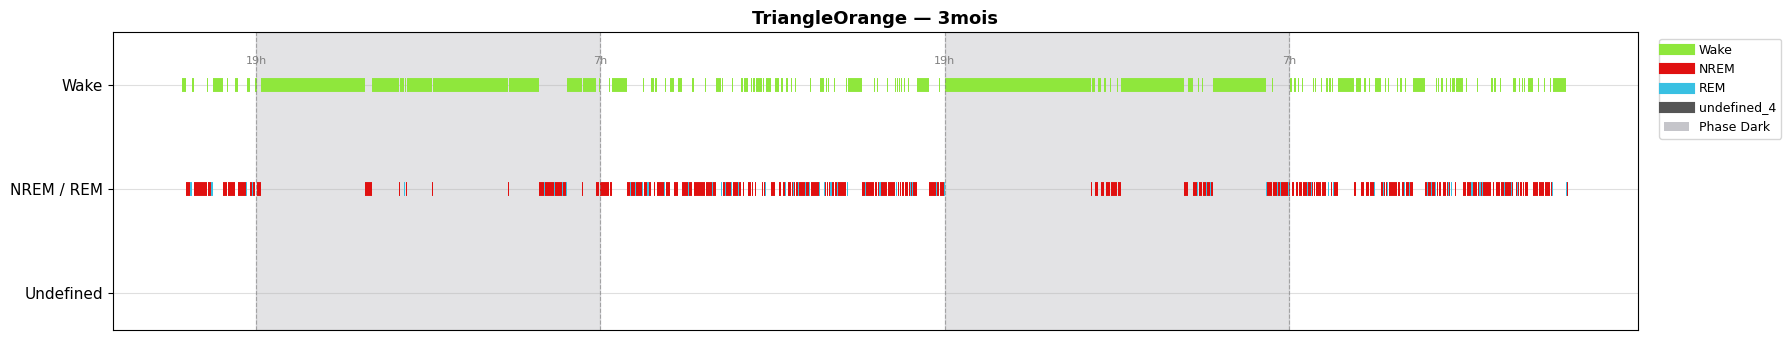

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleOrange\3mois\Hypnogramme_TriangleOrange_3mois.png

  Souris : TriangleRouge  |  Age : 3mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   17742 epochs | duree totale : 47.66h
   Contenu recording_start.txt : [09/09/2025 17:25:54]
   Debut enregistrement : 2025-09-09 17:25:54  (format %d/%m/%Y %H:%M:%S)
   1050 episodes regroupe(s)


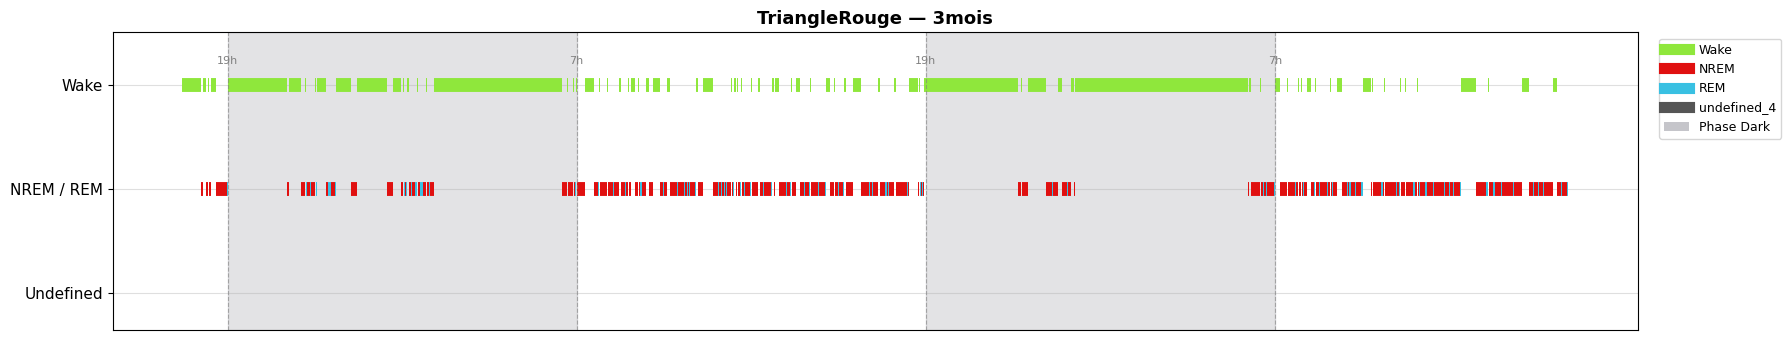

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleRouge\3mois\Hypnogramme_TriangleRouge_3mois.png

  Souris : TriangleRouge  |  Age : 4mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   10325 epochs | duree totale : 64.45h
   Contenu recording_start.txt : [14/10/2025 16:26:19]
   Debut enregistrement : 2025-10-14 16:26:19  (format %d/%m/%Y %H:%M:%S)
   1164 episodes regroupe(s)


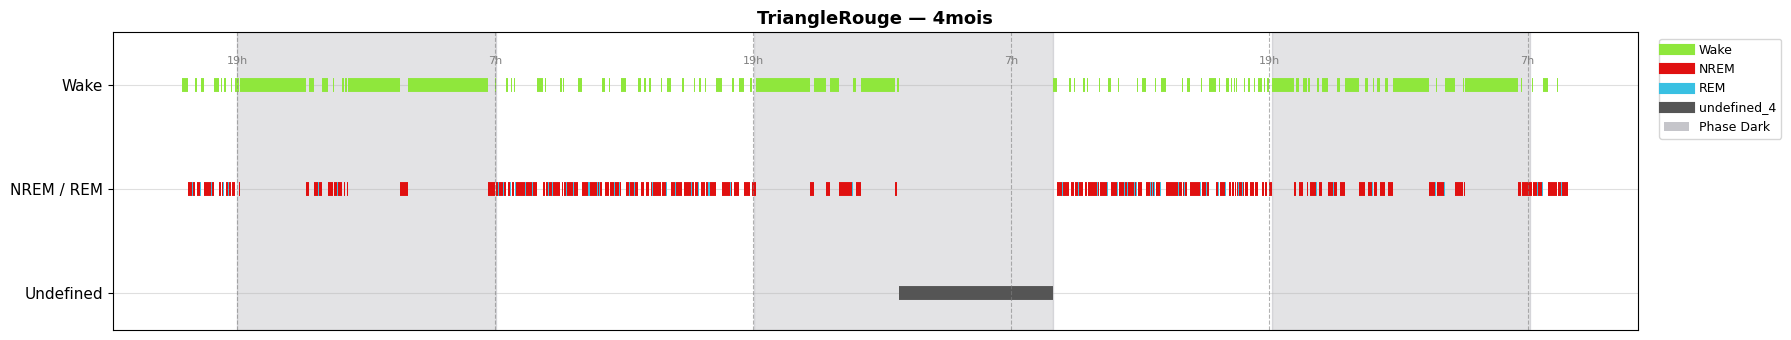

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleRouge\4mois\Hypnogramme_TriangleRouge_4mois.png

  Souris : TriangleRouge  |  Age : 5mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   8704 epochs | duree totale : 48.47h
   Contenu recording_start.txt : [12/11/2025 17:35:16]
   Debut enregistrement : 2025-11-12 17:35:16  (format %d/%m/%Y %H:%M:%S)
   864 episodes regroupe(s)


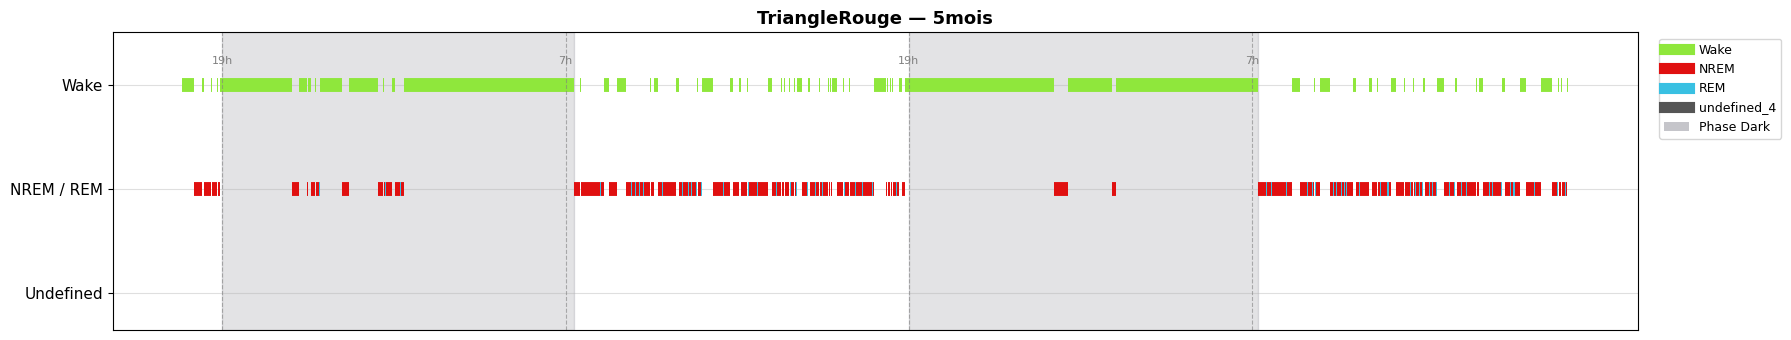

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleRouge\5mois\Hypnogramme_TriangleRouge_5mois.png

  Souris : TriangleRouge  |  Age : 6mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   35105 epochs | duree totale : 48.76h
   Contenu recording_start.txt : [08/12/2025 17:02:15]
   Debut enregistrement : 2025-12-08 17:02:15  (format %d/%m/%Y %H:%M:%S)
   901 episodes regroupe(s)


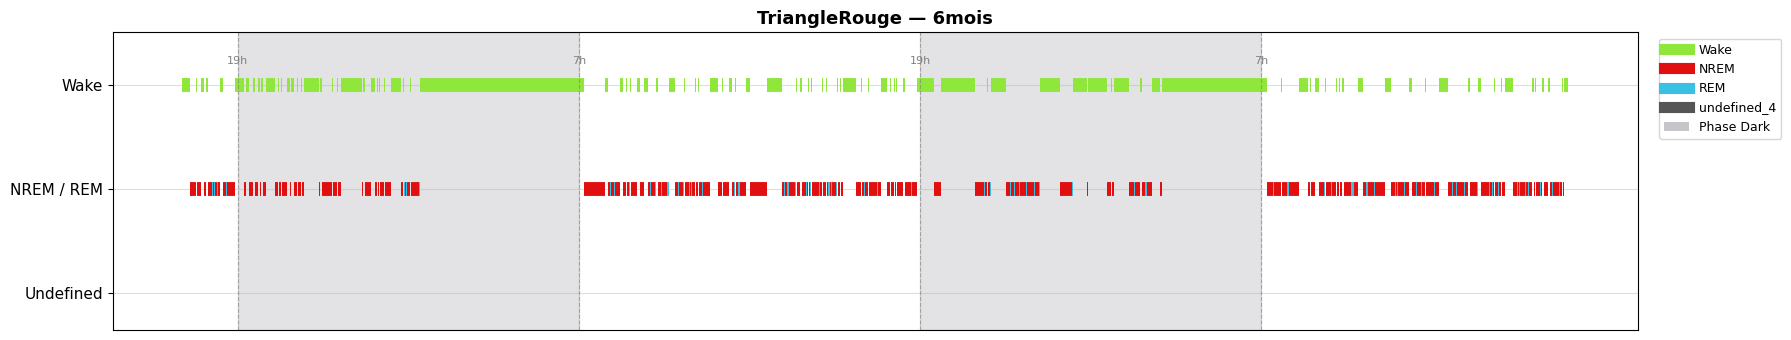

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleRouge\6mois\Hypnogramme_TriangleRouge_6mois.png

  Souris : TriangleRouge  |  Age : 7mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   32916 epochs | duree totale : 45.32h
   Contenu recording_start.txt : [14/01/2026 17:23:19]
   Debut enregistrement : 2026-01-14 17:23:19  (format %d/%m/%Y %H:%M:%S)
   1133 episodes regroupe(s)


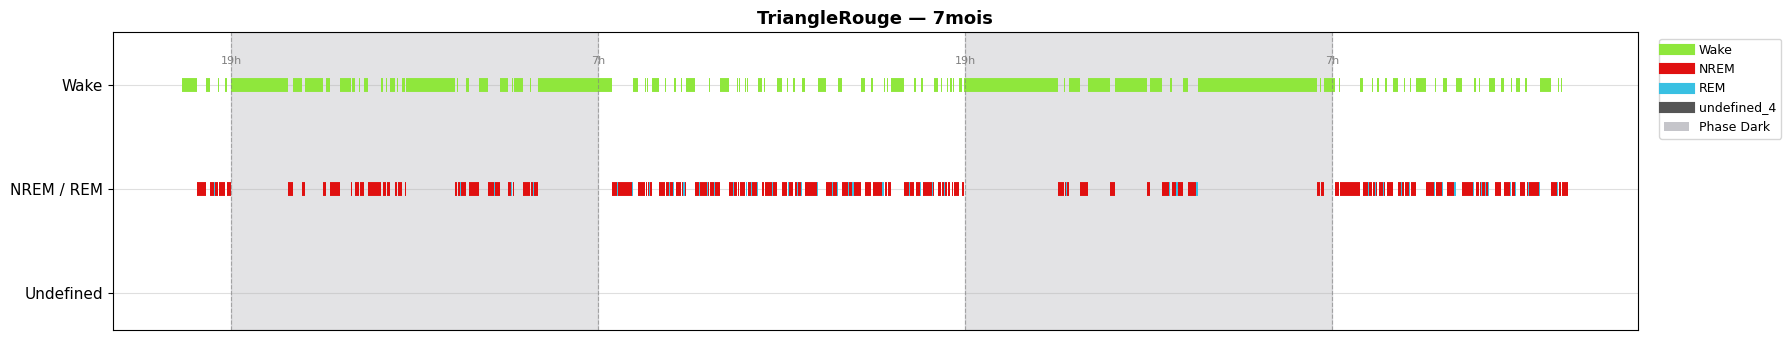

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleRouge\7mois\Hypnogramme_TriangleRouge_7mois.png

  Souris : TriangleRouge  |  Age : 8mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   11567 epochs | duree totale : 47.98h
   Contenu recording_start.txt : [16/02/2026 15:42:07]
   Debut enregistrement : 2026-02-16 15:42:07  (format %d/%m/%Y %H:%M:%S)
   1499 episodes regroupe(s)


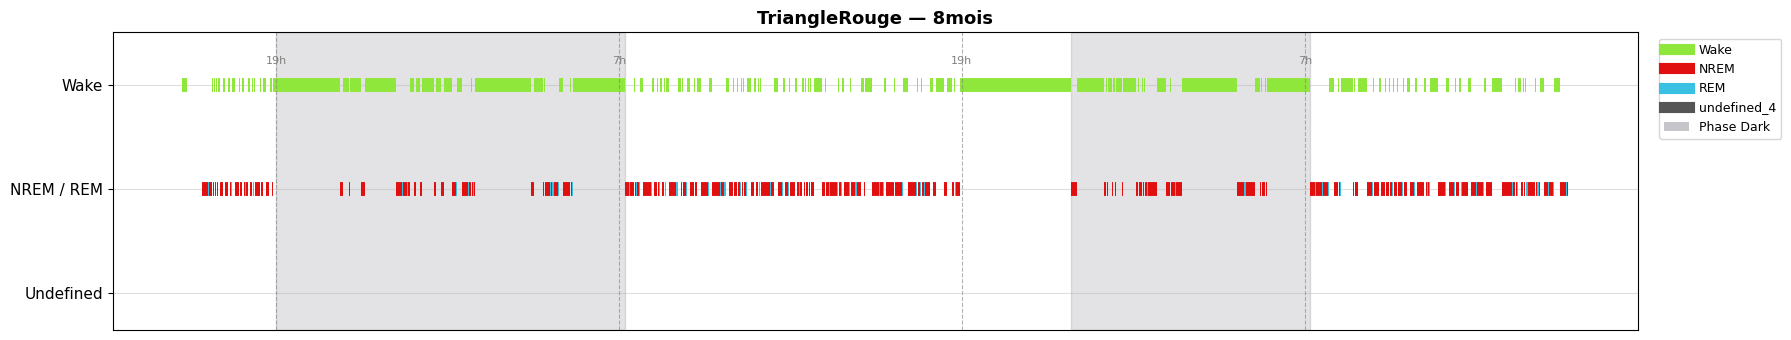

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleRouge\8mois\Hypnogramme_TriangleRouge_8mois.png

  Souris : TriangleVert  |  Age : 3mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34622 epochs | duree totale : 48.09h
   Contenu recording_start.txt : [11/09/2025 17:44:25]
   Debut enregistrement : 2025-09-11 17:44:25  (format %d/%m/%Y %H:%M:%S)
   1336 episodes regroupe(s)


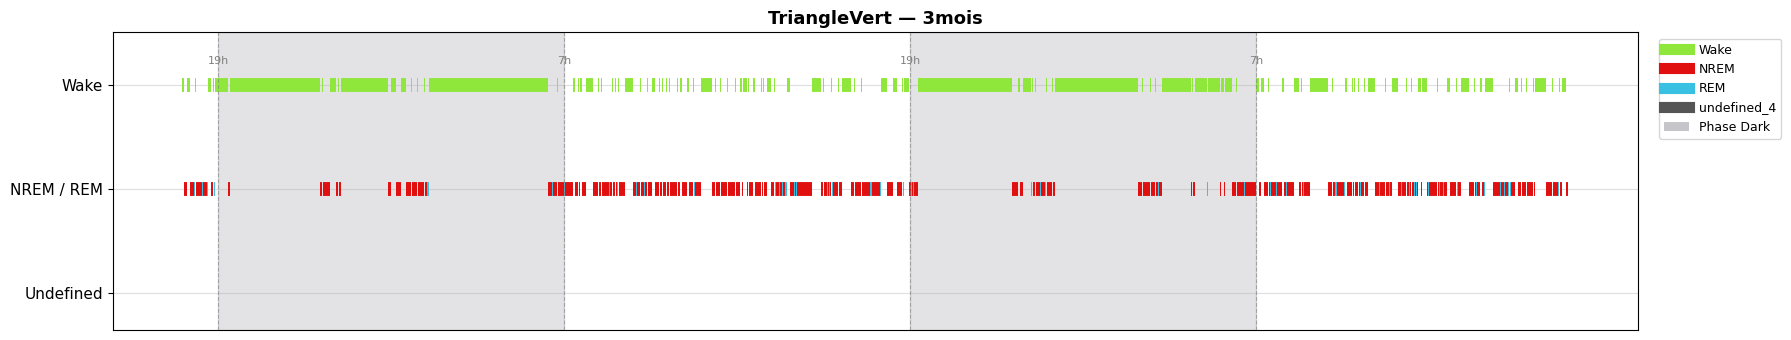

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleVert\3mois\Hypnogramme_TriangleVert_3mois.png

  Souris : TriangleVert  |  Age : 4mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   46702 epochs | duree totale : 64.86h
   Contenu recording_start.txt : [24/09/2025 16:33:51]
   Debut enregistrement : 2025-09-24 16:33:51  (format %d/%m/%Y %H:%M:%S)
   2585 episodes regroupe(s)


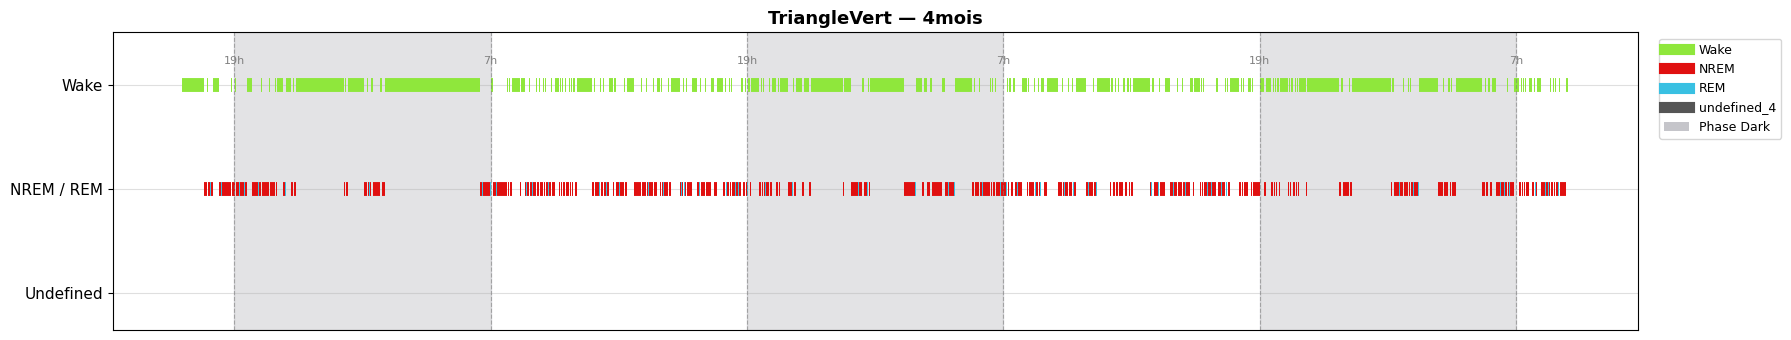

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleVert\4mois\Hypnogramme_TriangleVert_4mois.png

  Souris : TriangleViolet  |  Age : 3mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34767 epochs | duree totale : 48.29h
   Contenu recording_start.txt : [19/08/2025 16:25:28]
   Debut enregistrement : 2025-08-19 16:25:28  (format %d/%m/%Y %H:%M:%S)
   3540 episodes regroupe(s)


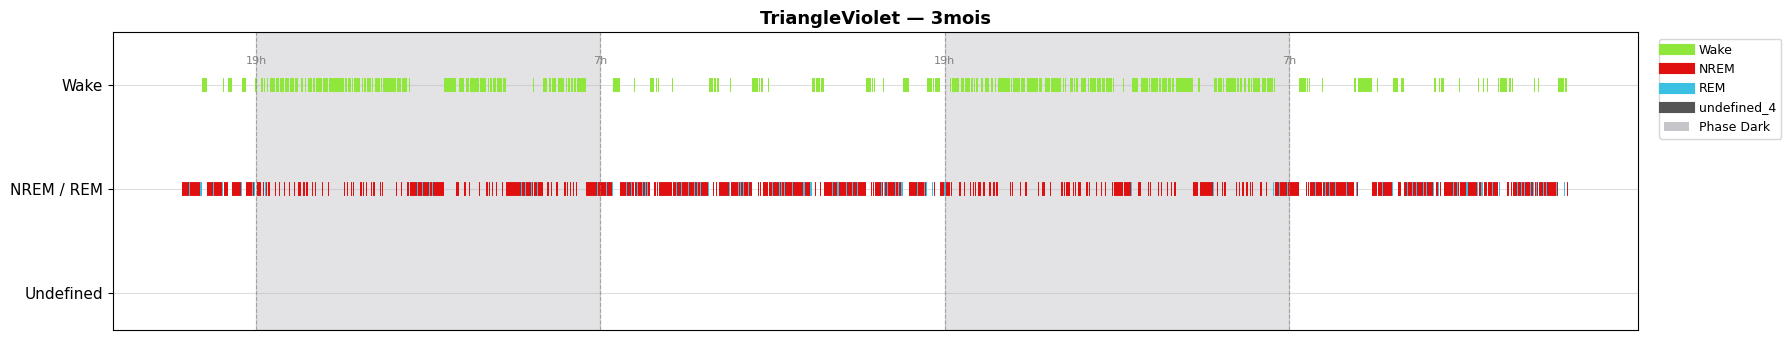

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleViolet\3mois\Hypnogramme_TriangleViolet_3mois.png

  Souris : TriangleViolet  |  Age : 4mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   46702 epochs | duree totale : 64.86h
   Contenu recording_start.txt : [24/09/2025 16:33:51]
   Debut enregistrement : 2025-09-24 16:33:51  (format %d/%m/%Y %H:%M:%S)
   1165 episodes regroupe(s)


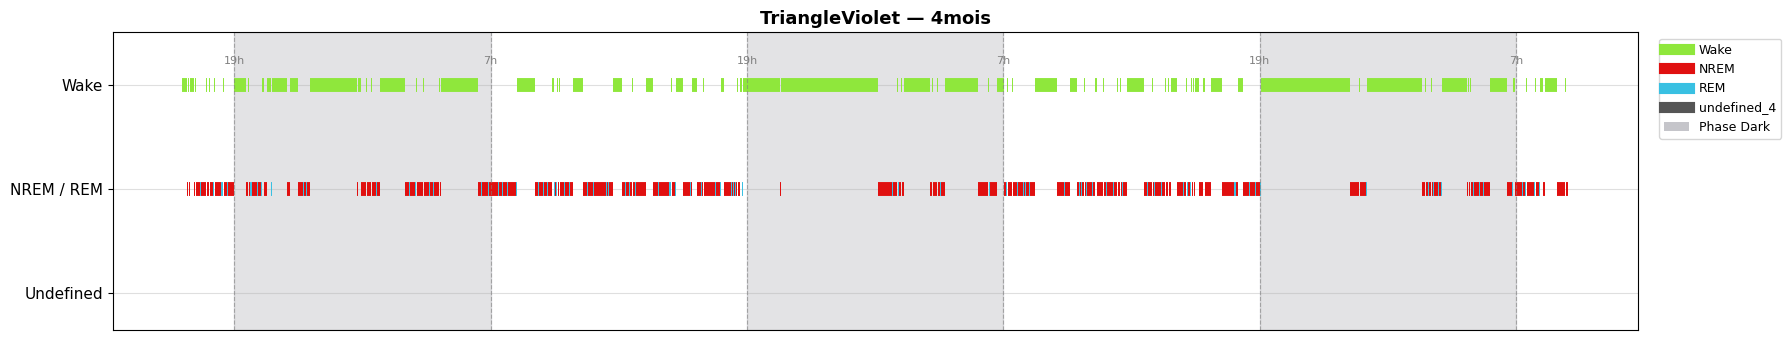

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleViolet\4mois\Hypnogramme_TriangleViolet_4mois.png

  Souris : TriangleViolet  |  Age : 5mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   34952 epochs | duree totale : 48.54h
   Contenu recording_start.txt : [22/10/2025 16:20:15]
   Debut enregistrement : 2025-10-22 16:20:15  (format %d/%m/%Y %H:%M:%S)
   5871 episodes regroupe(s)


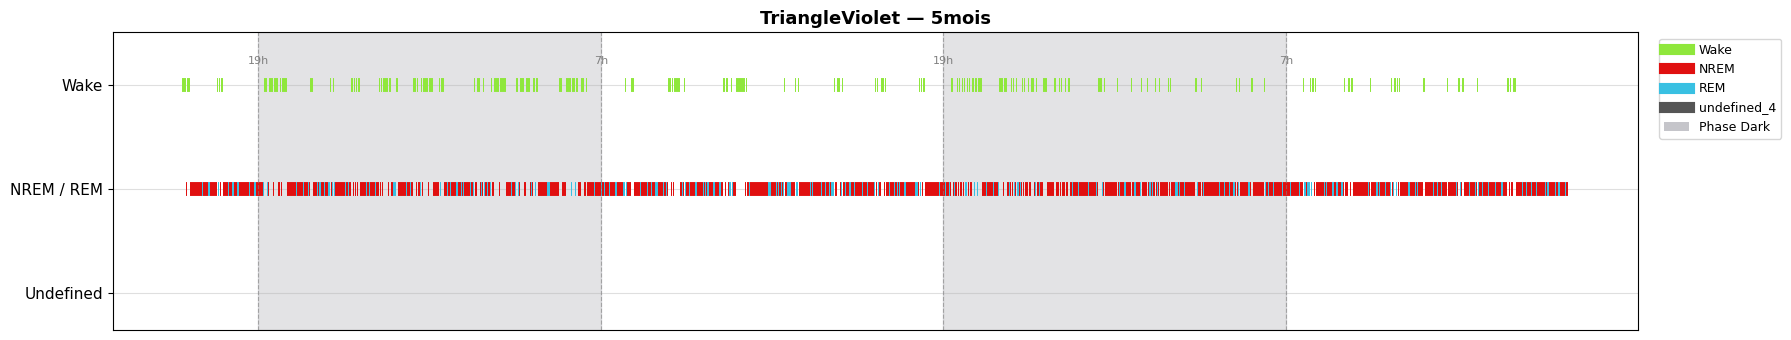

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleViolet\5mois\Hypnogramme_TriangleViolet_5mois.png

  Souris : TriangleViolet  |  Age : 6mois  |  Scoring : AutoScor5
   Separateur detecte : [,]
   Colonnes : ['label', 'duration', 'start_time', 'end_time']
   35362 epochs | duree totale : 49.11h
   Contenu recording_start.txt : [24/11/2025 16:35:44]
   Debut enregistrement : 2025-11-24 16:35:44  (format %d/%m/%Y %H:%M:%S)
   1053 episodes regroupe(s)


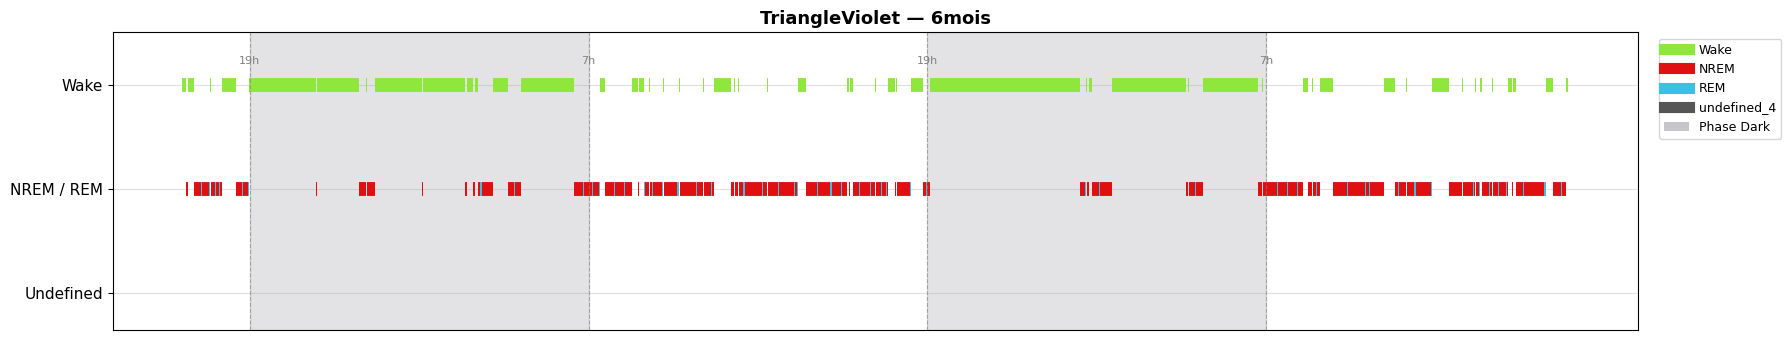

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleViolet\6mois\Hypnogramme_TriangleViolet_6mois.png

  Souris : TriangleViolet  |  Age : 7mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   3358 epochs | duree totale : 49.26h
   Contenu recording_start.txt : [17/12/2025 16:47:38]
   Debut enregistrement : 2025-12-17 16:47:38  (format %d/%m/%Y %H:%M:%S)
   285 episodes regroupe(s)


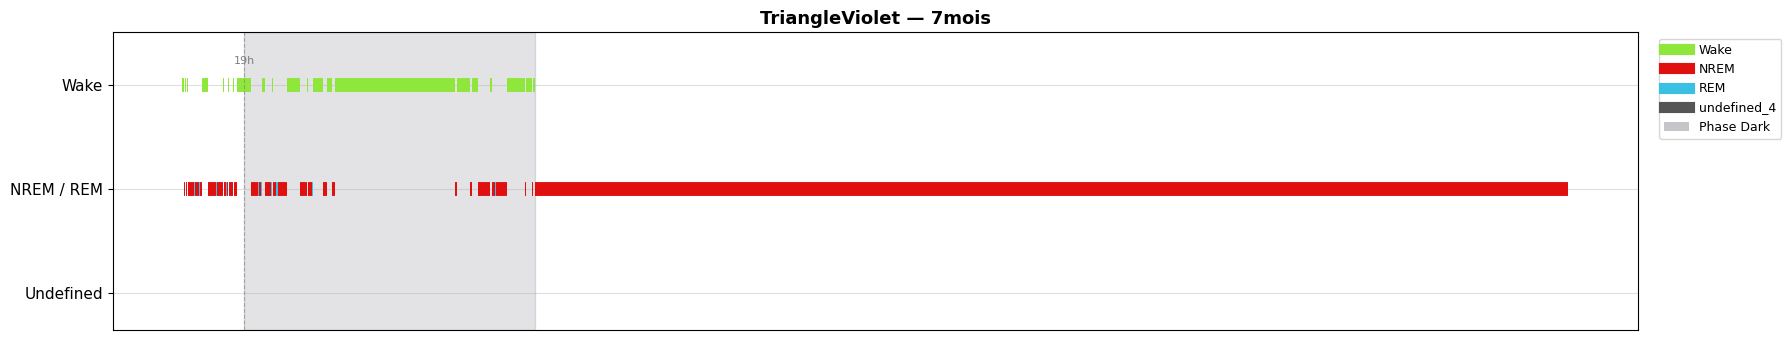

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleViolet\7mois\Hypnogramme_TriangleViolet_7mois.png

  Souris : TriangleViolet  |  Age : 8mois  |  Scoring : ManualScor5
   Separateur detecte : [,]
   Colonnes : ['start_time', 'duration', 'label', 'end_time']
   8466 epochs | duree totale : 48.80h
   Contenu recording_start.txt : [26/01/2026 16:01:26]
   Debut enregistrement : 2026-01-26 16:01:26  (format %d/%m/%Y %H:%M:%S)
   1561 episodes regroupe(s)


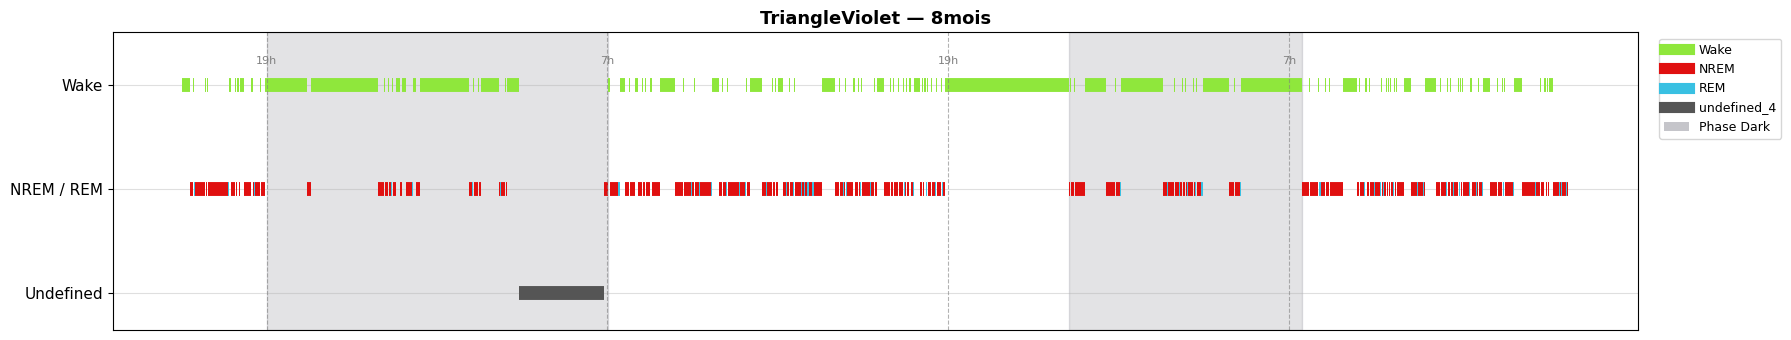

   Hypnogramme sauvegarde : Z:\forgetting\Carla\SleepRecordings\TriangleViolet\8mois\Hypnogramme_TriangleViolet_8mois.png


Analyse terminee : 217 lignes de resultats collectees


In [4]:
# =================================================================
# CELLULE 4 - BOUCLE PRINCIPALE : ANALYSE DE TOUS LES FICHIERS
# =================================================================

all_results = []

for entry in fichiers_trouves:
    mice     = entry['mice']
    age      = entry['age']
    csv_path = entry['path']
    dpath    = os.path.dirname(csv_path)

    print(f"\n{'='*65}")
    source   = entry.get('source', '?')
    print(f"  Souris : {mice}  |  Age : {age}  |  Scoring : {source}")
    print(f"{'='*65}")

    # -- Chargement CSV (detection automatique du separateur) -------
    # pd.read_csv avec le mauvais sep ne plante pas mais cree 1 seule colonne
    for sep in [',', ';', '\t']:
        df_raw = pd.read_csv(csv_path, sep=sep)
        df_raw.columns = df_raw.columns.str.strip()
        if len(df_raw.columns) > 1:
            print(f"   Separateur detecte : [{sep}]")
            break
    else:
        print(f"   ERREUR : separateur non detecte dans {csv_path} — souris ignoree")
        continue

    if 'time' in df_raw.columns and 'start_time' not in df_raw.columns:
        df_raw = df_raw.rename(columns={'time': 'start_time'})
        df_raw['end_time'] = df_raw['start_time'] + df_raw['duration']

    print(f"   Colonnes : {df_raw.columns.tolist()}")
    print(f"   {len(df_raw)} epochs | duree totale : {df_raw['duration'].sum()/3600:.2f}h")

    # -- Lecture recording_start.txt ---------------------------------
    # utf-8-sig gere automatiquement le BOM Windows (\ufeff)
    txt_path = os.path.join(dpath, 'recording_start.txt')
    if not os.path.exists(txt_path):
        print(f"   ERREUR : recording_start.txt introuvable dans {dpath} — souris ignoree")
        continue

    try:
        with open(txt_path, 'r', encoding='utf-8-sig') as f:
            raw_content = f.read().strip()
        print(f"   Contenu recording_start.txt : [{raw_content}]")  # debug

        # Essai de plusieurs formats courants
        recording_start = None
        for fmt in ['%d/%m/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S',
                    '%d-%m-%Y %H:%M:%S', '%m/%d/%Y %H:%M:%S']:
            try:
                recording_start = datetime.strptime(raw_content, fmt)
                print(f"   Debut enregistrement : {recording_start}  (format {fmt})")
                break
            except ValueError:
                continue

        if recording_start is None:
            print(f"   ERREUR : format de date non reconnu : [{raw_content}] — souris ignoree")
            continue

    except Exception as e:
        print(f"   ERREUR lecture recording_start.txt : {e} — souris ignoree")
        continue

    # -- Horodatages & phases ----------------------------------------
    df_raw['abs_datetime'] = [
        recording_start + timedelta(seconds=float(t))
        for t in df_raw['start_time']
    ]
    df_raw['phase'] = df_raw['abs_datetime'].apply(assign_phase)

    # -- Regroupement episodes ---------------------------------------
    df_episodes = regrouper_episodes(df_raw)
    print(f"   {len(df_episodes)} episodes regroupe(s)")

    # -- Hypnogramme -------------------------------------------------
    tracer_hypnogramme(df_raw, df_episodes, mice, age, dpath)

    # -- Analyse Light & Dark ----------------------------------------
    for phase in ['Light', 'Dark']:
        res = analyser_phase(phase, df_raw, df_episodes, mice, age)
        if res:
            all_results.append(res)

print(f"\n\nAnalyse terminee : {len(all_results)} lignes de resultats collectees")


In [5]:
df_summary = pd.DataFrame(all_results)

# Chargement du fichier contenant MouseID, Genotype et Sex
meta = pd.read_csv(
    "C:/Users/AudreyHay/Documents/Carla/Visual Code/HayLabAnalysis/python/_LFP_coordinates_of_all_mice.csv",
    sep=";"
)

meta = pd.read_csv("_MouseID_ImplantColorCode.csv", sep=";")

# Renommer les colonnes pour qu'elles correspondent aux noms utilisés
meta = meta.rename(columns={
    "Unnamed: 0": "mice",
    "MouseID": "mouse_ID",
    "Genotype": "genotype",
    "Sex": "sex"
})

# Ajout des informations dans le tableau final
df_summary = df_summary.merge(
    meta[["mice", "mouse_ID", "genotype", "sex"]],
    on="mice",
    how="left"
)

# Colonnes d'identification
id_cols = [
    'mice',
    'mouse_ID',
    'genotype',
    'sex',
    'age',
    'phase',
    'duree_h'
]

# Réorganisation des colonnes (tout le reste inchangé)
other_cols = [c for c in df_summary.columns if c not in id_cols]
df_summary = df_summary[id_cols + other_cols]

# Affichage
display(df_summary)


# Sauvegarde en Excel
df_summary.to_excel(
    os.path.join(BASE_PATH, "Sleep_Summary_Allmice.xlsx"),
    index=False
)


KeyError: "['mice'] not in index"